In [1]:
"""
===============================================================================
RETAIL REVENUE, CHURN & PROFITABILITY ANALYTICS PROJECT
===============================================================================
End-to-End Analytics Pipeline for a Retail / E-commerce Business

Project: Revenue Forecasting, Churn & Profitability Analysis
Data: customers, orders, order_details, products, categories (5 CSVs)

Analytics Covered:
- Time Series Analysis (ARIMA, Prophet, Exponential Smoothing)
- Regression Analysis (Linear, Logistic, Random Forest)
- Cohort & Retention Analysis
- Customer Lifetime Value (CLV)
- RFM Segmentation
- Survival Analysis

Author: <your name>
Date: September 2026
Platform: Google Colab (Python 3.10+)
===============================================================================
"""

# ============================================================================
# SECTION 0: ENVIRONMENT SETUP & LIBRARY IMPORTS
# ============================================================================

# ---- COLAB ONLY: run this line in its OWN cell first, then restart the ----
# ---- runtime if Colab asks you to. (Remove the leading '#' to use it.)  ----
#
# !pip install -q lifelines prophet statsmodels

print("""
╔══════════════════════════════════════════════════════════════════════════╗
║          RETAIL REVENUE, CHURN & PROFITABILITY ANALYTICS                 ║
║         Revenue Forecasting | Churn Analysis | Profitability             ║
╚══════════════════════════════════════════════════════════════════════════╝
""")

# Core data manipulation
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Statistical analysis
from scipy import stats
from scipy.stats import normaltest, kstest
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing   # needed for Exp. Smoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

# Time series forecasting
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    print("Prophet not available. Install with: !pip install prophet")
    PROPHET_AVAILABLE = False

# Survival analysis (used later for time-to-churn)
try:
    from lifelines import KaplanMeierFitter, CoxPHFitter
    LIFELINES_AVAILABLE = True
except ImportError:
    print("lifelines not available. Install with: !pip install lifelines")
    LIFELINES_AVAILABLE = False

# Utilities
import os
import json
from collections import defaultdict

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Output folder for charts (used by later sections)
os.makedirs('financial_viz', exist_ok=True)

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")
print(f"Prophet available: {PROPHET_AVAILABLE} | lifelines available: {LIFELINES_AVAILABLE}")
print(f"Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")


╔══════════════════════════════════════════════════════════════════════════╗
║          RETAIL REVENUE, CHURN & PROFITABILITY ANALYTICS                 ║
║         Revenue Forecasting | Churn Analysis | Profitability             ║
╚══════════════════════════════════════════════════════════════════════════╝

lifelines not available. Install with: !pip install lifelines
All libraries imported successfully!
Prophet available: True | lifelines available: False
Analysis started at: 2026-09-29 08:39:51



In [2]:
!pip install -q prophet lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
customers_raw = pd.read_csv("/content/drive/MyDrive/files for python/customers.csv")
orders_raw = pd.read_csv("/content/drive/MyDrive/files for python/orders (1).csv")
order_details_raw = pd.read_csv("/content/drive/MyDrive/files for python/order_details.csv")
products_raw = pd.read_csv("/content/drive/MyDrive/files for python/products.csv")
categories_raw = pd.read_csv("/content/drive/MyDrive/files for python/products.csv")

SECTION 2: DATA UNDERSTANDING & EXPLORATORY ANALYSIS

 DEFINING BUSINESS QUESTIONS
--------------------------------------------------------------------------------

Our analysis will answer these critical business questions:

REVENUE FORECASTING
Q1: What is our expected revenue for the next 12 months?
Q2: Are there seasonal patterns in our revenue?
Q3: What factors drive revenue growth?
Q4: What is our revenue growth rate and trend?

CHURN ANALYSIS
Q5: Which customers are most likely to churn in the next 3 months?
Q6: What are the key indicators of churn?
Q7: What is the financial impact of churn on our business?
Q8: How does churn vary by customer segment?

PROFITABILITY & COHORTS
Q9: Which customer cohorts are most valuable?
Q10: What is our customer retention rate by cohort?
Q11: How does customer lifetime value vary by segment?
Q12: What is our payback period for customer acquisition?

CUSTOMER SEGMENTATION
Q13: Can we identify distinct customer groups for targeted strategies?
Q14:

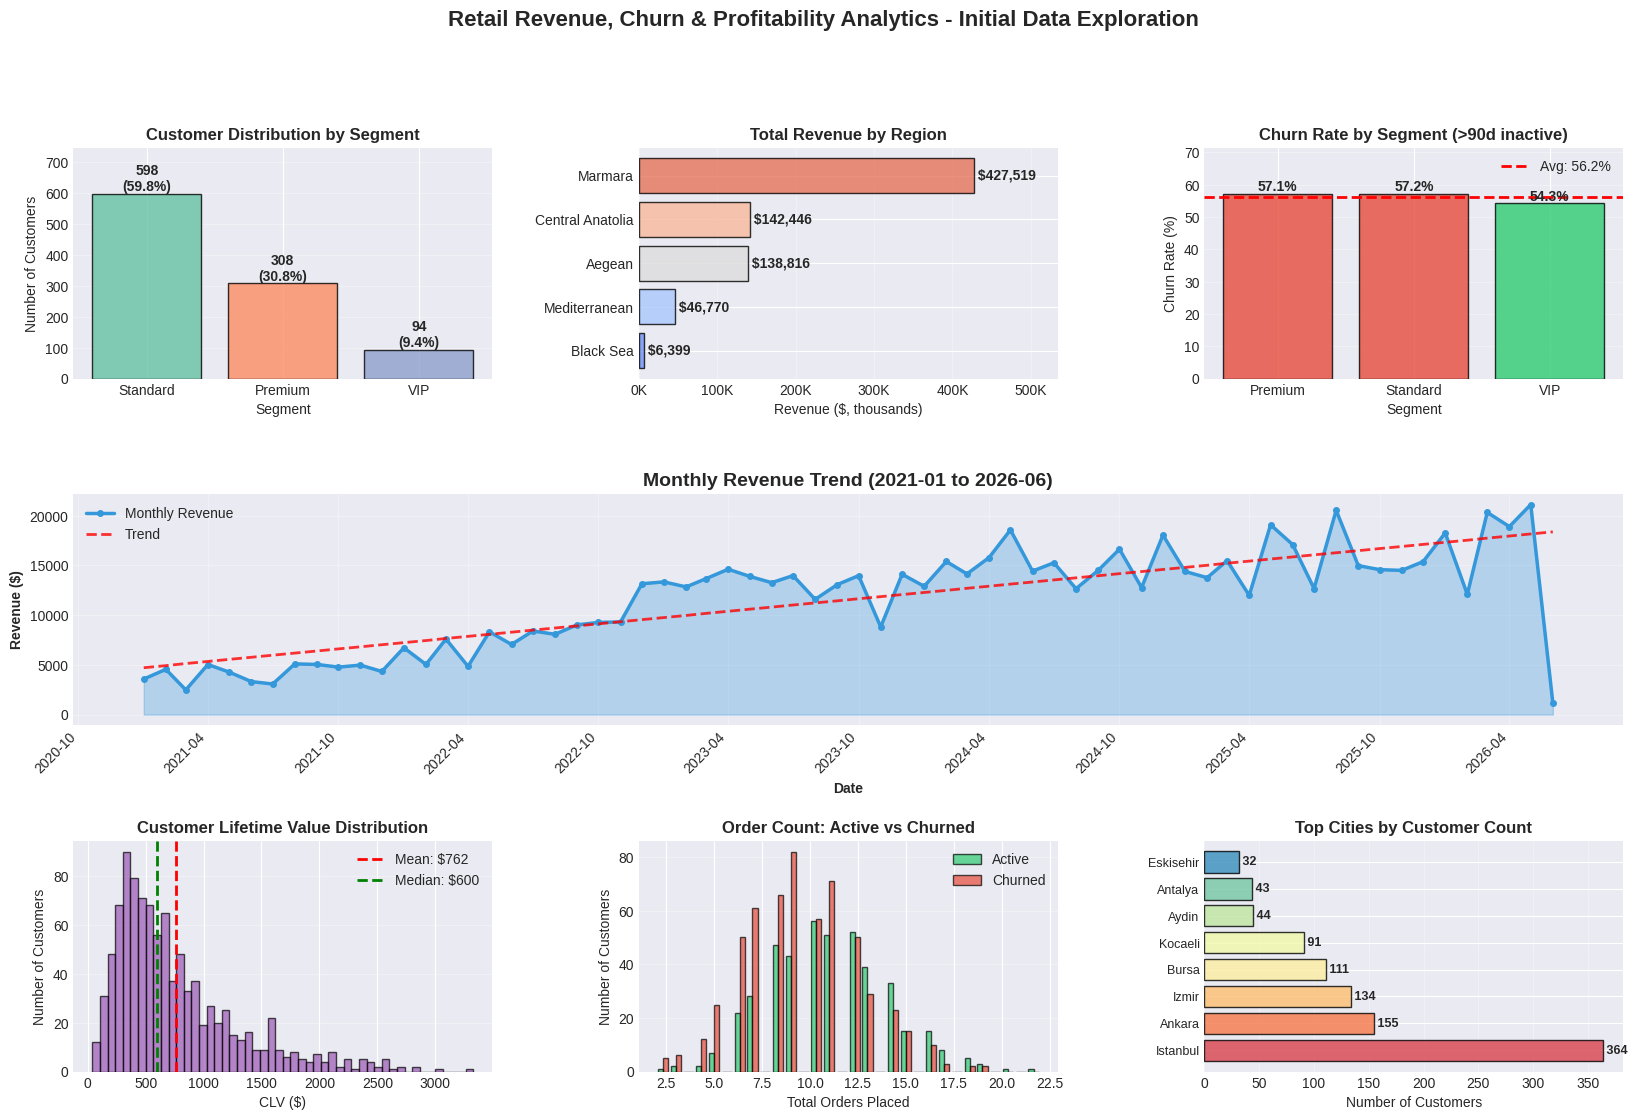


 Data exploration complete!



In [3]:
# ============================================================================
# SECTION 2: DATA UNDERSTANDING & EXPLORATION
# (Rewritten for: customers.csv, orders.csv, order_details.csv,
#  products.csv, categories.csv)
# ============================================================================

# NOTE: libraries are imported in Section 0 - run that cell first.

print("="*80)
print("SECTION 2: DATA UNDERSTANDING & EXPLORATORY ANALYSIS")
print("="*80)

print("\n DEFINING BUSINESS QUESTIONS")
print("-"*80)

business_questions = """
Our analysis will answer these critical business questions:

REVENUE FORECASTING
Q1: What is our expected revenue for the next 12 months?
Q2: Are there seasonal patterns in our revenue?
Q3: What factors drive revenue growth?
Q4: What is our revenue growth rate and trend?

CHURN ANALYSIS
Q5: Which customers are most likely to churn in the next 3 months?
Q6: What are the key indicators of churn?
Q7: What is the financial impact of churn on our business?
Q8: How does churn vary by customer segment?

PROFITABILITY & COHORTS
Q9: Which customer cohorts are most valuable?
Q10: What is our customer retention rate by cohort?
Q11: How does customer lifetime value vary by segment?
Q12: What is our payback period for customer acquisition?

CUSTOMER SEGMENTATION
Q13: Can we identify distinct customer groups for targeted strategies?
Q14: Which segments are most profitable?
Q15: How should we allocate resources across segments?
"""

print(business_questions)

# ========================================================================
# 2.0: LOAD & CLEAN RAW FILES  (Google Colab + Google Drive)
# ========================================================================

# Mount Google Drive (Colab asks for permission each time you reopen the notebook)
from google.colab import drive
drive.mount('/content/drive')

# In the Colab left sidebar: Files icon > drive > MyDrive > your folder,
# right-click each CSV > "Copy path", then paste it between the quotes below.
customers_raw = pd.read_csv("/content/drive/MyDrive/files for python/customers.csv")
orders_raw = pd.read_csv("/content/drive/MyDrive/files for python/orders (1).csv")
order_details_raw = pd.read_csv("/content/drive/MyDrive/files for python/order_details.csv")
products_raw = pd.read_csv("/content/drive/MyDrive/files for python/products.csv")
categories_raw = pd.read_csv("/content/drive/MyDrive/files for python/products.csv")

for df in [customers_raw, orders_raw, order_details_raw, products_raw, categories_raw]:
    df.columns = [c.strip().lstrip('\ufeff') for c in df.columns]

orders_raw['OrderDate'] = pd.to_datetime(orders_raw['OrderDate'])

# Dataset's own "today" — the data runs past the real current date (synthetic),
# so anchor churn/recency to the last observed order date, not datetime.now().
ANALYSIS_DATE = orders_raw['OrderDate'].max()
CHURN_THRESHOLD_DAYS = 90   # no purchase in 90 days -> considered churned

# ========================================================================
# 2.1: BUILD LINE-ITEM "TRANSACTIONS" TABLE
# (template's `transactions` == our order_details, priced and dated)
# ========================================================================

transactions = order_details_raw.merge(
    orders_raw[['OrderID', 'CustomerID', 'OrderDate']], on='OrderID', how='left'
)
transactions['amount'] = (
    transactions['Quantity'] * transactions['UnitPrice'] * (1 - transactions['DiscountRate'])
)
transactions['cost'] = transactions['Quantity'] * transactions['UnitCost']
transactions['profit'] = transactions['amount'] - transactions['cost']
# template's `transaction_type` -> closest real equivalent here is return status
transactions['transaction_type'] = np.where(
    transactions['IsReturned'] == 1, 'Return', 'Purchase'
)
# NOTE: this dataset has no payment_method field — the template's payment
# method breakdown is dropped rather than faked.

# ========================================================================
# 2.2: BUILD PER-CUSTOMER SUMMARY TABLE
# (template's `customers` enriched with derived clv / churn / usage fields)
# ========================================================================

cust_orders = transactions.groupby('CustomerID').agg(
    total_revenue=('amount', 'sum'),
    total_profit=('profit', 'sum'),
    order_count=('OrderID', 'nunique'),
    last_order_date=('OrderDate', 'max'),
    first_order_date=('OrderDate', 'min'),
).reset_index()

customers = customers_raw.merge(cust_orders, on='CustomerID', how='left')

# customers with no orders at all (should be none, per the earlier integrity
# check, but guard anyway)
customers[['total_revenue', 'total_profit', 'order_count']] = customers[
    ['total_revenue', 'total_profit', 'order_count']
].fillna(0)

customers['clv'] = customers['total_revenue']                       # template's `clv`
customers['days_since_last_order'] = (
    ANALYSIS_DATE - customers['last_order_date']
).dt.days
customers['is_churned'] = (
    customers['days_since_last_order'] > CHURN_THRESHOLD_DAYS
).astype(int)                                                        # template's `is_churned`
customers['usage_score'] = customers['order_count']                  # closest proxy available

segment_col = 'CustomerSegment'   # template's `segment`

# ========================================================================
# 2.3: BUILD MONTHLY REVENUE TABLE
# ========================================================================

monthly_revenue = (
    transactions.set_index('OrderDate')['amount']
    .resample('MS').sum()
    .rename('total_revenue')
    .reset_index()
    .rename(columns={'OrderDate': 'year_month'})
)
monthly_revenue['revenue_growth'] = monthly_revenue['total_revenue'].pct_change() * 100

# ========================================================================
# 2.4: CUSTOMER DATA EXPLORATION
# ========================================================================

print("\n" + "-"*80)
print("2.4: CUSTOMER DATA EXPLORATION")
print("-"*80)

print("\n Customer Dataset Overview:")
print(f"Shape: {customers.shape[0]:,} rows × {customers.shape[1]} columns\n")

print("First 5 records:")
print(customers.head())

print("\n\nSummary Statistics:")
print(customers[['total_revenue', 'total_profit', 'order_count', 'clv',
                  'days_since_last_order']].describe())

print("\n\nMissing Values:")
missing_summary = pd.DataFrame({
    'Column': customers.columns,
    'Missing_Count': customers.isnull().sum(),
    'Missing_Percentage': (customers.isnull().sum() / len(customers) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
if len(missing_summary) > 0:
    print(missing_summary.to_string(index=False))
else:
    print(" No missing values detected!")

# ========================================================================
# 2.5: TRANSACTION DATA EXPLORATION
# ========================================================================

print("\n\n" + "-"*80)
print("2.5: TRANSACTION DATA EXPLORATION")
print("-"*80)

print("\n Transaction Dataset Overview:")
print(f"Shape: {transactions.shape[0]:,} rows × {transactions.shape[1]} columns\n")

print("Transaction Statistics:")
print(f"Total Revenue: ${transactions['amount'].sum():,.2f}")
print(f"Average Transaction: ${transactions['amount'].mean():.2f}")
print(f"Median Transaction: ${transactions['amount'].median():.2f}")
print(f"Std Dev: ${transactions['amount'].std():.2f}")
print(f"Min Transaction: ${transactions['amount'].min():.2f}")
print(f"Max Transaction: ${transactions['amount'].max():.2f}")

print("\n\nTransaction Types (Purchase vs Return):")
print(transactions['transaction_type'].value_counts())

# Payment method not available in this dataset -> panel dropped below.

# ========================================================================
# 2.6: MONTHLY REVENUE EXPLORATION
# ========================================================================

print("\n\n" + "-"*80)
print("2.6: MONTHLY REVENUE EXPLORATION")
print("-"*80)

print("\n Monthly Revenue Dataset Overview:")
print(f"Shape: {monthly_revenue.shape[0]:,} rows × {monthly_revenue.shape[1]} columns\n")

print("First 10 periods:")
print(monthly_revenue.head(10))

print("\n\nRevenue Trend Statistics:")
print(f"Total Revenue (All Time): ${monthly_revenue['total_revenue'].sum():,.2f}")
print(f"Average Monthly Revenue: ${monthly_revenue['total_revenue'].mean():,.2f}")
print(f"Highest Month: ${monthly_revenue['total_revenue'].max():,.2f}")
print(f"Lowest Month: ${monthly_revenue['total_revenue'].min():,.2f}")
print(f"Average Growth Rate: {monthly_revenue['revenue_growth'].mean():.2f}%")

# ========================================================================
# 2.7: INITIAL VISUALIZATIONS
# ========================================================================

print("\n\n" + "-"*80)
print("2.7: INITIAL DATA VISUALIZATIONS")
print("-"*80)

fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# 1. Customer Segment Distribution  (template panel 1 — kept, renamed column)
ax1 = fig.add_subplot(gs[0, 0])
segment_counts = customers[segment_col].value_counts()
colors1 = sns.color_palette("Set2", len(segment_counts))
ax1.bar(segment_counts.index, segment_counts.values, color=colors1, alpha=0.8, edgecolor='black')
ax1.set_title('Customer Distribution by Segment', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of Customers')
ax1.set_xlabel('Segment')
for i, v in enumerate(segment_counts.values):
    ax1.text(i, v, f'{v:,}\n({v/len(customers)*100:.1f}%)',
              ha='center', va='bottom', fontweight='bold')
ax1.set_ylim(0, segment_counts.max() * 1.25)
ax1.grid(axis='y', alpha=0.3)

# 2. Total Revenue by Region  (replaces template's "MRR by Plan" — no
#    subscription plan/MRR concept exists in this retail dataset)
ax2 = fig.add_subplot(gs[0, 1])
region_revenue = customers.groupby('Region')['total_revenue'].sum().sort_values(ascending=True)
colors2 = sns.color_palette("coolwarm", len(region_revenue))
ax2.barh(region_revenue.index, region_revenue.values, color=colors2, alpha=0.8, edgecolor='black')
ax2.set_title('Total Revenue by Region', fontweight='bold', fontsize=12)
ax2.set_xlabel('Revenue ($, thousands)')
for i, v in enumerate(region_revenue.values):
    ax2.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:,.0f}K'))
ax2.set_xlim(0, region_revenue.max() * 1.25)
ax2.grid(axis='x', alpha=0.3)

# 3. Churn Rate by Segment  (kept — now driven by derived is_churned)
ax3 = fig.add_subplot(gs[0, 2])
churn_by_segment = customers.groupby(segment_col)['is_churned'].mean() * 100
colors3 = ['#e74c3c' if x > churn_by_segment.mean() else '#2ecc71' for x in churn_by_segment.values]
ax3.bar(churn_by_segment.index, churn_by_segment.values, color=colors3, alpha=0.8, edgecolor='black')
ax3.set_title(f'Churn Rate by Segment (>{CHURN_THRESHOLD_DAYS}d inactive)', fontweight='bold', fontsize=12)
ax3.set_ylabel('Churn Rate (%)')
ax3.set_xlabel('Segment')
ax3.axhline(y=churn_by_segment.mean(), color='red', linestyle='--',
            label=f'Avg: {churn_by_segment.mean():.1f}%', linewidth=2)
for i, v in enumerate(churn_by_segment.values):
    ax3.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax3.set_ylim(0, churn_by_segment.max() * 1.25)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Revenue Trend Over Time  (kept, same logic — real dates from this data)
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(monthly_revenue['year_month'], monthly_revenue['total_revenue'],
          linewidth=2.5, color='#3498db', marker='o', markersize=4, label='Monthly Revenue')
ax4.fill_between(monthly_revenue['year_month'], monthly_revenue['total_revenue'],
                   alpha=0.3, color='#3498db')
date_range_label = f"{monthly_revenue['year_month'].min():%Y-%m} to {monthly_revenue['year_month'].max():%Y-%m}"
ax4.set_title(f'Monthly Revenue Trend ({date_range_label})', fontweight='bold', fontsize=14)
ax4.set_xlabel('Date', fontweight='bold')
ax4.set_ylabel('Revenue ($)', fontweight='bold')
ax4.grid(True, alpha=0.3)

z = np.polyfit(range(len(monthly_revenue)), monthly_revenue['total_revenue'], 1)
p = np.poly1d(z)
ax4.plot(monthly_revenue['year_month'], p(range(len(monthly_revenue))),
          "r--", alpha=0.8, linewidth=2, label='Trend')
ax4.legend()

ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 5. Customer Lifetime Value Distribution  (kept — clv now = actual revenue)
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(customers['clv'], bins=50, color='#9b59b6', alpha=0.7, edgecolor='black')
ax5.axvline(customers['clv'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean: ${customers["clv"].mean():,.0f}')
ax5.axvline(customers['clv'].median(), color='green', linestyle='--',
            linewidth=2, label=f'Median: ${customers["clv"].median():,.0f}')
ax5.set_title('Customer Lifetime Value Distribution', fontweight='bold', fontsize=12)
ax5.set_xlabel('CLV ($)')
ax5.set_ylabel('Number of Customers')
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# 6. Order Count vs Churn  (replaces template's "usage_score" — no app/usage
#    telemetry exists here; order frequency is the closest real proxy)
ax6 = fig.add_subplot(gs[2, 1])
churned = customers[customers['is_churned'] == 1]['usage_score']
active = customers[customers['is_churned'] == 0]['usage_score']
ax6.hist([active, churned], bins=30, label=['Active', 'Churned'],
          color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
ax6.set_title('Order Count: Active vs Churned', fontweight='bold', fontsize=12)
ax6.set_xlabel('Total Orders Placed')
ax6.set_ylabel('Number of Customers')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

# 7. Top Cities  (replaces template's "Industry Distribution" — no industry
#    field exists here; city is the closest categorical dimension)
ax7 = fig.add_subplot(gs[2, 2])
city_counts = customers['City'].value_counts().head(8)
colors7 = sns.color_palette("Spectral", len(city_counts))
ax7.barh(range(len(city_counts)), city_counts.values, color=colors7, alpha=0.8, edgecolor='black')
ax7.set_yticks(range(len(city_counts)))
ax7.set_yticklabels(city_counts.index, fontsize=9)
ax7.set_title('Top Cities by Customer Count', fontweight='bold', fontsize=12)
ax7.set_xlabel('Number of Customers')
for i, v in enumerate(city_counts.values):
    ax7.text(v, i, f' {v:,}', va='center', fontweight='bold', fontsize=9)
ax7.grid(axis='x', alpha=0.3)

plt.suptitle('Retail Revenue, Churn & Profitability Analytics - Initial Data Exploration',
              fontsize=16, fontweight='bold', y=0.995)

plt.savefig('financial_viz/01_initial_exploration.png', dpi=300, bbox_inches='tight')
print(" Saved: financial_viz/01_initial_exploration.png")
plt.show()

print("\n Data exploration complete!\n")

In [ ]:
!zip -r financial_viz.zip financial_viz
from google.colab import files
files.download('financial_viz.zip')

  adding: financial_viz/ (stored 0%)
  adding: financial_viz/01_initial_exploration.png (deflated 15%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


SECTION 3: REVENUE FORECASTING - TIME SERIES ANALYSIS

Time series forecasting helps us:
1. Predict future revenue with confidence intervals
2. Identify seasonal patterns and trends
3. Support strategic planning and budgeting
4. Set realistic targets and goals

We'll use multiple techniques:
- Statistical decomposition
- ARIMA models
- Facebook Prophet (if available)
- Exponential smoothing (Holt-Winters)


--------------------------------------------------------------------------------
3.1: TIME SERIES DATA PREPARATION
--------------------------------------------------------------------------------

 Excluded incomplete final month: 2026-06

 Time Series Overview:
   • Start Date: 2021-01-01
   • End Date: 2026-05-01
   • Number of Periods: 65
   • Frequency: Monthly
   No missing periods

--------------------------------------------------------------------------------
3.2: TIME SERIES DECOMPOSITION
--------------------------------------------------------------------------------

Dec

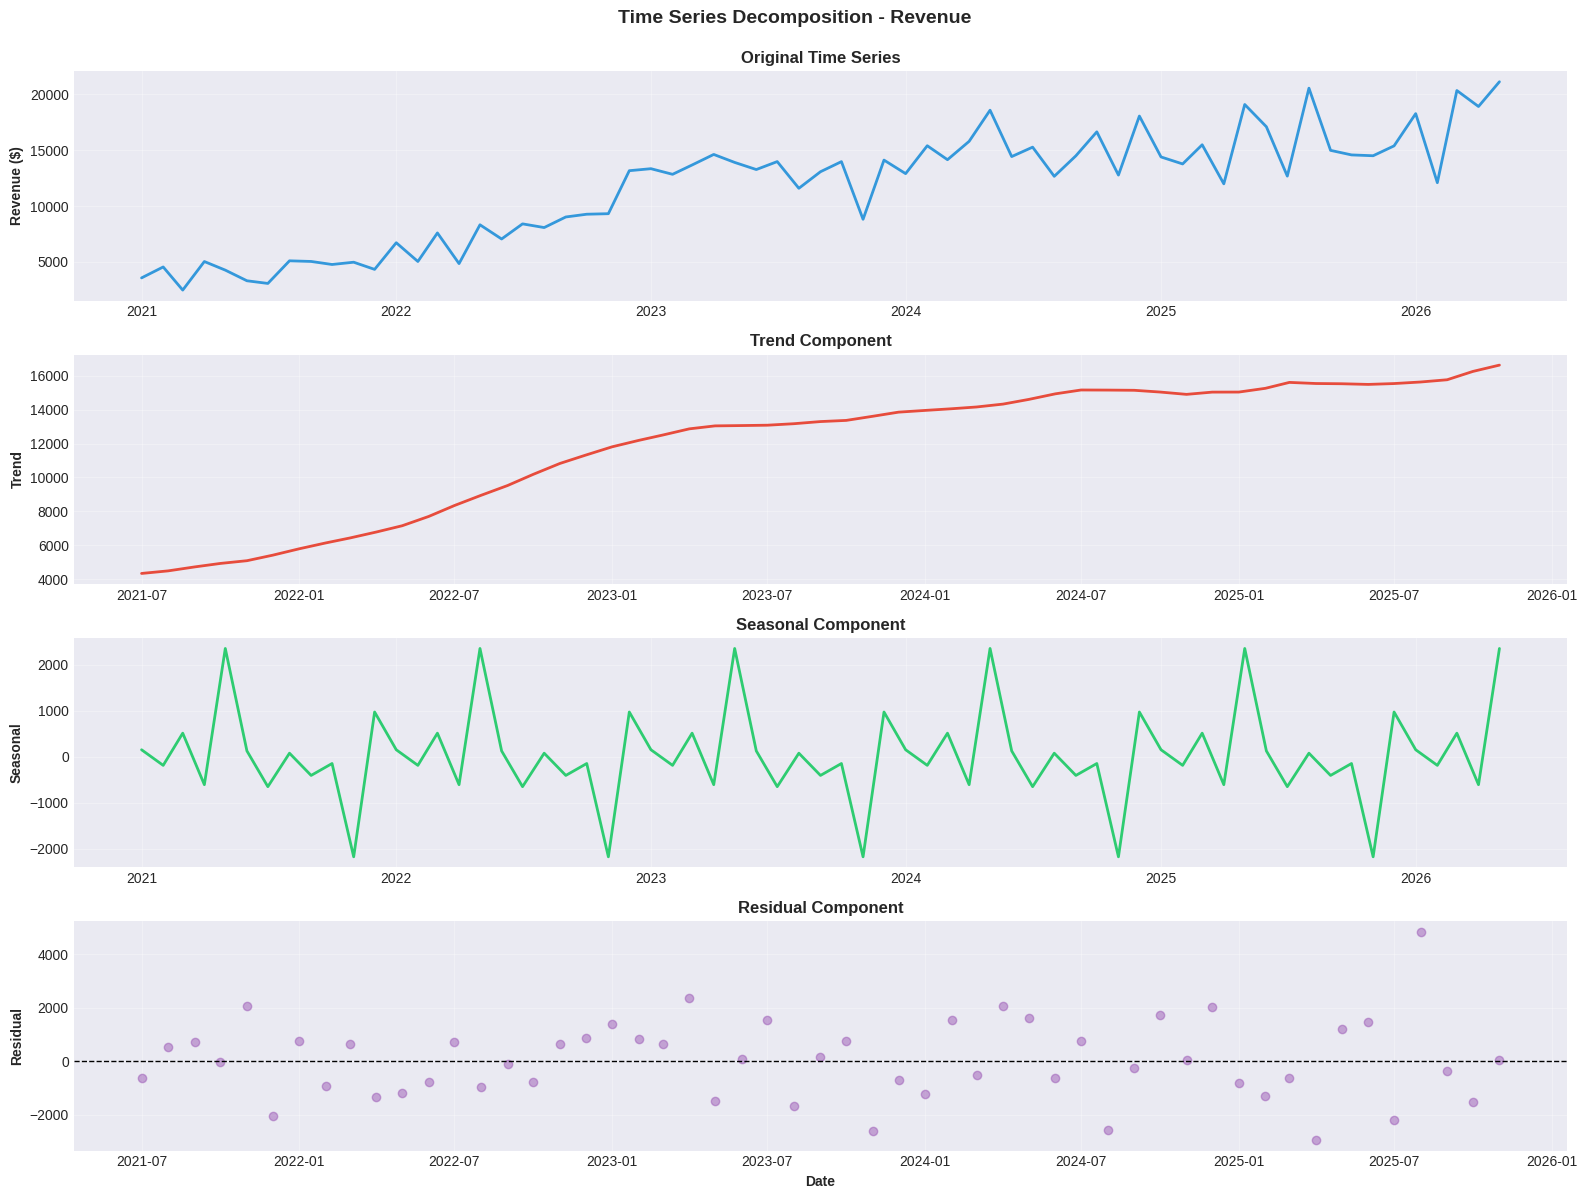


 Decomposition Analysis:
   • Seasonal Strength: 0.326 (0=none, 1=perfect)
   • Trend Strength: 0.874
   Weak seasonality - plain ARIMA may suffice

--------------------------------------------------------------------------------
3.3: STATIONARITY TESTING (Augmented Dickey-Fuller Test)
--------------------------------------------------------------------------------

Stationarity is crucial for ARIMA modeling.
A stationary series has:
  • Constant mean over time
  • Constant variance over time
  • No seasonality

ADF Test:
  • H0 (null): Series has a unit root (non-stationary)
  • H1 (alternative): Series is stationary
  • If p-value < 0.05, we reject H0 (series is stationary)


ADF Test Results:
   • ADF Statistic: -1.0940
   • P-value: 0.7175
   • Critical Values:
      - 1%: -3.5507
      - 5%: -2.9138
      - 10%: -2.5946

   Series is non-stationary (p >= 0.05)
   → Differencing required for ARIMA modeling

   After first differencing:
   • ADF Statistic: -3.8673
   • P-value: 0.0

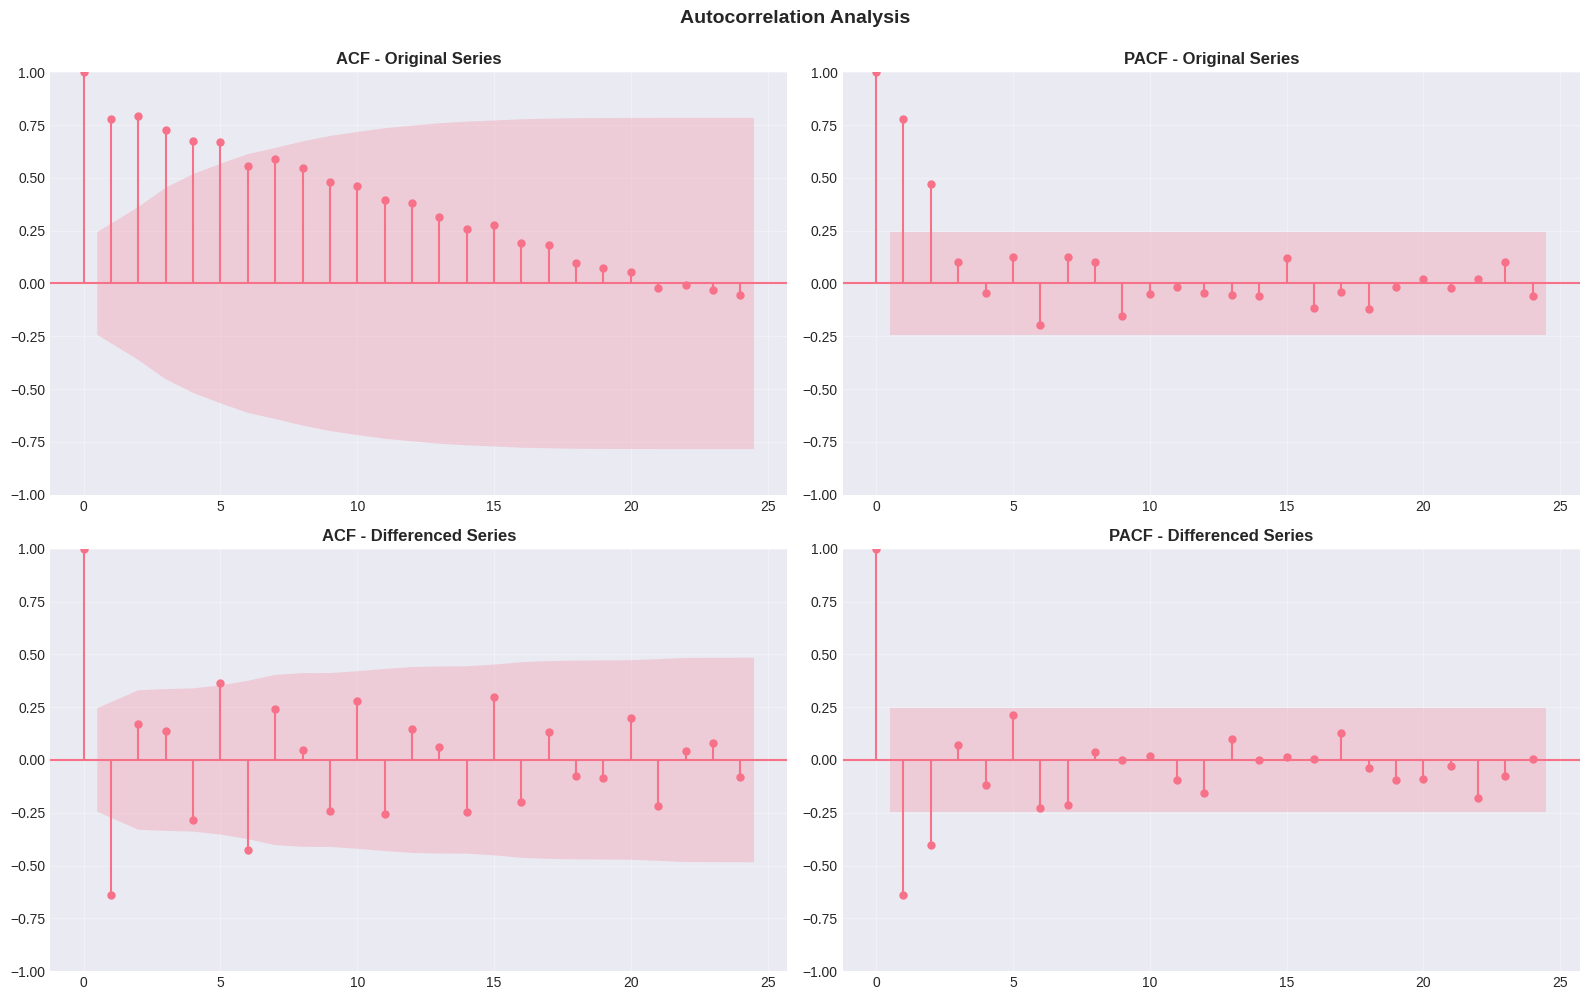


--------------------------------------------------------------------------------
3.5: ARIMA MODEL TRAINING
--------------------------------------------------------------------------------

ARIMA Model Parameters:
  • p: AR (autoregressive) order - based on PACF
  • d: Differencing order - based on stationarity test
  • q: MA (moving average) order - based on ACF

We'll test multiple parameter combinations and select the best model.


Data Split:
   • Training Set: 52 periods (2021-01 to 2025-04)
   • Test Set: 13 periods (2025-05 to 2026-05)

 Searching for optimal ARIMA parameters...
Testing combinations of p=[0,1,2], d=[0,1], q=[0,1,2]

   ARIMA(0,0,0) - AIC: 1026.83
   ARIMA(0,0,1) - AIC: 998.53
   ARIMA(0,0,2) - AIC: 978.46
   ARIMA(0,1,0) - AIC: 934.93
   ARIMA(0,1,1) - AIC: 917.91
   ARIMA(0,1,2) - AIC: 912.66
   ARIMA(1,0,0) - AIC: 955.45
   ARIMA(1,0,1) - AIC: 940.55
   ARIMA(1,0,2) - AIC: 934.50
   ARIMA(1,1,0) - AIC: 914.47
   ARIMA(1,1,1) - AIC: 914.69
   ARIMA(1,1,2) - AIC

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


                               SARIMAX Results                                
Dep. Variable:          total_revenue   No. Observations:                   52
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -451.873
Date:                Tue, 29 Sep 2026   AIC                            911.747
Time:                        08:43:05   BIC                            919.474
Sample:                    01-01-2021   HQIC                           914.700
                         - 04-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3999      0.177     -7.925      0.000      -1.746      -1.054
ar.L2         -0.6434      0.118     -5.459      0.000      -0.874      -0.412
ma.L1          0.7168      0.218      3.289      0.0

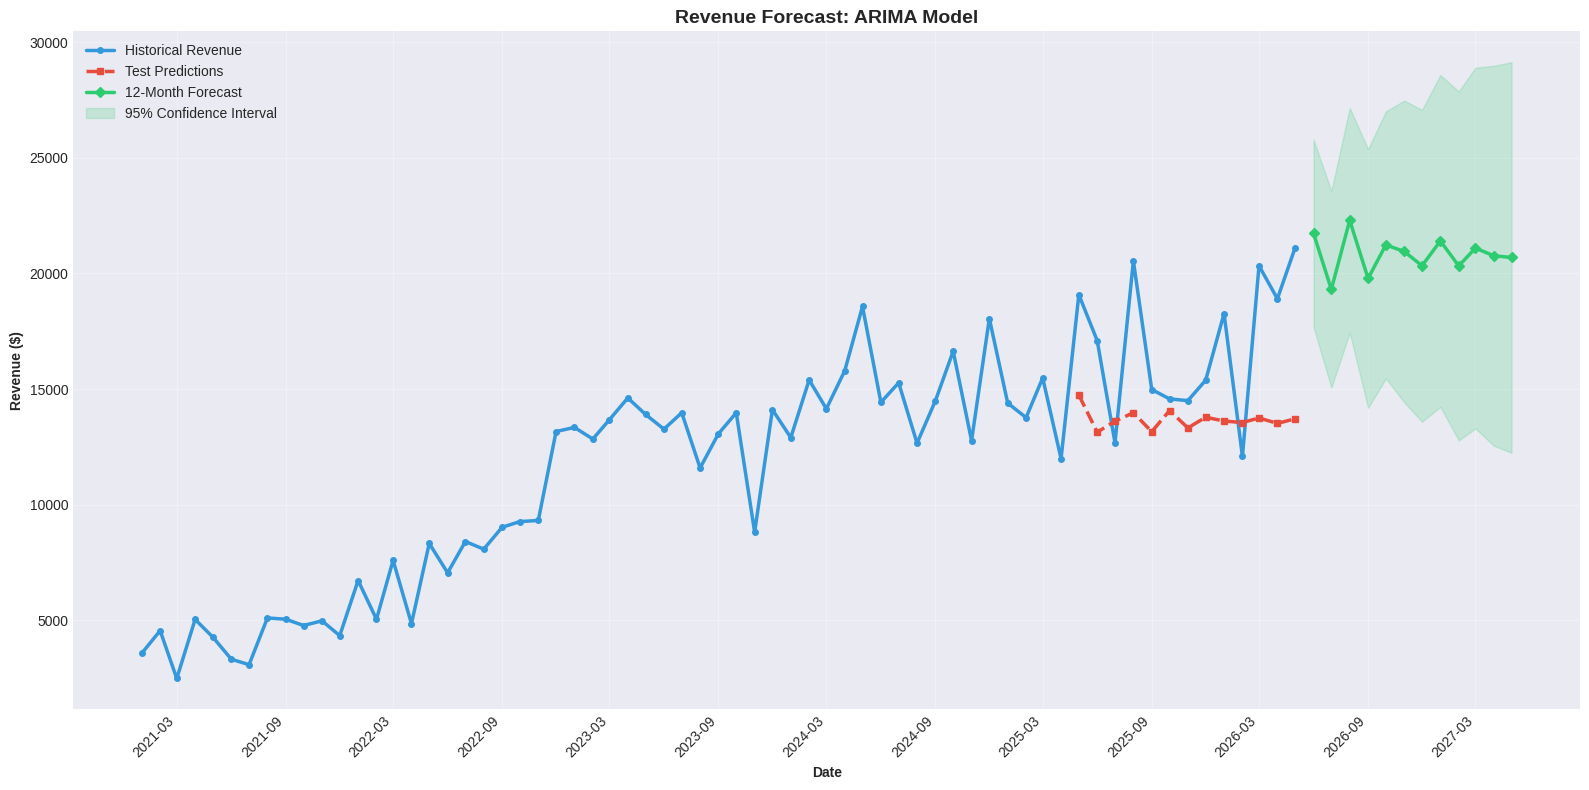


--------------------------------------------------------------------------------
3.7: FACEBOOK PROPHET FORECASTING
--------------------------------------------------------------------------------

Prophet is particularly good at:
  • Handling missing data and outliers
  • Detecting multiple seasonalities
  • Including holidays and special events
  • Providing interpretable components
    

 Training Prophet model...
 Prophet model trained successfully!

 Prophet 12-Month Forecast:

  Month  Forecasted_Revenue  Lower_95%  Upper_95%
2026-06            18458.60   16095.50   20559.01
2026-07            18437.42   16033.33   20678.32
2026-08            18827.90   16493.40   21131.66
2026-09            18779.81   16577.93   20874.95
2026-10            19082.21   16668.36   21231.70
2026-11            16840.94   14564.89   18857.60
2026-12            20004.24   17729.17   22409.24
2027-01            20124.87   17983.86   22335.13
2027-02            19664.69   17427.54   22039.15
2027-03     

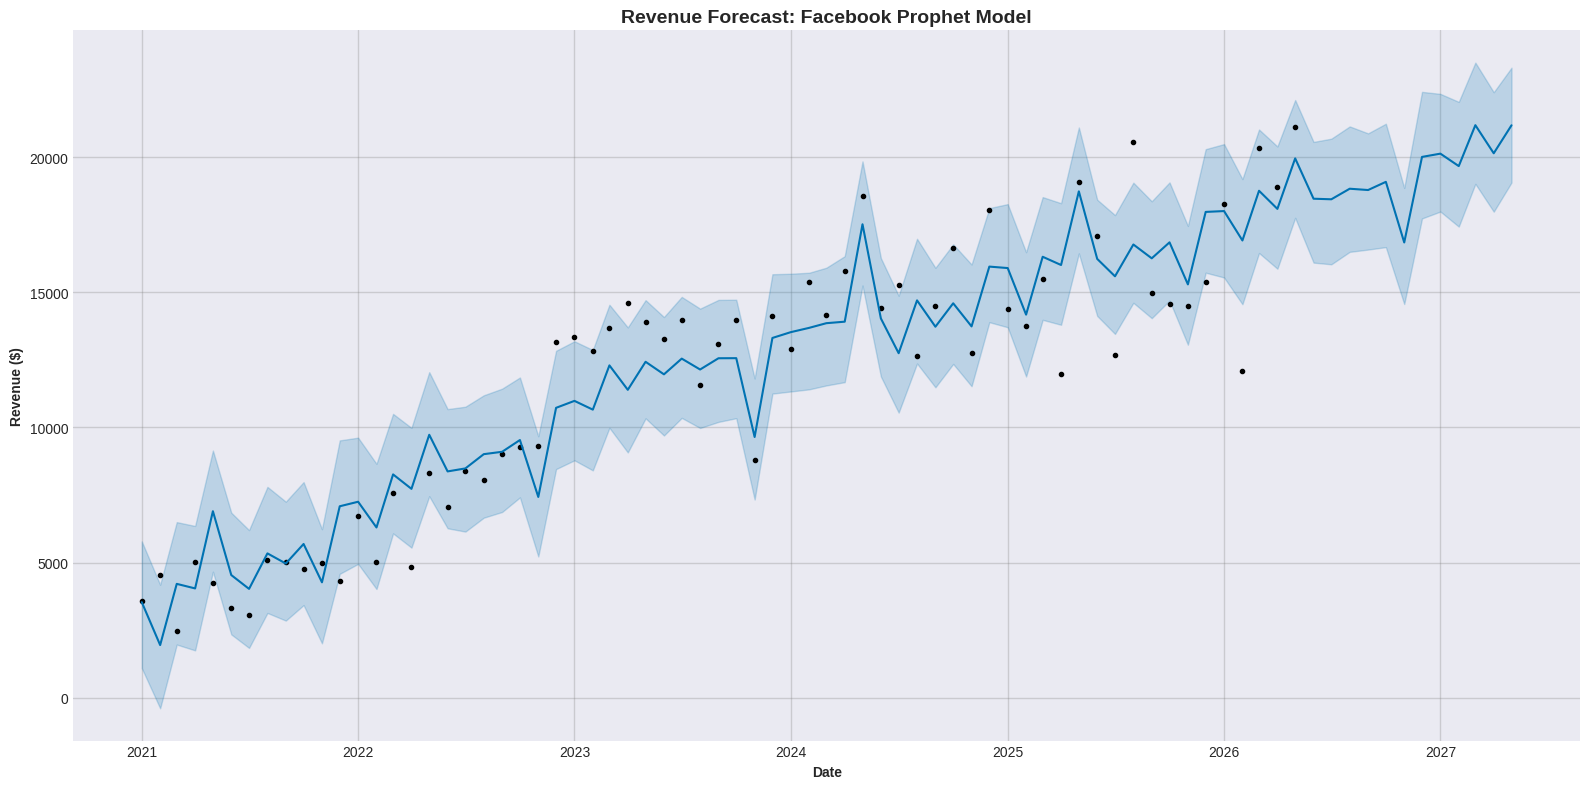

 Saved: financial_viz/06_prophet_components.png


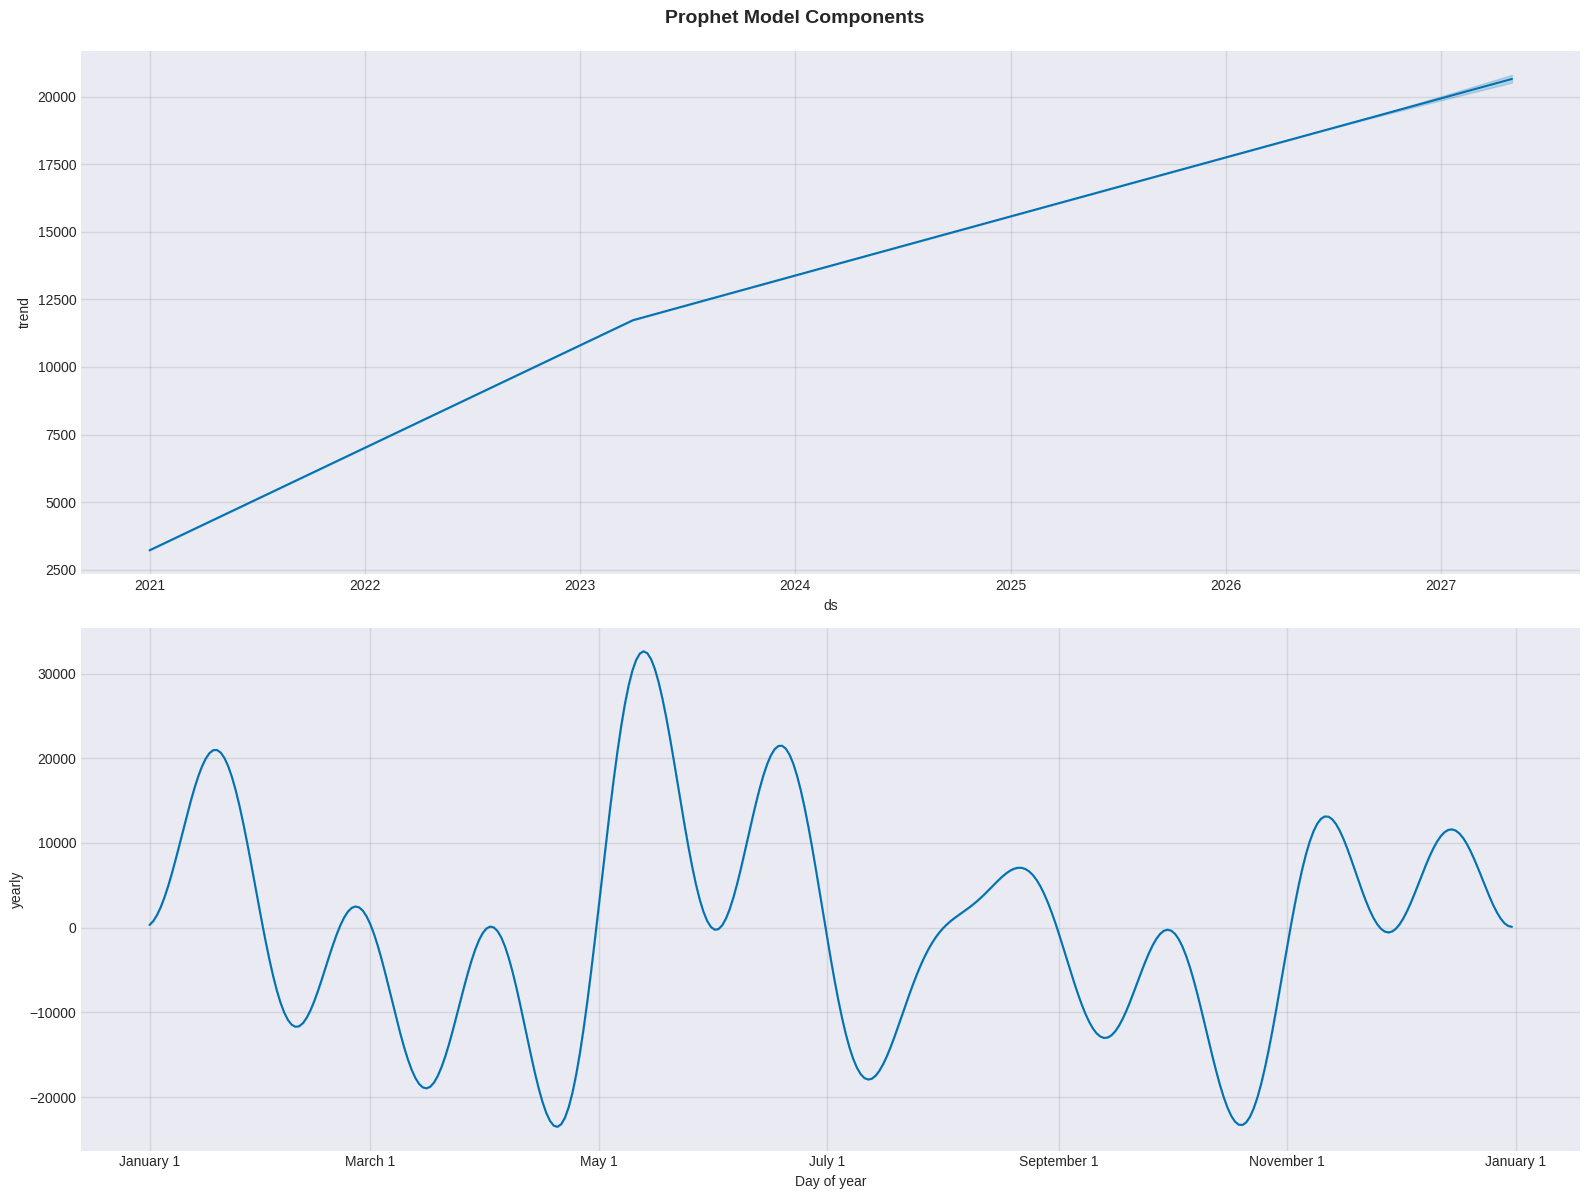


--------------------------------------------------------------------------------
3.8: EXPONENTIAL SMOOTHING (HOLT-WINTERS) & MODEL COMPARISON
--------------------------------------------------------------------------------

 Test-set comparison (lower is better):

                  Model     MAE    RMSE  MAPE_%
         ARIMA(2, 1, 1) 3569.21 4270.01   19.46
Holt-Winters (additive) 2781.34 3272.15   16.05

 Lowest test MAPE: Holt-Winters (additive)

 Holt-Winters total 12-month forecast: $236,616.70
 ARIMA total 12-month forecast:        $249,930.87

 Revenue Forecasting Complete!



In [4]:
# ============================================================================
# SECTION 3: REVENUE FORECASTING - TIME SERIES ANALYSIS
# (Rewritten for the retail dataset. Needs Section 0 and Section 2 run first.)
# ============================================================================

print("\n" + "="*80)
print("SECTION 3: REVENUE FORECASTING - TIME SERIES ANALYSIS")
print("="*80)

print("""
Time series forecasting helps us:
1. Predict future revenue with confidence intervals
2. Identify seasonal patterns and trends
3. Support strategic planning and budgeting
4. Set realistic targets and goals

We'll use multiple techniques:
- Statistical decomposition
- ARIMA models
- Facebook Prophet (if available)
- Exponential smoothing (Holt-Winters)
""")

# ========================================================================
# 3.1: TIME SERIES PREPARATION
# ========================================================================

print("\n" + "-"*80)
print("3.1: TIME SERIES DATA PREPARATION")
print("-"*80)

# The data ends on ANALYSIS_DATE (a single day into the last month), so the
# final month is incomplete. Drop it, otherwise the models read it as a crash.
last_month_start = ANALYSIS_DATE.to_period('M').to_timestamp()
last_month_is_partial = ANALYSIS_DATE != (ANALYSIS_DATE + pd.offsets.MonthEnd(0))

ts_source = monthly_revenue.copy()
if last_month_is_partial:
    ts_source = ts_source[ts_source['year_month'] < last_month_start]
    print(f"\n Excluded incomplete final month: {last_month_start:%Y-%m}")

ts_data = ts_source[['year_month', 'total_revenue']].copy()
ts_data.set_index('year_month', inplace=True)
ts_data.index.freq = 'MS'  # Month Start frequency

print(f"\n Time Series Overview:")
print(f"   • Start Date: {ts_data.index.min():%Y-%m-%d}")
print(f"   • End Date: {ts_data.index.max():%Y-%m-%d}")
print(f"   • Number of Periods: {len(ts_data)}")
print(f"   • Frequency: Monthly")

# Check for missing periods
expected_periods = pd.date_range(start=ts_data.index.min(),
                                  end=ts_data.index.max(),
                                  freq='MS')
missing_periods = expected_periods.difference(ts_data.index)
if len(missing_periods) > 0:
    print(f"   Missing periods detected: {len(missing_periods)}")
else:
    print(f"   No missing periods")

# ========================================================================
# 3.2: TIME SERIES DECOMPOSITION
# ========================================================================

print("\n" + "-"*80)
print("3.2: TIME SERIES DECOMPOSITION")
print("-"*80)

print("\nDecomposing time series into:")
print("   • Trend: Long-term progression")
print("   • Seasonality: Repeating patterns")
print("   • Residual: Random fluctuations\n")

decomposition = seasonal_decompose(ts_data['total_revenue'],
                                   model='additive',
                                   period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

axes[0].plot(ts_data.index, ts_data['total_revenue'], linewidth=2, color='#3498db')
axes[0].set_ylabel('Revenue ($)', fontweight='bold')
axes[0].set_title('Original Time Series', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition.trend.index, decomposition.trend, linewidth=2, color='#e74c3c')
axes[1].set_ylabel('Trend', fontweight='bold')
axes[1].set_title('Trend Component', fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, linewidth=2, color='#2ecc71')
axes[2].set_ylabel('Seasonal', fontweight='bold')
axes[2].set_title('Seasonal Component', fontweight='bold', fontsize=12)
axes[2].grid(True, alpha=0.3)

axes[3].scatter(decomposition.resid.index, decomposition.resid, alpha=0.5, color='#9b59b6')
axes[3].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[3].set_ylabel('Residual', fontweight='bold')
axes[3].set_xlabel('Date', fontweight='bold')
axes[3].set_title('Residual Component', fontweight='bold', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.suptitle('Time Series Decomposition - Revenue', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('financial_viz/02_ts_decomposition.png', dpi=300, bbox_inches='tight')
print(" Saved: financial_viz/02_ts_decomposition.png")
plt.show()

seasonal_strength = 1 - (decomposition.resid.var() / (decomposition.seasonal + decomposition.resid).var())
trend_strength = 1 - (decomposition.resid.var() / (decomposition.trend + decomposition.resid).var())

print(f"\n Decomposition Analysis:")
print(f"   • Seasonal Strength: {seasonal_strength:.3f} (0=none, 1=perfect)")
print(f"   • Trend Strength: {trend_strength:.3f}")
if seasonal_strength > 0.6:
    print(f"   Strong seasonality detected - a seasonal model (SARIMA / Holt-Winters) is worth using")
else:
    print(f"   Weak seasonality - plain ARIMA may suffice")

# ========================================================================
# 3.3: STATIONARITY TEST
# ========================================================================

print("\n" + "-"*80)
print("3.3: STATIONARITY TESTING (Augmented Dickey-Fuller Test)")
print("-"*80)

print("""
Stationarity is crucial for ARIMA modeling.
A stationary series has:
  • Constant mean over time
  • Constant variance over time
  • No seasonality

ADF Test:
  • H0 (null): Series has a unit root (non-stationary)
  • H1 (alternative): Series is stationary
  • If p-value < 0.05, we reject H0 (series is stationary)
""")

adf_result = adfuller(ts_data['total_revenue'].dropna())

print(f"\nADF Test Results:")
print(f"   • ADF Statistic: {adf_result[0]:.4f}")
print(f"   • P-value: {adf_result[1]:.4f}")
print(f"   • Critical Values:")
for key, value in adf_result[4].items():
    print(f"      - {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print(f"\n   Series is stationary (p < 0.05)")
    differencing_needed = False
else:
    print(f"\n   Series is non-stationary (p >= 0.05)")
    print(f"   → Differencing required for ARIMA modeling")
    differencing_needed = True

if differencing_needed:
    ts_data['revenue_diff'] = ts_data['total_revenue'].diff()

    adf_diff = adfuller(ts_data['revenue_diff'].dropna())
    print(f"\n   After first differencing:")
    print(f"   • ADF Statistic: {adf_diff[0]:.4f}")
    print(f"   • P-value: {adf_diff[1]:.4f}")

    if adf_diff[1] < 0.05:
        print(f"   Differenced series is stationary")

# ========================================================================
# 3.4: ACF AND PACF ANALYSIS
# ========================================================================

print("\n" + "-"*80)
print("3.4: ACF & PACF ANALYSIS (For ARIMA Parameter Selection)")
print("-"*80)

print("""
ACF (Autocorrelation Function):
  • Shows correlation between time series and its lagged values
  • Helps determine MA (Moving Average) order (q)

PACF (Partial Autocorrelation Function):
  • Shows correlation between observations at different lags
  • Helps determine AR (Autoregressive) order (p)
""")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_acf(ts_data['total_revenue'].dropna(), lags=24, ax=axes[0, 0])
axes[0, 0].set_title('ACF - Original Series', fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

plot_pacf(ts_data['total_revenue'].dropna(), lags=24, ax=axes[0, 1])
axes[0, 1].set_title('PACF - Original Series', fontweight='bold', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

if differencing_needed:
    plot_acf(ts_data['revenue_diff'].dropna(), lags=24, ax=axes[1, 0])
    axes[1, 0].set_title('ACF - Differenced Series', fontweight='bold', fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)

    plot_pacf(ts_data['revenue_diff'].dropna(), lags=24, ax=axes[1, 1])
    axes[1, 1].set_title('PACF - Differenced Series', fontweight='bold', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 0].plot(range(1, 13), [ts_data[ts_data.index.month == m]['total_revenue'].mean()
                                    for m in range(1, 13)],
                    marker='o', linewidth=2, markersize=8, color='#e74c3c')
    axes[1, 0].set_title('Average Revenue by Month', fontweight='bold', fontsize=12)
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Average Revenue ($)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xticks(range(1, 13))

    axes[1, 1].boxplot([ts_data[ts_data.index.month == m]['total_revenue']
                        for m in range(1, 13)])
    axes[1, 1].set_title('Revenue Distribution by Month', fontweight='bold', fontsize=12)
    axes[1, 1].set_xlabel('Month')
    axes[1, 1].set_ylabel('Revenue ($)')
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Autocorrelation Analysis', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('financial_viz/03_acf_pacf_analysis.png', dpi=300, bbox_inches='tight')
print("\n Saved: financial_viz/03_acf_pacf_analysis.png")
plt.show()

# ========================================================================
# 3.5: ARIMA MODEL TRAINING
# ========================================================================

print("\n" + "-"*80)
print("3.5: ARIMA MODEL TRAINING")
print("-"*80)

print("""
ARIMA Model Parameters:
  • p: AR (autoregressive) order - based on PACF
  • d: Differencing order - based on stationarity test
  • q: MA (moving average) order - based on ACF

We'll test multiple parameter combinations and select the best model.
""")

# Split data: train on first 80%, test on last 20%
train_size = int(len(ts_data) * 0.8)
train_data = ts_data['total_revenue'][:train_size]
test_data = ts_data['total_revenue'][train_size:]

print(f"\nData Split:")
print(f"   • Training Set: {len(train_data)} periods ({train_data.index.min():%Y-%m} to {train_data.index.max():%Y-%m})")
print(f"   • Test Set: {len(test_data)} periods ({test_data.index.min():%Y-%m} to {test_data.index.max():%Y-%m})")

print("\n Searching for optimal ARIMA parameters...")
print("Testing combinations of p=[0,1,2], d=[0,1], q=[0,1,2]\n")

best_aic = np.inf
best_params = None
best_model = None

results_list = []

for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                model = ARIMA(train_data, order=(p, d, q))
                fitted_model = model.fit()
                aic = fitted_model.aic
                results_list.append({'p': p, 'd': d, 'q': q, 'AIC': aic})

                if aic < best_aic:
                    best_aic = aic
                    best_params = (p, d, q)
                    best_model = fitted_model

                print(f"   ARIMA({p},{d},{q}) - AIC: {aic:.2f}")
            except Exception as e:
                print(f"   ARIMA({p},{d},{q}) - Failed: {str(e)[:50]}")
                continue

print(f"\n Best Model: ARIMA{best_params} with AIC = {best_aic:.2f}")

print("\n" + "-"*80)
print("MODEL SUMMARY")
print("-"*80)
print(best_model.summary())

predictions = best_model.forecast(steps=len(test_data))

mae = mean_absolute_error(test_data, predictions)
rmse = np.sqrt(mean_squared_error(test_data, predictions))
mape = np.mean(np.abs((test_data - predictions) / test_data)) * 100

print("\n" + "-"*80)
print("MODEL PERFORMANCE ON TEST SET")
print("-"*80)
print(f"   • MAE (Mean Absolute Error): ${mae:,.2f}")
print(f"   • RMSE (Root Mean Squared Error): ${rmse:,.2f}")
print(f"   • MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

# ========================================================================
# 3.6: FUTURE FORECASTING
# ========================================================================

print("\n" + "-"*80)
print("3.6: REVENUE FORECASTING - NEXT 12 MONTHS")
print("-"*80)

final_model = ARIMA(ts_data['total_revenue'], order=best_params)
final_fitted = final_model.fit()

forecast_periods = 12
forecast = final_fitted.forecast(steps=forecast_periods)
forecast_index = pd.date_range(start=ts_data.index.max() + pd.DateOffset(months=1),
                                periods=forecast_periods,
                                freq='MS')

forecast_df = final_fitted.get_forecast(steps=forecast_periods)
forecast_ci = forecast_df.conf_int()

print(f"\n 12-Month Revenue Forecast:\n")
forecast_summary = pd.DataFrame({
    'Month': forecast_index.strftime('%Y-%m'),
    'Forecasted_Revenue': forecast.values,
    'Lower_95%': forecast_ci.iloc[:, 0].values,
    'Upper_95%': forecast_ci.iloc[:, 1].values
})
print(forecast_summary.to_string(index=False))

print(f"\n Summary Statistics:")
print(f"   • Total Forecasted Revenue (12 months): ${forecast.sum():,.2f}")
print(f"   • Average Monthly Revenue: ${forecast.mean():,.2f}")
print(f"   • Expected Change from Last Month: ${(forecast.iloc[0] - ts_data['total_revenue'].iloc[-1]):,.2f}")

fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(ts_data.index, ts_data['total_revenue'],
        linewidth=2.5, color='#3498db', label='Historical Revenue', marker='o', markersize=4)

ax.plot(test_data.index, predictions,
        linewidth=2.5, color='#e74c3c', label='Test Predictions',
        marker='s', markersize=4, linestyle='--')

ax.plot(forecast_index, forecast,
        linewidth=2.5, color='#2ecc71', label='12-Month Forecast',
        marker='D', markersize=5)

ax.fill_between(forecast_index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color='#2ecc71', alpha=0.2, label='95% Confidence Interval')

ax.set_title('Revenue Forecast: ARIMA Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Revenue ($)', fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('financial_viz/04_arima_forecast.png', dpi=300, bbox_inches='tight')
print("\n Saved: financial_viz/04_arima_forecast.png")
plt.show()

# ========================================================================
# 3.7: PROPHET MODEL (if available)
# ========================================================================

if PROPHET_AVAILABLE:
    print("\n" + "-"*80)
    print("3.7: FACEBOOK PROPHET FORECASTING")
    print("-"*80)

    print("""
Prophet is particularly good at:
  • Handling missing data and outliers
  • Detecting multiple seasonalities
  • Including holidays and special events
  • Providing interpretable components
    """)

    prophet_df = pd.DataFrame({
        'ds': ts_data.index,
        'y': ts_data['total_revenue'].values
    })

    print("\n Training Prophet model...")
    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05
    )

    prophet_model.fit(prophet_df)
    print(" Prophet model trained successfully!")

    future = prophet_model.make_future_dataframe(periods=12, freq='MS')
    prophet_forecast = prophet_model.predict(future)
    prophet_future = prophet_forecast.tail(12)

    print(f"\n Prophet 12-Month Forecast:\n")
    prophet_summary = pd.DataFrame({
        'Month': prophet_future['ds'].dt.strftime('%Y-%m'),
        'Forecasted_Revenue': prophet_future['yhat'].values,
        'Lower_95%': prophet_future['yhat_lower'].values,
        'Upper_95%': prophet_future['yhat_upper'].values
    })
    print(prophet_summary.to_string(index=False))

    fig = prophet_model.plot(prophet_forecast, figsize=(16, 8))
    ax = fig.gca()
    ax.set_title('Revenue Forecast: Facebook Prophet Model', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontweight='bold')
    ax.set_ylabel('Revenue ($)', fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('financial_viz/05_prophet_forecast.png', dpi=300, bbox_inches='tight')
    print("\n Saved: financial_viz/05_prophet_forecast.png")
    plt.show()

    fig = prophet_model.plot_components(prophet_forecast, figsize=(16, 12))
    plt.suptitle('Prophet Model Components', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('financial_viz/06_prophet_components.png', dpi=300, bbox_inches='tight')
    print(" Saved: financial_viz/06_prophet_components.png")
    plt.show()

else:
    print("\n Facebook Prophet not available. Skipping Prophet forecasting.")
    print("Install with: !pip install prophet")

# ========================================================================
# 3.8: EXPONENTIAL SMOOTHING (Holt-Winters)  -- added: listed in your
#      template's intro but not implemented in the original block
# ========================================================================

print("\n" + "-"*80)
print("3.8: EXPONENTIAL SMOOTHING (HOLT-WINTERS) & MODEL COMPARISON")
print("-"*80)

hw_fit = ExponentialSmoothing(
    train_data, trend='add', seasonal='add', seasonal_periods=12
).fit()
hw_pred = hw_fit.forecast(len(test_data))

hw_mae = mean_absolute_error(test_data, hw_pred)
hw_rmse = np.sqrt(mean_squared_error(test_data, hw_pred))
hw_mape = np.mean(np.abs((test_data - hw_pred) / test_data)) * 100

comparison = pd.DataFrame({
    'Model': [f'ARIMA{best_params}', 'Holt-Winters (additive)'],
    'MAE': [mae, hw_mae],
    'RMSE': [rmse, hw_rmse],
    'MAPE_%': [mape, hw_mape]
})
print("\n Test-set comparison (lower is better):\n")
print(comparison.to_string(index=False))

best_name = comparison.sort_values('MAPE_%').iloc[0]['Model']
print(f"\n Lowest test MAPE: {best_name}")

hw_final = ExponentialSmoothing(
    ts_data['total_revenue'], trend='add', seasonal='add', seasonal_periods=12
).fit()
hw_forecast = hw_final.forecast(12)
print(f"\n Holt-Winters total 12-month forecast: ${hw_forecast.sum():,.2f}")
print(f" ARIMA total 12-month forecast:        ${forecast.sum():,.2f}")

print("\n Revenue Forecasting Complete!")
print("="*80 + "\n")


SECTION 4: CUSTOMER CHURN ANALYSIS & PREDICTION

Churn analysis helps us:
1. Identify customers at risk of leaving
2. Understand key churn drivers
3. Calculate financial impact of churn
4. Develop retention strategies

We'll analyze:
  • Churn rates by segment and region
  • Predictive models for churn risk
  • Customer lifetime value impact
  • Intervention opportunities

NOTE: this dataset has no subscription concepts (no MRR, contract length,
NPS score, or support tickets), so those template sections are replaced
with retail-appropriate equivalents: average monthly revenue, tenure,
order frequency, and return rate.


--------------------------------------------------------------------------------
4.1: CHURN OVERVIEW & STATISTICS
--------------------------------------------------------------------------------

 Overall Churn Metrics:
   • Total Customers: 1,000
   • Active Customers: 431 (43.1%)
   • Churned Customers: 569 (56.9%)
   • Churn definition: no order in the 90 days befor

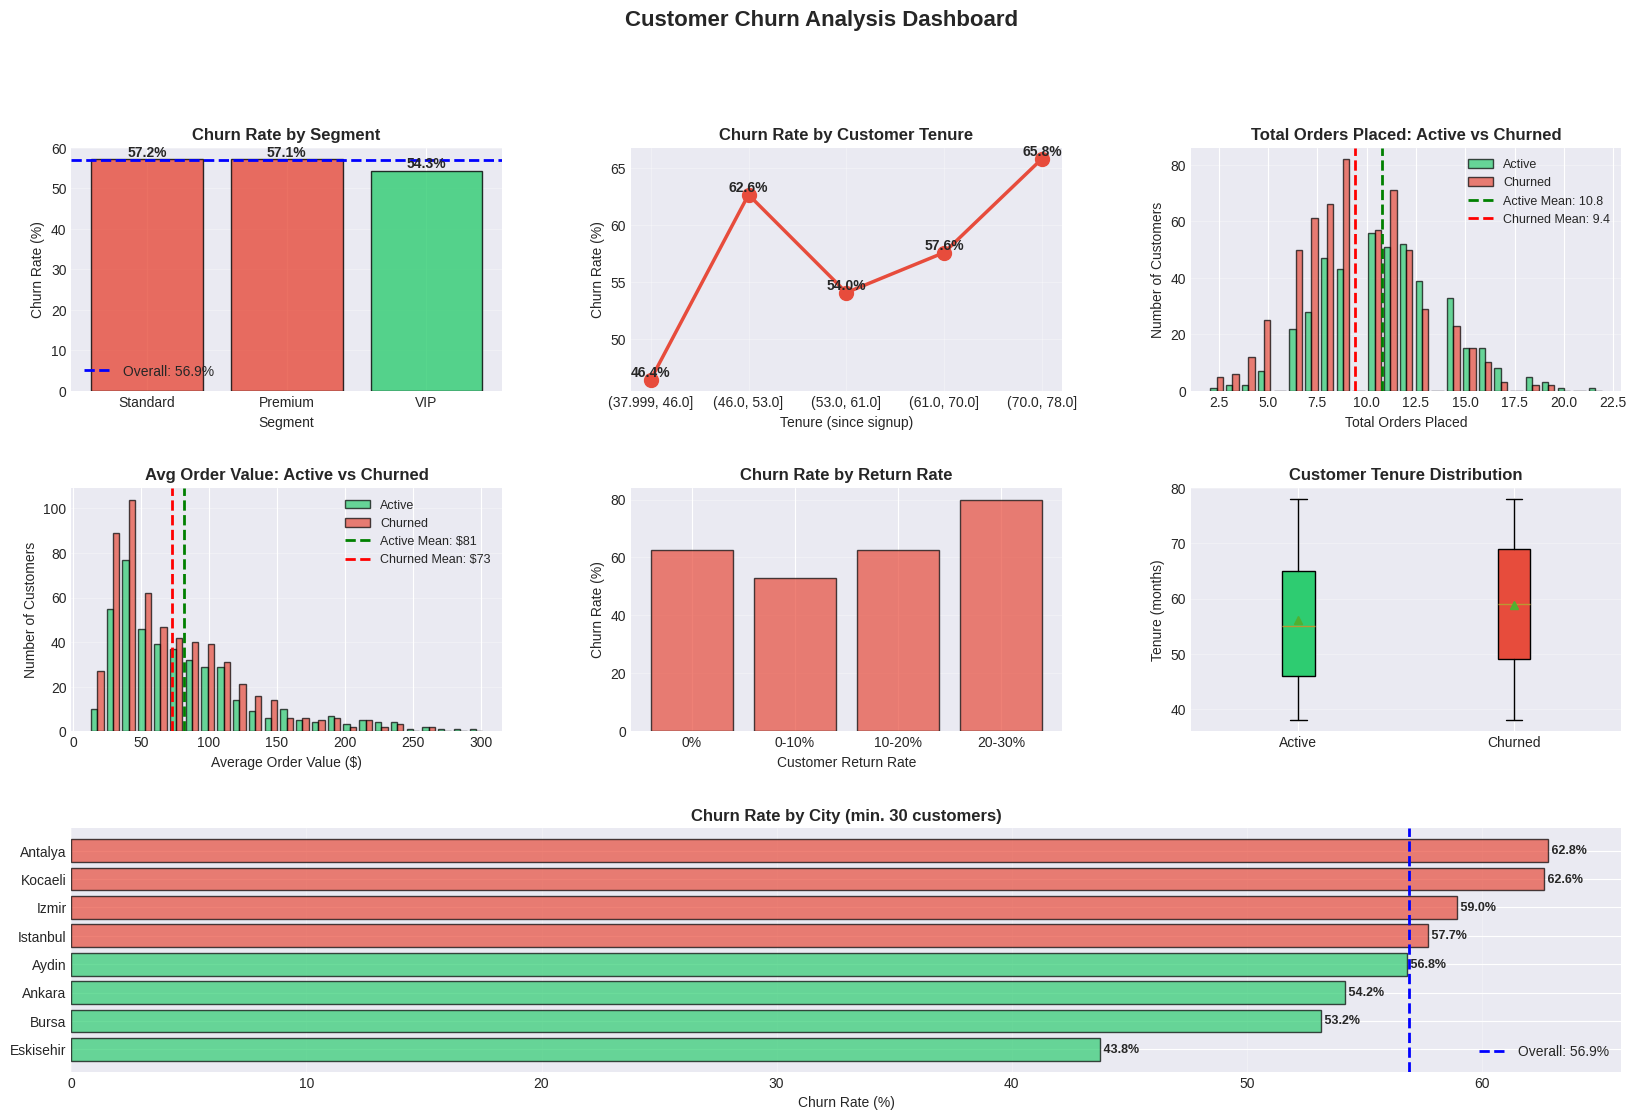


--------------------------------------------------------------------------------
4.3: FEATURE ENGINEERING FOR CHURN PREDICTION
--------------------------------------------------------------------------------

Creating predictive features...
 Created engagement and risk features

 Feature Set:
   • Numeric Features: 10
   • Categorical Features: 3
   • Total Features: 13

 Dataset for Modeling:
   • Total Samples: 1,000
   • Features: 13
   • Churned (Class 1): 569 (56.9%)
   • Active (Class 0): 431 (43.1%)

--------------------------------------------------------------------------------
4.4: CHURN PREDICTION MODEL TRAINING
--------------------------------------------------------------------------------

Data Split:
   • Training Set: 800 samples
   • Test Set: 200 samples

 Training Multiple Models...

 Logistic Regression...
   Accuracy: 0.6650
   ROC AUC: 0.7101

 Random Forest Classifier...
   Accuracy: 0.6700
   ROC AUC: 0.7088

 Gradient Boosting Classifier...
   Accuracy: 0.6500

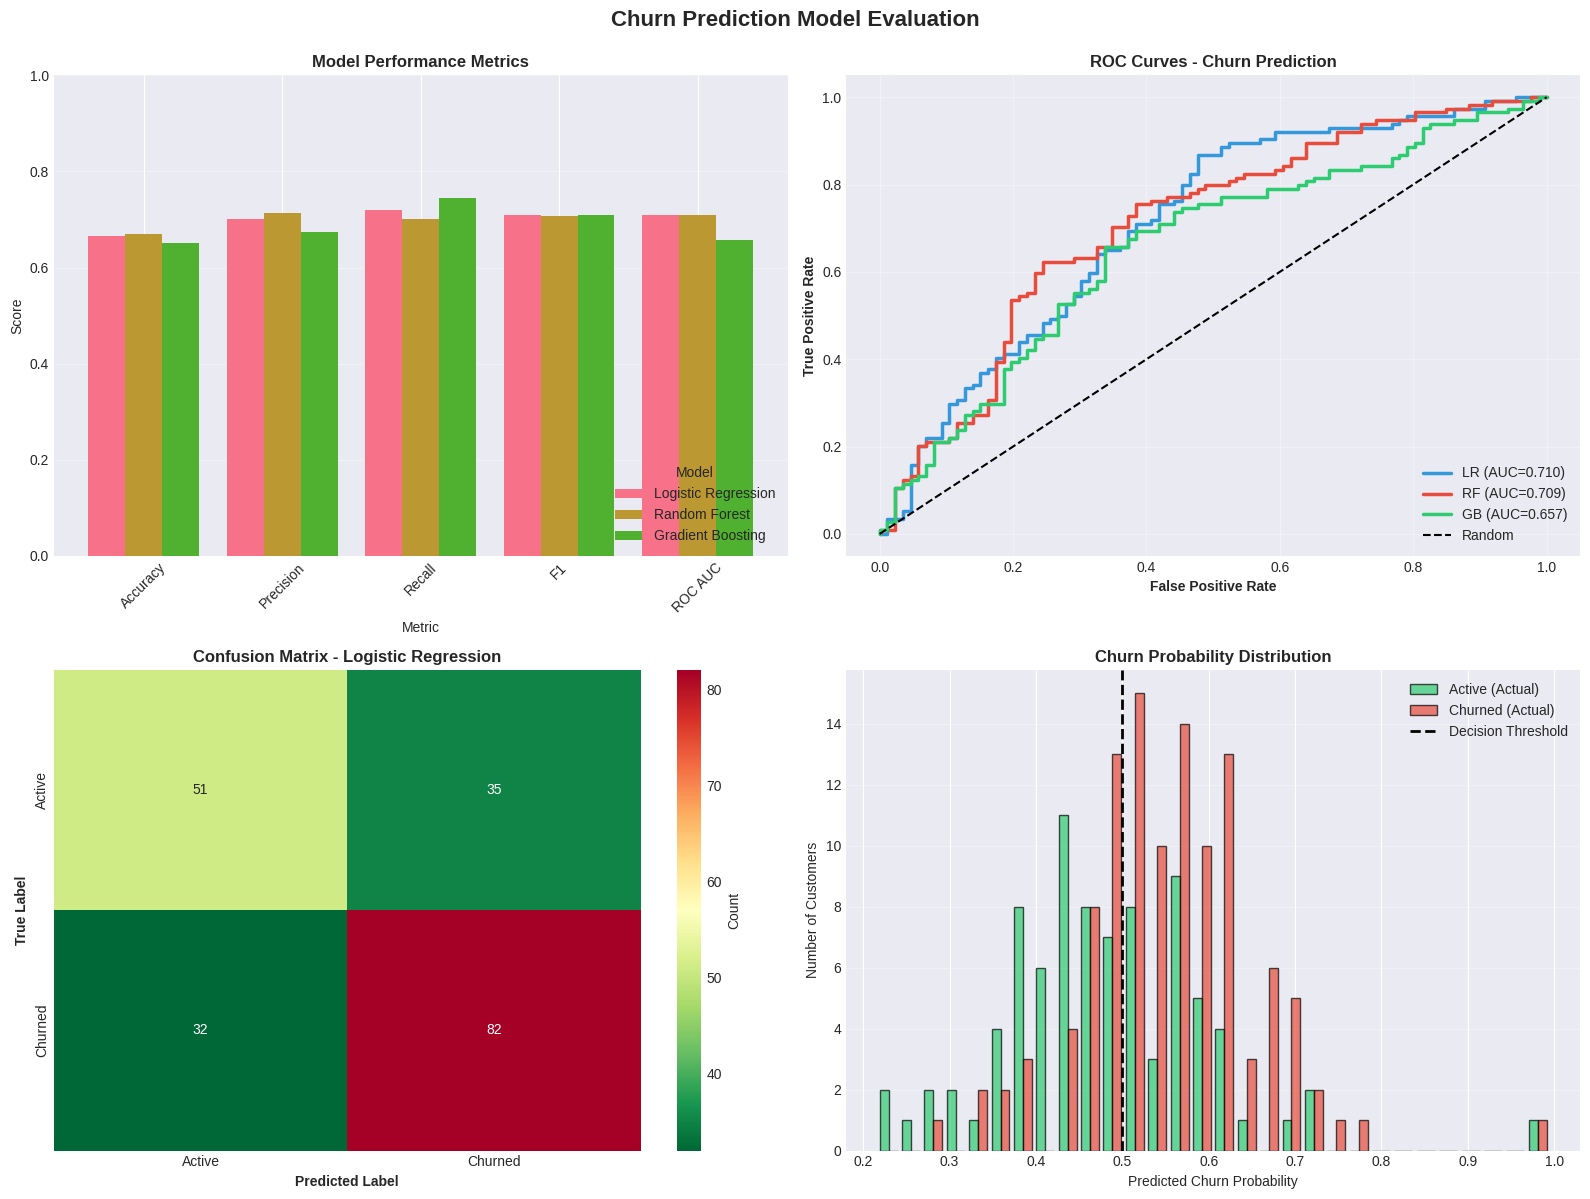


--------------------------------------------------------------------------------
4.6: FEATURE IMPORTANCE ANALYSIS
--------------------------------------------------------------------------------

 Top 15 Most Important Features for Churn Prediction:

                feature  importance
      customer_age_days        0.17
  avg_revenue_per_month        0.16
        avg_order_value        0.14
          tenure_months        0.11
                    Age        0.11
            usage_score        0.11
            return_rate        0.08
              low_usage        0.05
         Region_encoded        0.04
         Gender_encoded        0.02
CustomerSegment_encoded        0.02
       high_return_rate        0.00
           short_tenure        0.00

 Saved: financial_viz/09_churn_feature_importance.png


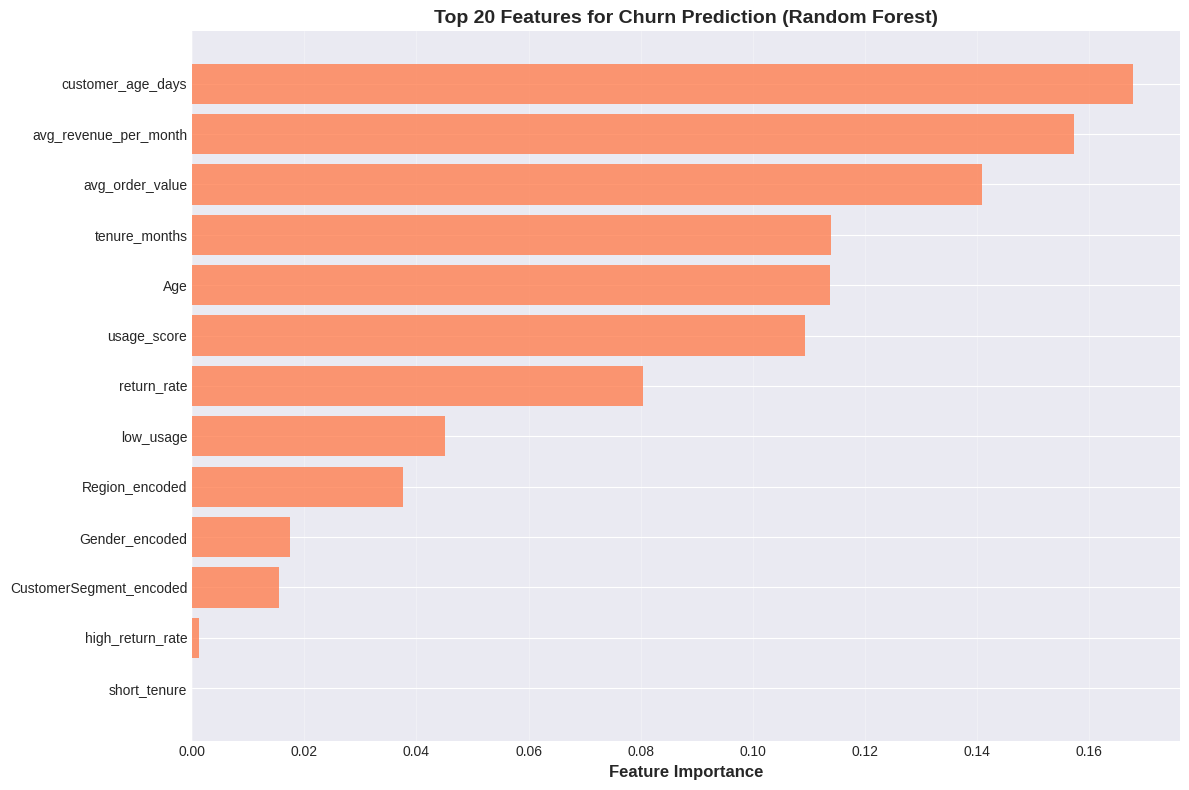


--------------------------------------------------------------------------------
4.7: CUSTOMER RISK STRATIFICATION
--------------------------------------------------------------------------------

 Customer Risk Stratification:

                Total_Customers  Actual_Churned  Churn_Rate  Total_Monthly_Revenue  Total_CLV
risk_category                                                                                
Low Risk                     14               1        7.14                 733.25   31663.78
Medium Risk                 437             210       48.05                8392.21  428747.04
High Risk                   540             352       65.19                4727.00  298429.74
Very High Risk                9               6       66.67                  59.20    3110.57

 At-Risk Customer Summary:
   • Total At-Risk Customers: 549
   • At-Risk Monthly Revenue: $4,786.20/month
   • Annualized Revenue at Risk: $57,434.38
   • Average CLV at Risk: $549.25

 Top 20 of 50 Highe

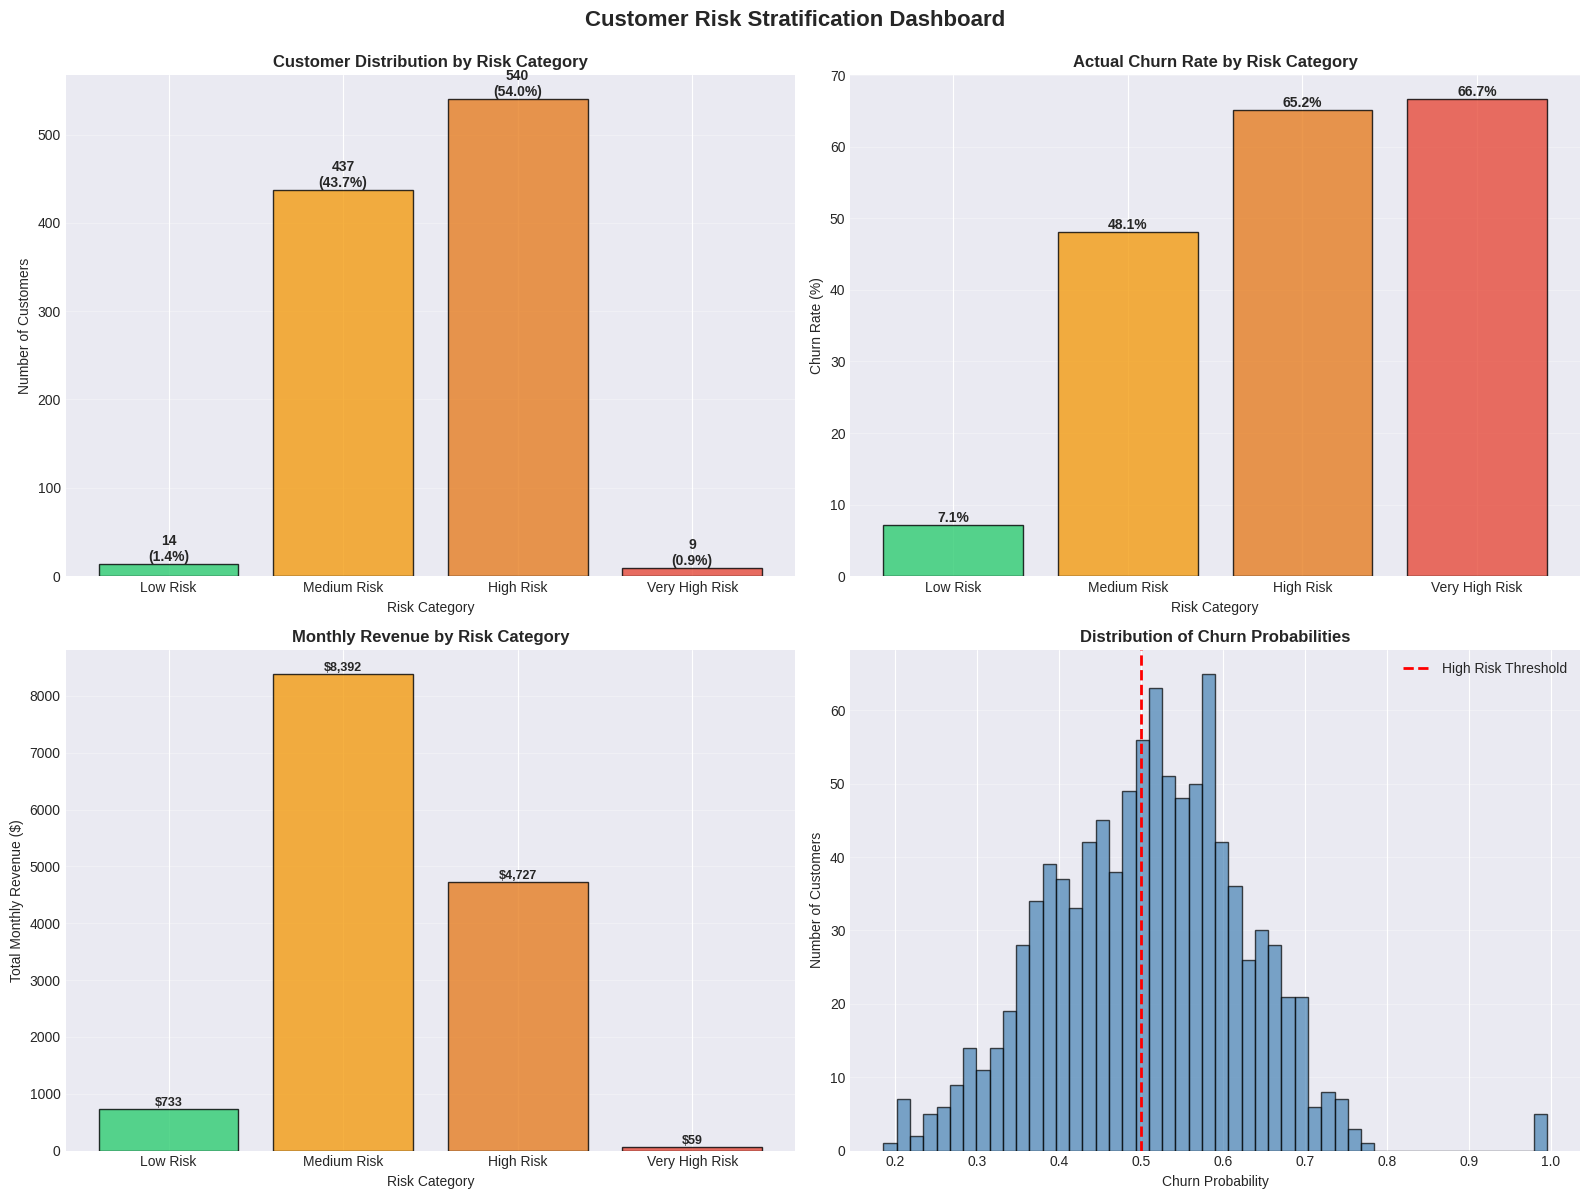


 Churn Analysis Complete!



In [5]:
# ============================================================================
# SECTION 4: CUSTOMER CHURN ANALYSIS
# (Rewritten for the retail dataset. Needs Section 0 and Section 2 run first.)
# ============================================================================

print("\n" + "="*80)
print("SECTION 4: CUSTOMER CHURN ANALYSIS & PREDICTION")
print("="*80)

print("""
Churn analysis helps us:
1. Identify customers at risk of leaving
2. Understand key churn drivers
3. Calculate financial impact of churn
4. Develop retention strategies

We'll analyze:
  • Churn rates by segment and region
  • Predictive models for churn risk
  • Customer lifetime value impact
  • Intervention opportunities

NOTE: this dataset has no subscription concepts (no MRR, contract length,
NPS score, or support tickets), so those template sections are replaced
with retail-appropriate equivalents: average monthly revenue, tenure,
order frequency, and return rate.
""")

# ========================================================================
# 4.1: CHURN OVERVIEW & STATISTICS
# ========================================================================

print("\n" + "-"*80)
print("4.1: CHURN OVERVIEW & STATISTICS")
print("-"*80)

total_customers = len(customers)
churned_customers = customers['is_churned'].sum()
active_customers = total_customers - churned_customers
overall_churn_rate = (churned_customers / total_customers) * 100

print(f"\n Overall Churn Metrics:")
print(f"   • Total Customers: {total_customers:,}")
print(f"   • Active Customers: {active_customers:,} ({active_customers/total_customers*100:.1f}%)")
print(f"   • Churned Customers: {churned_customers:,} ({overall_churn_rate:.1f}%)")
print(f"   • Churn definition: no order in the {CHURN_THRESHOLD_DAYS} days before {ANALYSIS_DATE:%Y-%m-%d}")

print(f"\n Churn Rate by Customer Segment:")
churn_by_segment = customers.groupby('CustomerSegment').agg({'is_churned': ['sum', 'mean', 'count']})
churn_by_segment.columns = ['Churned_Count', 'Churn_Rate', 'Total_Customers']
churn_by_segment['Churn_Rate'] = churn_by_segment['Churn_Rate'] * 100
churn_by_segment = churn_by_segment.sort_values('Churn_Rate', ascending=False)
print(churn_by_segment.to_string())

# Template's "Churn by Plan" -> no subscription plan here; Region is the
# closest equivalent grouping dimension available.
print(f"\n Churn Rate by Region:")
churn_by_region = customers.groupby('Region').agg({'is_churned': ['sum', 'mean', 'count']})
churn_by_region.columns = ['Churned_Count', 'Churn_Rate', 'Total_Customers']
churn_by_region['Churn_Rate'] = churn_by_region['Churn_Rate'] * 100
churn_by_region = churn_by_region.sort_values('Churn_Rate', ascending=False)
print(churn_by_region.to_string())

# Template's "Lost MRR" -> no recurring revenue here. We report the actual
# historical revenue already earned from churned customers (equivalent to
# lost CLV), which is the retail analogue.
churned_revenue_lost = customers[customers['is_churned'] == 1]['total_revenue'].sum()

print(f"\n Financial Impact of Churn:")
print(f"   • Historical Revenue From Churned Customers: ${churned_revenue_lost:,.2f}")
print(f"   • Share of Total Revenue: {churned_revenue_lost / customers['total_revenue'].sum() * 100:.1f}%")

# ========================================================================
# 4.2: CHURN ANALYSIS VISUALIZATIONS
# ========================================================================

print("\n" + "-"*80)
print("4.2: CHURN ANALYSIS VISUALIZATIONS")
print("-"*80)

fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

# 1. Churn Rate by Segment
ax1 = fig.add_subplot(gs[0, 0])
colors_churn = ['#e74c3c' if x > overall_churn_rate else '#2ecc71'
                for x in churn_by_segment['Churn_Rate']]
ax1.bar(churn_by_segment.index, churn_by_segment['Churn_Rate'],
        color=colors_churn, alpha=0.8, edgecolor='black')
ax1.axhline(y=overall_churn_rate, color='blue', linestyle='--',
            label=f'Overall: {overall_churn_rate:.1f}%', linewidth=2)
ax1.set_title('Churn Rate by Segment', fontweight='bold', fontsize=12)
ax1.set_ylabel('Churn Rate (%)')
ax1.set_xlabel('Segment')
for i, v in enumerate(churn_by_segment['Churn_Rate']):
    ax1.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Churn Rate by Tenure Bucket (replaces template's "Contract Length" —
#    no contracts exist here; tenure = months since signup is the analogue)
ax2 = fig.add_subplot(gs[0, 1])
customers['SignUpDate'] = pd.to_datetime(customers['SignUpDate'])
customers['tenure_months'] = (
    (ANALYSIS_DATE - customers['SignUpDate']).dt.days / 30
).round().astype(int)
# Bin by actual data range rather than fixed months — this dataset's
# customers all signed up years ago (relative to ANALYSIS_DATE), so
# fixed 0-6/6-12mo buckets would put everyone in one bucket. Quartiles
# guarantee a meaningful spread whatever the tenure range turns out to be.
customers['tenure_bucket'] = pd.qcut(customers['tenure_months'], q=5, duplicates='drop')
churn_by_tenure = customers.groupby('tenure_bucket', observed=True)['is_churned'].mean() * 100
ax2.plot(churn_by_tenure.index.astype(str), churn_by_tenure.values,
         marker='o', linewidth=2.5, markersize=10, color='#e74c3c')
ax2.set_title('Churn Rate by Customer Tenure', fontweight='bold', fontsize=12)
ax2.set_xlabel('Tenure (since signup)')
ax2.set_ylabel('Churn Rate (%)')
ax2.grid(True, alpha=0.3)
for x, y in zip(range(len(churn_by_tenure)), churn_by_tenure.values):
    ax2.text(x, y, f'{y:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. Order Count Distribution: Churned vs Active (replaces "Usage Score")
ax3 = fig.add_subplot(gs[0, 2])
churned_usage = customers[customers['is_churned'] == 1]['usage_score']
active_usage = customers[customers['is_churned'] == 0]['usage_score']
ax3.hist([active_usage, churned_usage], bins=25, label=['Active', 'Churned'],
         color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
ax3.axvline(active_usage.mean(), color='green', linestyle='--', linewidth=2,
            label=f'Active Mean: {active_usage.mean():.1f}')
ax3.axvline(churned_usage.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Churned Mean: {churned_usage.mean():.1f}')
ax3.set_title('Total Orders Placed: Active vs Churned', fontweight='bold', fontsize=12)
ax3.set_xlabel('Total Orders Placed')
ax3.set_ylabel('Number of Customers')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# 4. Average Order Value Distribution (replaces "NPS Score" — no survey
#    data exists here; spend-per-order is the closest satisfaction proxy)
ax4 = fig.add_subplot(gs[1, 0])
customers['avg_order_value'] = (customers['total_revenue'] / customers['order_count'].replace(0, np.nan))
churned_aov = customers[customers['is_churned'] == 1]['avg_order_value'].dropna()
active_aov = customers[customers['is_churned'] == 0]['avg_order_value'].dropna()
ax4.hist([active_aov, churned_aov], bins=25, label=['Active', 'Churned'],
         color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
ax4.axvline(active_aov.mean(), color='green', linestyle='--', linewidth=2,
            label=f'Active Mean: ${active_aov.mean():.0f}')
ax4.axvline(churned_aov.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Churned Mean: ${churned_aov.mean():.0f}')
ax4.set_title('Avg Order Value: Active vs Churned', fontweight='bold', fontsize=12)
ax4.set_xlabel('Average Order Value ($)')
ax4.set_ylabel('Number of Customers')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# 5. Return Rate vs Churn (replaces "Support Tickets" — no ticket data
#    exists here; return rate is a real, comparable friction signal)
ax5 = fig.add_subplot(gs[1, 1])
return_rate_by_cust = transactions.groupby('CustomerID')['IsReturned'].mean().rename('return_rate')
customers_rr = customers.merge(return_rate_by_cust, on='CustomerID', how='left')
customers_rr['return_rate'] = customers_rr['return_rate'].fillna(0)
customers['return_rate'] = customers_rr['return_rate'].values
return_bins = pd.cut(customers['return_rate'], bins=[-0.01, 0, 0.1, 0.2, 0.3, 1.0],
                      labels=['0%', '0-10%', '10-20%', '20-30%', '30%+'])
churn_by_return = customers.groupby(return_bins, observed=True)['is_churned'].mean() * 100
ax5.bar(churn_by_return.index.astype(str), churn_by_return.values,
        color='#e74c3c', alpha=0.7, edgecolor='black')
ax5.set_title('Churn Rate by Return Rate', fontweight='bold', fontsize=12)
ax5.set_xlabel('Customer Return Rate')
ax5.set_ylabel('Churn Rate (%)')
ax5.grid(axis='y', alpha=0.3)

# 6. Tenure Distribution by Churn Status (replaces "Customer Lifetime")
ax6 = fig.add_subplot(gs[1, 2])
churned_tenure = customers[customers['is_churned'] == 1]['tenure_months']
active_tenure = customers[customers['is_churned'] == 0]['tenure_months']
bp = ax6.boxplot([active_tenure, churned_tenure],
                  tick_labels=['Active', 'Churned'],
                  patch_artist=True, showmeans=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
ax6.set_title('Customer Tenure Distribution', fontweight='bold', fontsize=12)
ax6.set_ylabel('Tenure (months)')
ax6.grid(axis='y', alpha=0.3)

# 7. Churn by City (replaces template's "Churn by Industry")
ax7 = fig.add_subplot(gs[2, :])
churn_by_city = customers.groupby('City').agg({'is_churned': ['mean', 'count']})
churn_by_city.columns = ['Churn_Rate', 'Count']
churn_by_city = churn_by_city[churn_by_city['Count'] >= 30]  # filter small groups
churn_by_city['Churn_Rate'] = churn_by_city['Churn_Rate'] * 100
churn_by_city = churn_by_city.sort_values('Churn_Rate', ascending=True)

colors_city = ['#e74c3c' if x > overall_churn_rate else '#2ecc71'
               for x in churn_by_city['Churn_Rate']]
ax7.barh(churn_by_city.index, churn_by_city['Churn_Rate'],
         color=colors_city, alpha=0.7, edgecolor='black')
ax7.axvline(x=overall_churn_rate, color='blue', linestyle='--',
            label=f'Overall: {overall_churn_rate:.1f}%', linewidth=2)
ax7.set_title('Churn Rate by City (min. 30 customers)', fontweight='bold', fontsize=12)
ax7.set_xlabel('Churn Rate (%)')
ax7.legend()
ax7.grid(axis='x', alpha=0.3)
for i, v in enumerate(churn_by_city['Churn_Rate']):
    ax7.text(v, i, f' {v:.1f}%', va='center', fontweight='bold', fontsize=9)

plt.suptitle('Customer Churn Analysis Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('financial_viz/07_churn_analysis.png', dpi=300, bbox_inches='tight')
print("\n Saved: financial_viz/07_churn_analysis.png")
plt.show()

# ========================================================================
# 4.3: FEATURE ENGINEERING FOR CHURN PREDICTION
# ========================================================================

print("\n" + "-"*80)
print("4.3: FEATURE ENGINEERING FOR CHURN PREDICTION")
print("-"*80)

print("\nCreating predictive features...")

churn_model_data = customers.copy()

# customer_age_days -> days since signup, relative to the dataset's own
# "today" (ANALYSIS_DATE), not the real calendar date
churn_model_data['customer_age_days'] = (ANALYSIS_DATE - churn_model_data['SignUpDate']).dt.days

# avg_revenue_per_month -> retail analogue of MRR
churn_model_data['avg_revenue_per_month'] = (
    churn_model_data['total_revenue'] / churn_model_data['tenure_months'].replace(0, np.nan)
).fillna(churn_model_data['total_revenue'])

# Low engagement flags
median_orders = churn_model_data['usage_score'].median()
churn_model_data['low_usage'] = (churn_model_data['usage_score'] < median_orders).astype(int)
churn_model_data['high_return_rate'] = (churn_model_data['return_rate'] > 0.2).astype(int)
churn_model_data['short_tenure'] = (churn_model_data['tenure_months'] <= 6).astype(int)

print(" Created engagement and risk features")

# Select features for modeling (retail-appropriate set)
# NOTE: 'days_since_last_order' is deliberately EXCLUDED. is_churned is
# defined as days_since_last_order > CHURN_THRESHOLD_DAYS, so including it
# would leak the label directly into the model (this produced a suspicious
# 1.00 ROC AUC when tested) and make the "prediction" meaningless.
feature_columns = [
    'avg_revenue_per_month', 'tenure_months', 'usage_score', 'return_rate',
    'avg_order_value', 'customer_age_days',
    'low_usage', 'high_return_rate', 'short_tenure', 'Age'
]

# Categorical features available in this dataset
categorical_features = ['CustomerSegment', 'Region', 'Gender']

print(f"\n Feature Set:")
print(f"   • Numeric Features: {len(feature_columns)}")
print(f"   • Categorical Features: {len(categorical_features)}")

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    churn_model_data[f'{col}_encoded'] = le.fit_transform(churn_model_data[col].astype(str))
    label_encoders[col] = le
    feature_columns.append(f'{col}_encoded')

print(f"   • Total Features: {len(feature_columns)}")

churn_model_data[feature_columns] = churn_model_data[feature_columns].replace([np.inf, -np.inf], np.nan)
X = churn_model_data[feature_columns].fillna(churn_model_data[feature_columns].median())
y = churn_model_data['is_churned']

print(f"\n Dataset for Modeling:")
print(f"   • Total Samples: {len(X):,}")
print(f"   • Features: {X.shape[1]}")
print(f"   • Churned (Class 1): {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"   • Active (Class 0): {(1-y).sum():,} ({(1-y.mean())*100:.1f}%)")

# ========================================================================
# 4.4: TRAIN CHURN PREDICTION MODELS
# ========================================================================

print("\n" + "-"*80)
print("4.4: CHURN PREDICTION MODEL TRAINING")
print("-"*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData Split:")
print(f"   • Training Set: {len(X_train):,} samples")
print(f"   • Test Set: {len(X_test):,} samples")

X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Training Multiple Models...")

churn_models = {}
churn_results = {}

print("\n Logistic Regression...")
lr_churn = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_churn.fit(X_train_scaled, y_train)
lr_pred = lr_churn.predict(X_test_scaled)
lr_pred_proba = lr_churn.predict_proba(X_test_scaled)[:, 1]

churn_models['Logistic Regression'] = lr_churn
churn_results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, lr_pred),
    'precision': precision_score(y_test, lr_pred),
    'recall': recall_score(y_test, lr_pred),
    'f1': f1_score(y_test, lr_pred),
    'roc_auc': roc_auc_score(y_test, lr_pred_proba)
}
print(f"   Accuracy: {churn_results['Logistic Regression']['accuracy']:.4f}")
print(f"   ROC AUC: {churn_results['Logistic Regression']['roc_auc']:.4f}")

print("\n Random Forest Classifier...")
rf_churn = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_split=50,
    random_state=42, class_weight='balanced', n_jobs=-1
)
rf_churn.fit(X_train, y_train)
rf_pred = rf_churn.predict(X_test)
rf_pred_proba = rf_churn.predict_proba(X_test)[:, 1]

churn_models['Random Forest'] = rf_churn
churn_results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, rf_pred),
    'precision': precision_score(y_test, rf_pred),
    'recall': recall_score(y_test, rf_pred),
    'f1': f1_score(y_test, rf_pred),
    'roc_auc': roc_auc_score(y_test, rf_pred_proba)
}
print(f"   Accuracy: {churn_results['Random Forest']['accuracy']:.4f}")
print(f"   ROC AUC: {churn_results['Random Forest']['roc_auc']:.4f}")

print("\n Gradient Boosting Classifier...")
gb_churn = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_churn.fit(X_train, y_train)
gb_pred = gb_churn.predict(X_test)
gb_pred_proba = gb_churn.predict_proba(X_test)[:, 1]

churn_models['Gradient Boosting'] = gb_churn
churn_results['Gradient Boosting'] = {
    'accuracy': accuracy_score(y_test, gb_pred),
    'precision': precision_score(y_test, gb_pred),
    'recall': recall_score(y_test, gb_pred),
    'f1': f1_score(y_test, gb_pred),
    'roc_auc': roc_auc_score(y_test, gb_pred_proba)
}
print(f"   Accuracy: {churn_results['Gradient Boosting']['accuracy']:.4f}")
print(f"   ROC AUC: {churn_results['Gradient Boosting']['roc_auc']:.4f}")

# ========================================================================
# 4.5: MODEL COMPARISON & EVALUATION
# ========================================================================

print("\n" + "-"*80)
print("4.5: MODEL COMPARISON & EVALUATION")
print("-"*80)

comparison_df = pd.DataFrame(churn_results).T
print("\n Model Performance Comparison:\n")
print(comparison_df.round(4))

best_churn_model_name = comparison_df['roc_auc'].idxmax()
print(f"\n Best Model: {best_churn_model_name}")
print(f"   ROC AUC: {comparison_df.loc[best_churn_model_name, 'roc_auc']:.4f}")

if best_churn_model_name == 'Logistic Regression':
    best_pred = lr_pred
    best_pred_proba = lr_pred_proba
elif best_churn_model_name == 'Random Forest':
    best_pred = rf_pred
    best_pred_proba = rf_pred_proba
else:
    best_pred = gb_pred
    best_pred_proba = gb_pred_proba

print("\n" + "-"*80)
print(f"DETAILED CLASSIFICATION REPORT - {best_churn_model_name}")
print("-"*80)
print(classification_report(y_test, best_pred, target_names=['Active', 'Churned'], digits=4))

cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()

print("\n Confusion Matrix:")
print(f"   • True Negatives (TN): {tn:,} - Correctly predicted active")
print(f"   • False Positives (FP): {fp:,} - Incorrectly predicted churn")
print(f"   • False Negatives (FN): {fn:,} - Missed churns (costly)")
print(f"   • True Positives (TP): {tp:,} - Correctly predicted churn")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
comparison_df[metrics_to_plot].T.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Model Performance Metrics', fontweight='bold', fontsize=12)
ax1.set_ylabel('Score')
ax1.set_xlabel('Metric')
ax1.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC'], rotation=45)
ax1.legend(title='Model', loc='lower right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

ax2 = axes[0, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_pred_proba)
ax2.plot(fpr_lr, tpr_lr, label=f'LR (AUC={churn_results["Logistic Regression"]["roc_auc"]:.3f})', linewidth=2.5, color='#3498db')
ax2.plot(fpr_rf, tpr_rf, label=f'RF (AUC={churn_results["Random Forest"]["roc_auc"]:.3f})', linewidth=2.5, color='#e74c3c')
ax2.plot(fpr_gb, tpr_gb, label=f'GB (AUC={churn_results["Gradient Boosting"]["roc_auc"]:.3f})', linewidth=2.5, color='#2ecc71')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random')
ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontweight='bold')
ax2.set_title('ROC Curves - Churn Prediction', fontweight='bold', fontsize=12)
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

ax3 = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=ax3,
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'],
            cbar_kws={'label': 'Count'})
ax3.set_title(f'Confusion Matrix - {best_churn_model_name}', fontweight='bold', fontsize=12)
ax3.set_ylabel('True Label', fontweight='bold')
ax3.set_xlabel('Predicted Label', fontweight='bold')

ax4 = axes[1, 1]
churned_probs = best_pred_proba[y_test == 1]
active_probs = best_pred_proba[y_test == 0]
ax4.hist([active_probs, churned_probs], bins=30, label=['Active (Actual)', 'Churned (Actual)'],
         color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
ax4.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
ax4.set_title('Churn Probability Distribution', fontweight='bold', fontsize=12)
ax4.set_xlabel('Predicted Churn Probability')
ax4.set_ylabel('Number of Customers')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.suptitle('Churn Prediction Model Evaluation', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('financial_viz/08_churn_model_evaluation.png', dpi=300, bbox_inches='tight')
print("\n Saved: financial_viz/08_churn_model_evaluation.png")
plt.show()

# ========================================================================
# 4.6: FEATURE IMPORTANCE ANALYSIS
# ========================================================================

print("\n" + "-"*80)
print("4.6: FEATURE IMPORTANCE ANALYSIS")
print("-"*80)

feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_churn.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 15 Most Important Features for Churn Prediction:\n")
print(feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='coral', alpha=0.8)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance', fontweight='bold', fontsize=12)
plt.title('Top 20 Features for Churn Prediction (Random Forest)', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('financial_viz/09_churn_feature_importance.png', dpi=300, bbox_inches='tight')
print("\n Saved: financial_viz/09_churn_feature_importance.png")
plt.show()

# ========================================================================
# 4.7: CUSTOMER RISK STRATIFICATION
# ========================================================================

print("\n" + "-"*80)
print("4.7: CUSTOMER RISK STRATIFICATION")
print("-"*80)

X_full = churn_model_data[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(X_train.median())

if best_churn_model_name == 'Logistic Regression':
    churn_model_data['churn_probability'] = churn_models[best_churn_model_name].predict_proba(
        scaler.transform(X_full)
    )[:, 1]
else:
    churn_model_data['churn_probability'] = churn_models[best_churn_model_name].predict_proba(X_full)[:, 1]

churn_model_data['risk_category'] = pd.cut(
    churn_model_data['churn_probability'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
)

risk_analysis = churn_model_data.groupby('risk_category', observed=True).agg({
    'CustomerID': 'count',
    'is_churned': ['sum', 'mean'],
    'avg_revenue_per_month': 'sum',
    'clv': 'sum'
})
risk_analysis.columns = ['Total_Customers', 'Actual_Churned', 'Churn_Rate', 'Total_Monthly_Revenue', 'Total_CLV']
risk_analysis['Churn_Rate'] = risk_analysis['Churn_Rate'] * 100

print("\n Customer Risk Stratification:\n")
print(risk_analysis.to_string())

at_risk = churn_model_data[churn_model_data['churn_probability'] >= 0.5]
at_risk_monthly_revenue = at_risk['avg_revenue_per_month'].sum()

print(f"\n At-Risk Customer Summary:")
print(f"   • Total At-Risk Customers: {len(at_risk):,}")
print(f"   • At-Risk Monthly Revenue: ${at_risk_monthly_revenue:,.2f}/month")
print(f"   • Annualized Revenue at Risk: ${at_risk_monthly_revenue * 12:,.2f}")
print(f"   • Average CLV at Risk: ${at_risk['clv'].mean():,.2f}")

top_risk_customers = churn_model_data.nlargest(50, 'churn_probability')[[
    'CustomerID', 'CustomerSegment', 'Region', 'avg_revenue_per_month', 'usage_score',
    'return_rate', 'churn_probability', 'risk_category'
]]

print(f"\n Top 20 of 50 Highest Risk Customers:")
print(top_risk_customers.head(20).to_string(index=False))

at_risk_export = churn_model_data[churn_model_data['churn_probability'] >= 0.5][[
    'CustomerID', 'CustomerSegment', 'Region', 'City', 'avg_revenue_per_month', 'clv',
    'usage_score', 'return_rate', 'churn_probability', 'risk_category'
]].sort_values('churn_probability', ascending=False)

at_risk_export.to_csv('at_risk_customers.csv', index=False)
print(f"\n Saved at-risk customer list to: 'at_risk_customers.csv'")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
risk_counts = risk_analysis['Total_Customers']
colors_risk = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
ax1.bar(risk_counts.index.astype(str), risk_counts.values, color=colors_risk, alpha=0.8, edgecolor='black')
ax1.set_title('Customer Distribution by Risk Category', fontweight='bold', fontsize=12)
ax1.set_ylabel('Number of Customers')
ax1.set_xlabel('Risk Category')
for i, v in enumerate(risk_counts.values):
    ax1.text(i, v, f'{v:,}\n({v/risk_counts.sum()*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
ax2.bar(risk_analysis.index.astype(str), risk_analysis['Churn_Rate'], color=colors_risk, alpha=0.8, edgecolor='black')
ax2.set_title('Actual Churn Rate by Risk Category', fontweight='bold', fontsize=12)
ax2.set_ylabel('Churn Rate (%)')
ax2.set_xlabel('Risk Category')
for i, v in enumerate(risk_analysis['Churn_Rate']):
    ax2.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[1, 0]
ax3.bar(risk_analysis.index.astype(str), risk_analysis['Total_Monthly_Revenue'], color=colors_risk, alpha=0.8, edgecolor='black')
ax3.set_title('Monthly Revenue by Risk Category', fontweight='bold', fontsize=12)
ax3.set_ylabel('Total Monthly Revenue ($)')
ax3.set_xlabel('Risk Category')
for i, v in enumerate(risk_analysis['Total_Monthly_Revenue']):
    ax3.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax3.grid(axis='y', alpha=0.3)

ax4 = axes[1, 1]
ax4.hist(churn_model_data['churn_probability'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax4.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='High Risk Threshold')
ax4.set_title('Distribution of Churn Probabilities', fontweight='bold', fontsize=12)
ax4.set_xlabel('Churn Probability')
ax4.set_ylabel('Number of Customers')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.suptitle('Customer Risk Stratification Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('financial_viz/10_risk_stratification.png', dpi=300, bbox_inches='tight')
print("\n Saved: financial_viz/10_risk_stratification.png")
plt.show()

print("\n Churn Analysis Complete!")
print("="*80 + "\n")

In [6]:
## Check for NaNs or infinite values - If Needed
print("Any NaNs?", np.isnan(X_train).any().any())
print("Any +inf?", np.isinf(X_train).any().any())
print("Any -inf?", np.isneginf(X_train).any().any())

Any NaNs? False
Any +inf? False
Any -inf? False



SECTION 5: COHORT & RETENTION ANALYSIS

Cohort analysis helps us understand:
1. How different customer groups perform over time
2. Retention rates by acquisition period
3. Revenue patterns by cohort
4. Customer lifetime value trends

We'll analyze:
  • Monthly cohort retention
  • Revenue retention by cohort
  • Cohort lifetime value
  • RFM segmentation

NOTE: this dataset has no subscription MRR — "MRR" panels are replaced
with average monthly revenue per customer throughout.


--------------------------------------------------------------------------------
5.1: COHORT RETENTION ANALYSIS
--------------------------------------------------------------------------------

Calculating monthly cohort retention rates...

 Cohort Retention Matrix (%):

cohort_index     0     1     2     3     4     5     6     7     8     9   \
cohort_month                                                                
2021-01      100.00 18.80 14.60 22.90 16.70  8.30 16.70 10.40 10.40 14.60   
2021-02    

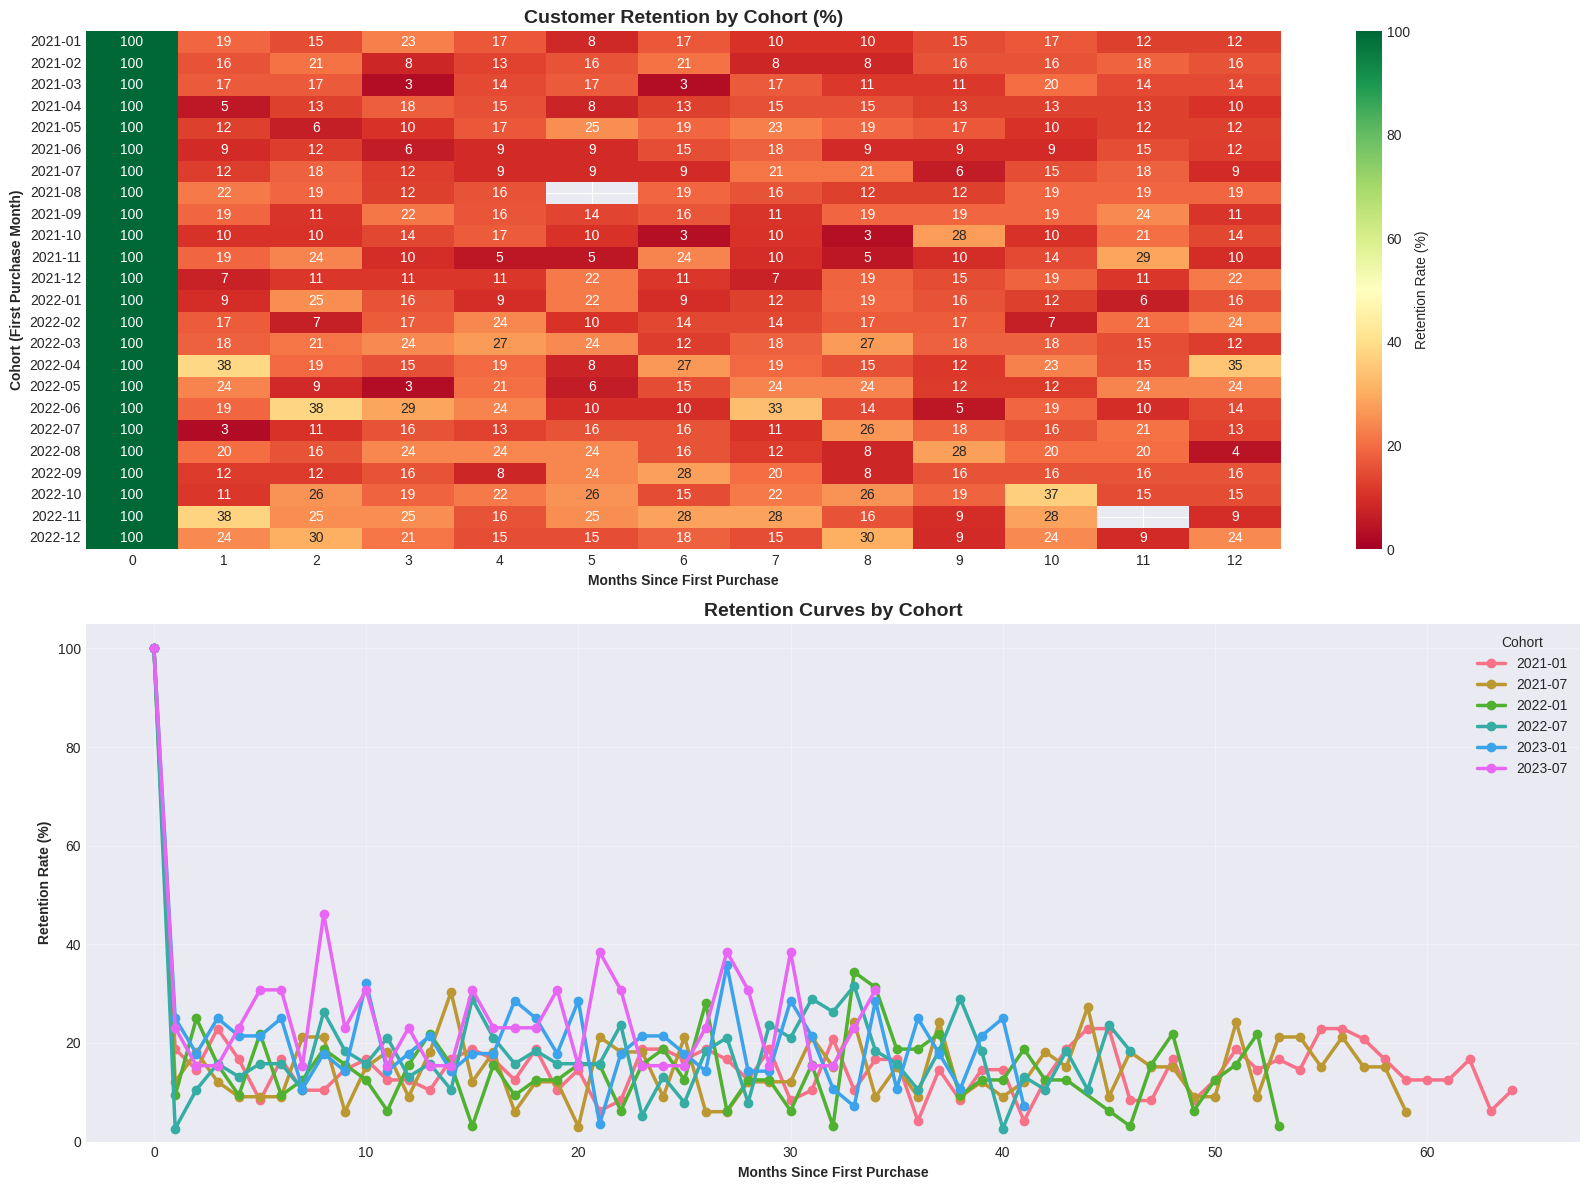


--------------------------------------------------------------------------------
5.3: REVENUE COHORT ANALYSIS
--------------------------------------------------------------------------------

Calculating revenue by cohort over time...

 Average Revenue per Customer by Cohort Month:

cohort_index     0      1      2      3      4      5      6
cohort_month                                                
2021-01      74.43 148.18 103.79  81.13  26.35  93.77  74.04
2021-02      84.65  13.98  97.44  32.35  55.76  74.96  75.64
2021-03      47.76 118.18  36.69  52.16  26.36 151.02 390.89
2021-04      68.07 441.20  35.57  44.51  38.16  56.41  40.93
2021-05      59.52  60.13  40.57  78.88  53.91  55.76  28.16
2021-06      62.74  41.35  91.18  51.08  27.27  48.65  93.63
2021-07      40.78  97.39  49.74  90.48  19.59  41.14  60.14
2021-08      61.87  62.77  67.10  96.39  25.05    NaN  29.74
2021-09      68.29  31.98 237.36  29.78 141.41  48.39  88.23
2021-10      69.65  88.43  22.18  58.78 108.

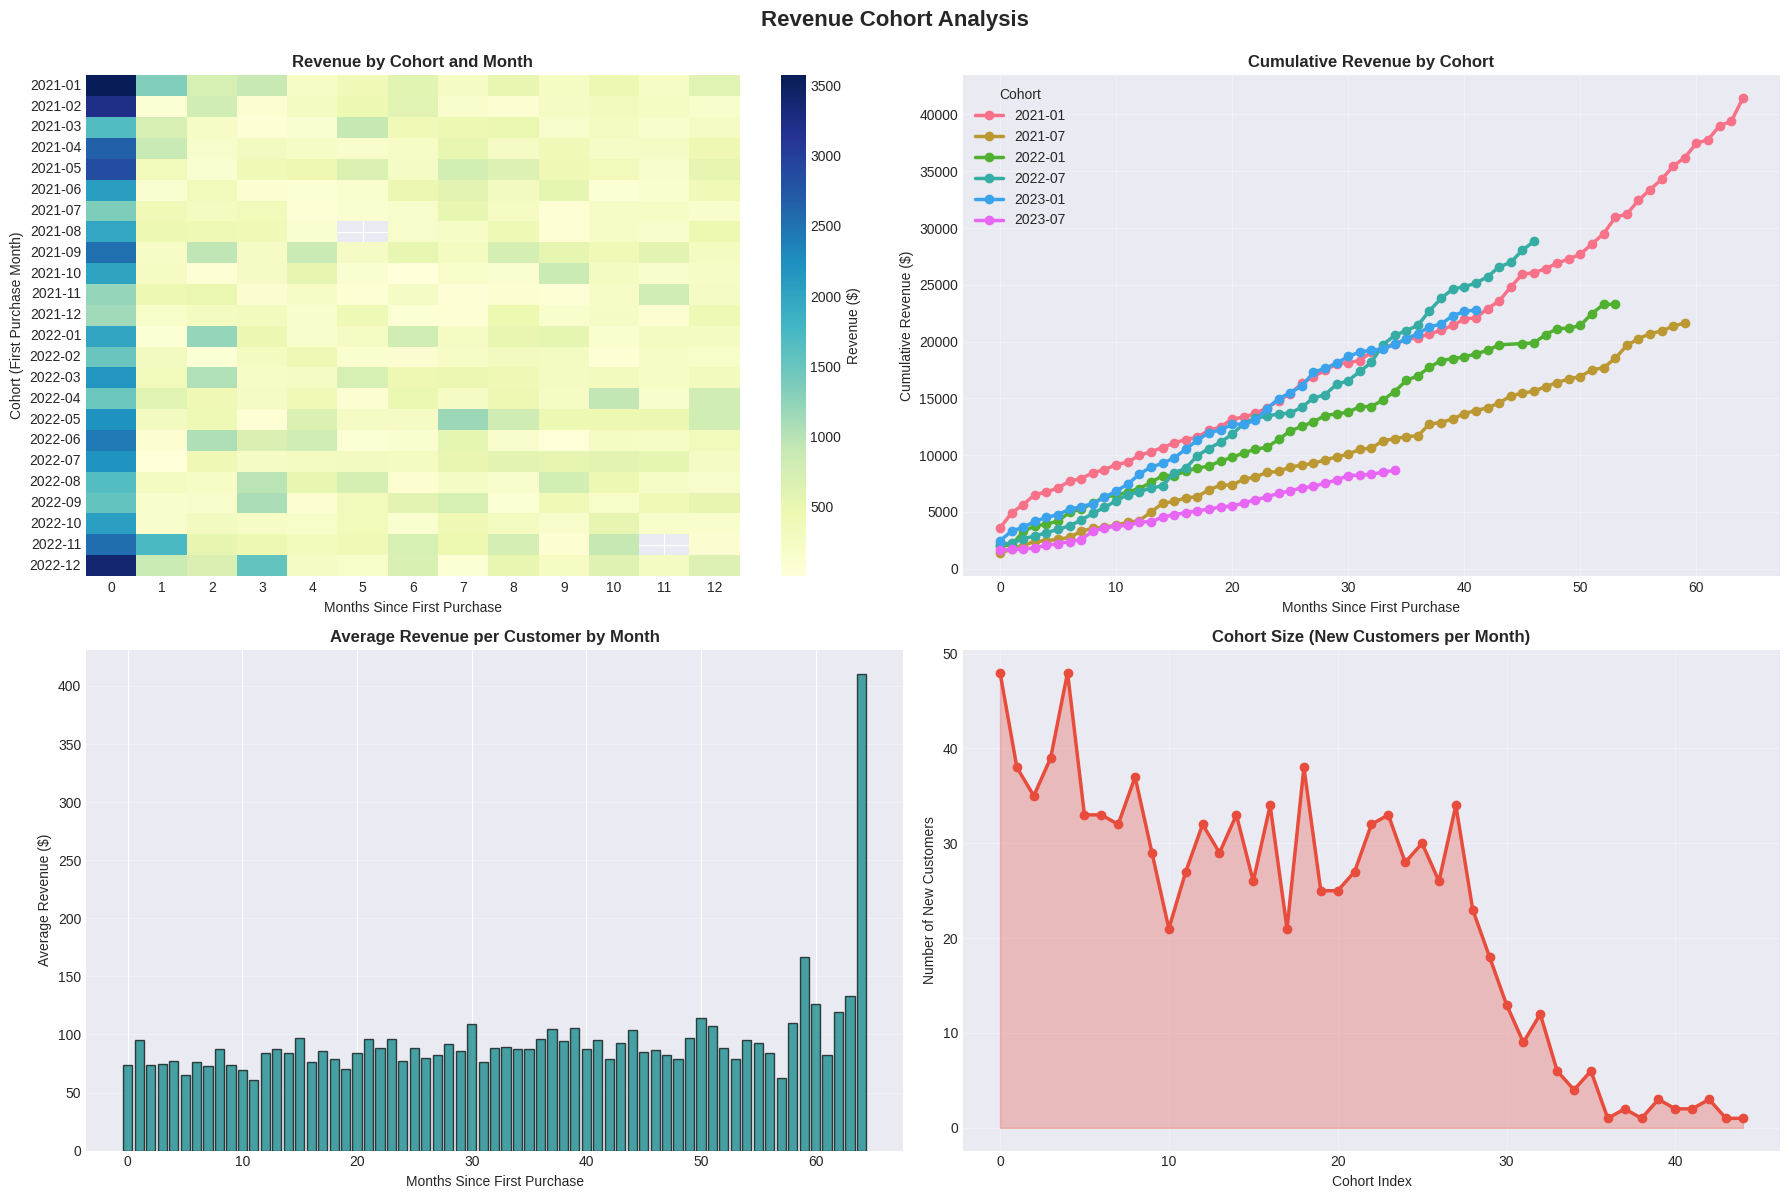


--------------------------------------------------------------------------------
5.4: RFM SEGMENTATION ANALYSIS
--------------------------------------------------------------------------------

RFM Analysis segments customers based on:
  • Recency: How recently did they transact?
  • Frequency: How often do they transact?
  • Monetary: How much do they spend?

This helps identify:
  • Champions (High R, F, M)
  • At-Risk (Low R, High F, M)
  • Lost Customers (Very Low R)
  • New Customers (High R, Low F)


 RFM Customer Segmentation:

                        Count  Avg_Recency  Avg_Frequency  Avg_Monetary  \
customer_segment                                                          
At Risk                    78        69.42          13.00       1377.58   
Loyal Customers            77        25.60          12.77       1030.25   
New Customers              69        13.03           7.51        697.41   
Champions                  29        12.03          13.79       1417.30   
Need Att

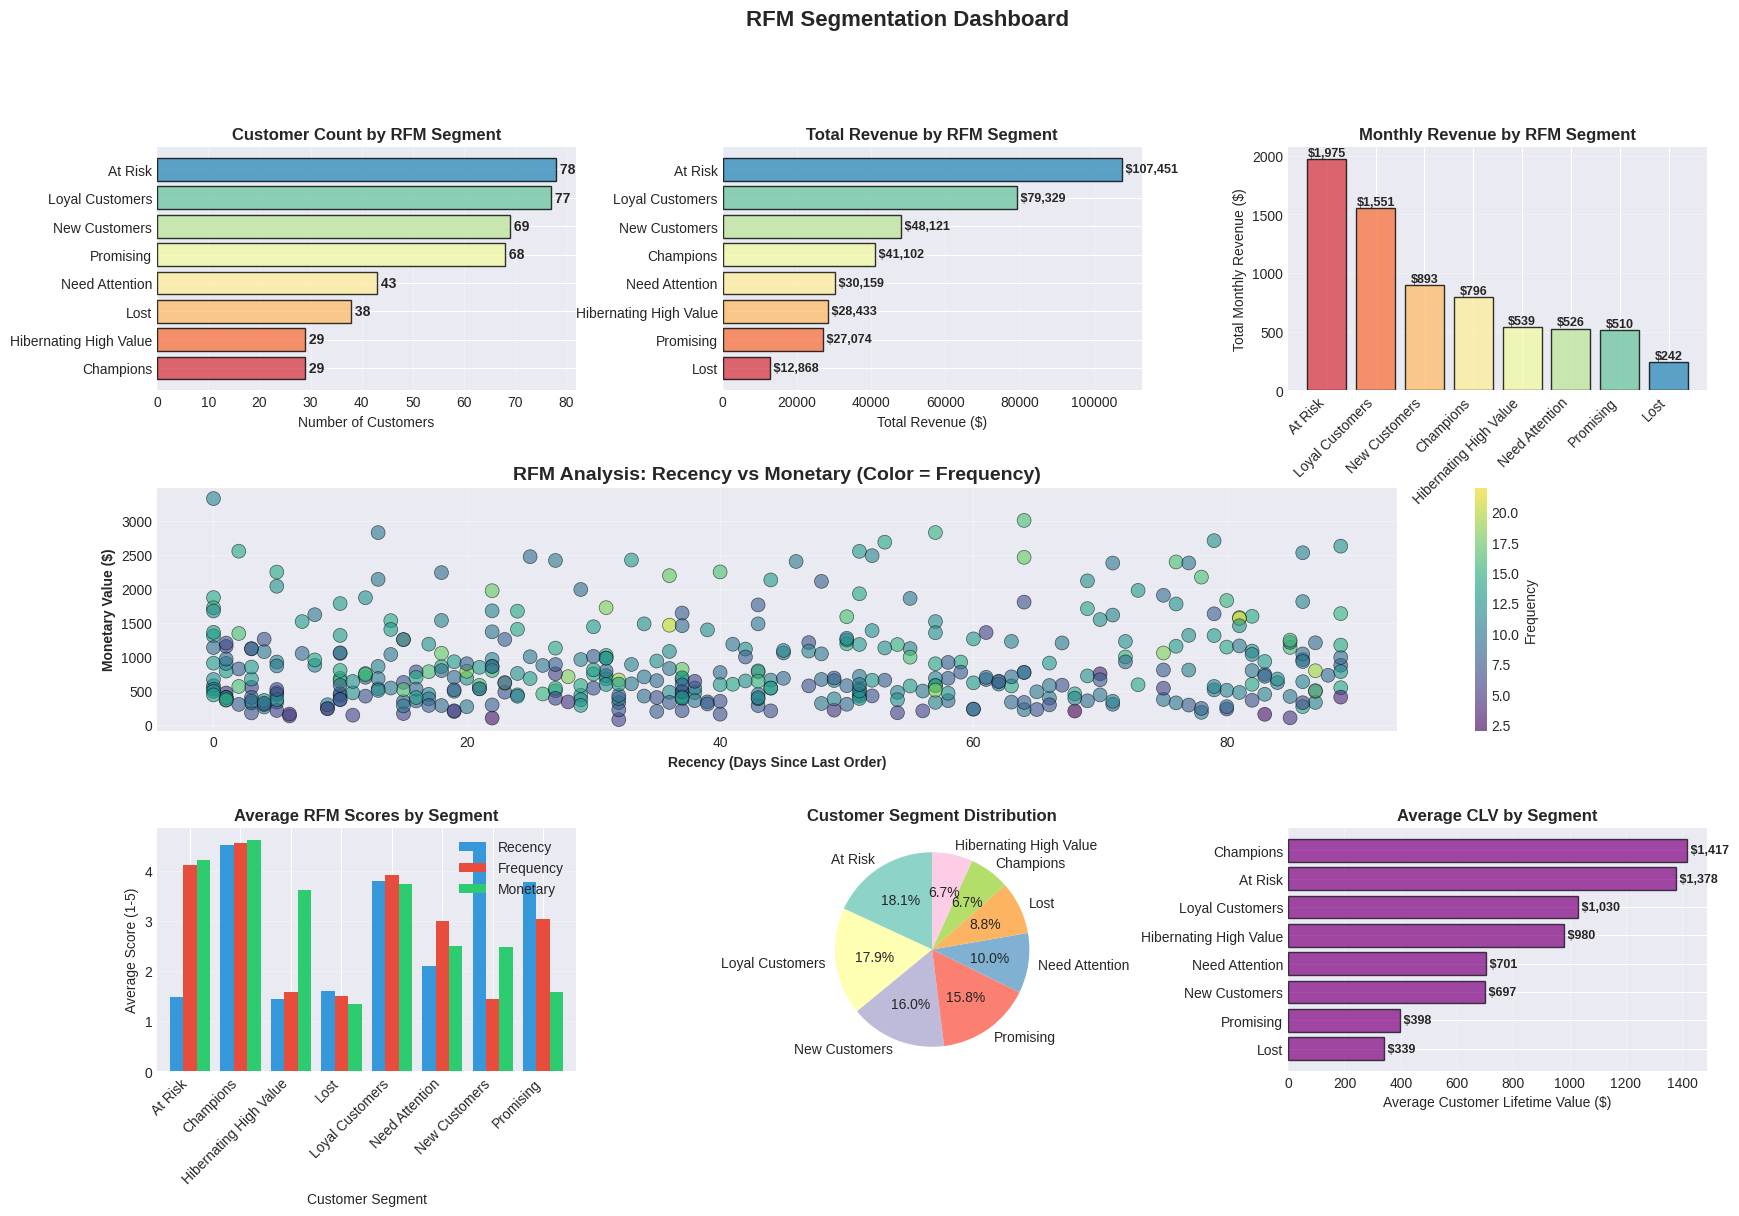


--------------------------------------------------------------------------------
5.5: CUSTOMER LIFETIME VALUE ANALYSIS
--------------------------------------------------------------------------------

Calculating comprehensive CLV metrics...

 CLV by Customer Segment:

                 Mean_CLV  Median_CLV  Std_CLV  Total_CLV  Customer_Count  \
CustomerSegment                                                             
Premium            964.69      912.22   426.93  297125.61             308   
Standard           486.81      430.22   267.27  291110.09             598   
VIP               1848.04     1868.24   567.49  173715.43              94   

                 Avg_Tenure_Months  
CustomerSegment                     
Premium                      58.56  
Standard                     57.15  
VIP                          57.49  

 CLV by Signup-Year Cohort:

             Mean_CLV  Median_CLV  Total_CLV  Customer_Count
cohort_year                                                 
2020  

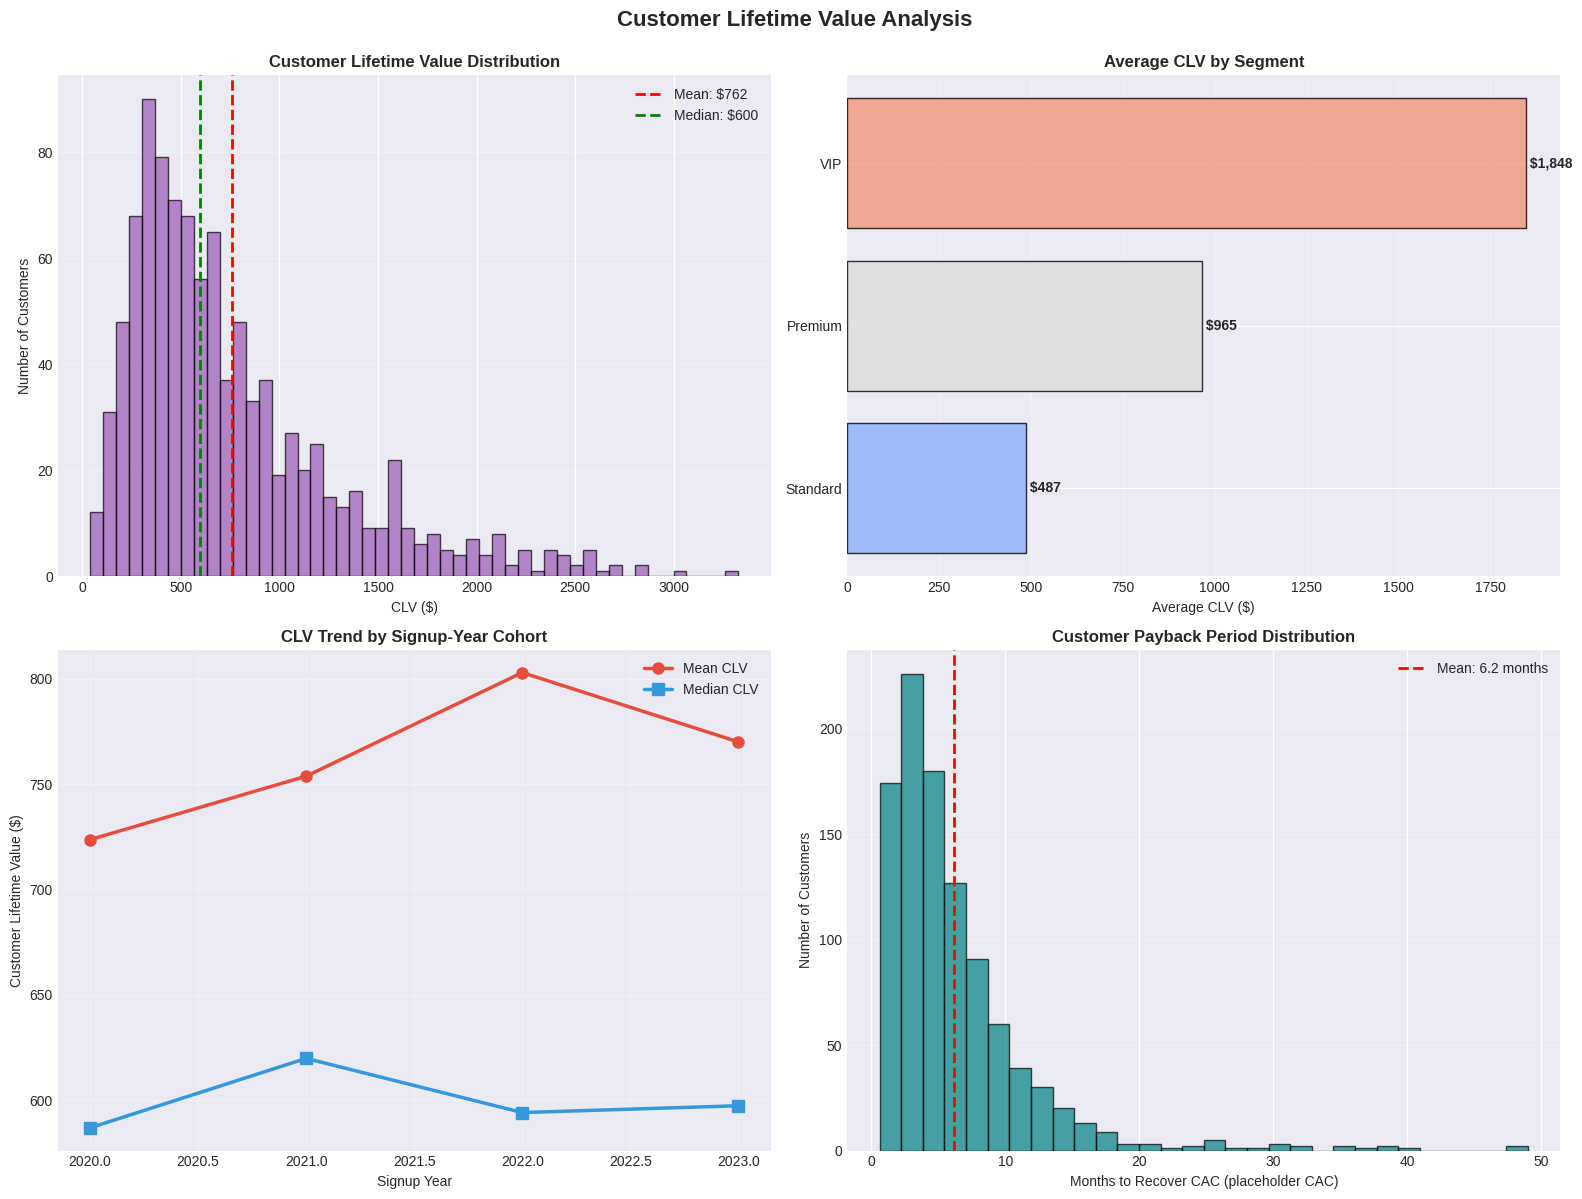


 Cohort & Retention Analysis Complete!



In [7]:
# ============================================================================
# SECTION 5: COHORT & RETENTION ANALYSIS
# (Rewritten for the retail dataset. Needs Section 0 and Section 2 run first;
#  Section 4 is NOT required — this section computes tenure/avg monthly
#  revenue itself if they don't already exist.)
# ============================================================================

print("\n" + "="*80)
print("SECTION 5: COHORT & RETENTION ANALYSIS")
print("="*80)

print("""
Cohort analysis helps us understand:
1. How different customer groups perform over time
2. Retention rates by acquisition period
3. Revenue patterns by cohort
4. Customer lifetime value trends

We'll analyze:
  • Monthly cohort retention
  • Revenue retention by cohort
  • Cohort lifetime value
  • RFM segmentation

NOTE: this dataset has no subscription MRR — "MRR" panels are replaced
with average monthly revenue per customer throughout.
""")

# Safety net: compute tenure / avg monthly revenue here if Section 4 wasn't run
if 'tenure_months' not in customers.columns:
    customers['SignUpDate'] = pd.to_datetime(customers['SignUpDate'])
    customers['tenure_months'] = ((ANALYSIS_DATE - customers['SignUpDate']).dt.days / 30).round().astype(int)

if 'avg_revenue_per_month' not in customers.columns:
    customers['avg_revenue_per_month'] = (
        customers['total_revenue'] / customers['tenure_months'].replace(0, np.nan)
    ).fillna(customers['total_revenue'])

# ========================================================================
# 5.1: COHORT RETENTION ANALYSIS
# ========================================================================

print("\n" + "-"*80)
print("5.1: COHORT RETENTION ANALYSIS")
print("-"*80)

print("\nCalculating monthly cohort retention rates...")

# Cohort = the month of each customer's FIRST order (first_order_date, built
# in Section 2). transaction_month = the month of each individual order.
cohort_data = transactions.merge(
    customers[['CustomerID', 'first_order_date']], on='CustomerID', how='left'
)
cohort_data['cohort_month'] = cohort_data['first_order_date'].dt.to_period('M').dt.to_timestamp()
cohort_data['transaction_month'] = cohort_data['OrderDate'].dt.to_period('M').dt.to_timestamp()

cohort_data['cohort_index'] = (
    (cohort_data['transaction_month'].dt.year - cohort_data['cohort_month'].dt.year) * 12
    + (cohort_data['transaction_month'].dt.month - cohort_data['cohort_month'].dt.month)
)

cohort_counts = cohort_data.groupby(['cohort_month', 'cohort_index'])['CustomerID'].nunique().reset_index()
cohort_counts.columns = ['cohort_month', 'cohort_index', 'customer_count']

retention_matrix = cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='customer_count')

cohort_size = retention_matrix.iloc[:, 0]
retention_pct = retention_matrix.divide(cohort_size, axis=0) * 100
retention_pct.index = retention_pct.index.strftime('%Y-%m')

print("\n Cohort Retention Matrix (%):\n")
print(retention_pct.iloc[:12, :13].round(1))

avg_retention = retention_pct.mean(axis=0)
print("\n Average Retention Rate by Month:\n")
for i in range(min(13, len(avg_retention))):
    print(f"   Month {i}: {avg_retention.iloc[i]:.1f}%")

# ========================================================================
# 5.2: COHORT RETENTION VISUALIZATION
# ========================================================================

print("\n" + "-"*80)
print("5.2: COHORT RETENTION VISUALIZATION")
print("-"*80)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

ax1 = axes[0]
sns.heatmap(retention_pct.iloc[:24, :13], annot=True, fmt='.0f', cmap='RdYlGn',
            ax=ax1, cbar_kws={'label': 'Retention Rate (%)'}, vmin=0, vmax=100)
ax1.set_title('Customer Retention by Cohort (%)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Months Since First Purchase', fontweight='bold')
ax1.set_ylabel('Cohort (First Purchase Month)', fontweight='bold')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

ax2 = axes[1]
cohorts_to_plot = retention_pct.index[::6][:6]
colors_cohorts = sns.color_palette("husl", len(cohorts_to_plot))

for idx, cohort in enumerate(cohorts_to_plot):
    cohort_data_plot = retention_pct.loc[cohort].dropna()
    ax2.plot(cohort_data_plot.index, cohort_data_plot.values,
             marker='o', linewidth=2.5, label=cohort, color=colors_cohorts[idx])

ax2.set_title('Retention Curves by Cohort', fontweight='bold', fontsize=14)
ax2.set_xlabel('Months Since First Purchase', fontweight='bold')
ax2.set_ylabel('Retention Rate (%)', fontweight='bold')
ax2.legend(title='Cohort', loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.savefig('financial_viz/11_cohort_retention.png', dpi=300, bbox_inches='tight')
print("\n Saved: financial_viz/11_cohort_retention.png")
plt.show()

# ========================================================================
# 5.3: REVENUE COHORT ANALYSIS
# ========================================================================

print("\n" + "-"*80)
print("5.3: REVENUE COHORT ANALYSIS")
print("-"*80)

print("\nCalculating revenue by cohort over time...")

cohort_revenue = cohort_data.groupby(['cohort_month', 'cohort_index'])['amount'].sum().reset_index()
revenue_matrix = cohort_revenue.pivot(index='cohort_month', columns='cohort_index', values='amount')
revenue_matrix.index = revenue_matrix.index.strftime('%Y-%m')

# retention_matrix still has Timestamp index -> align it to the same string index
retention_matrix_str = retention_matrix.copy()
retention_matrix_str.index = retention_matrix_str.index.strftime('%Y-%m')

avg_revenue_per_customer = revenue_matrix.divide(retention_matrix_str)

print("\n Average Revenue per Customer by Cohort Month:\n")
print(avg_revenue_per_customer.iloc[:12, :7].round(2))

cumulative_revenue = revenue_matrix.cumsum(axis=1)

print("\n Cumulative Revenue by Cohort (First 6 Cohorts, First 12 Months):\n")
print(cumulative_revenue.iloc[:6, :12].round(2))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax1 = axes[0, 0]
sns.heatmap(revenue_matrix.iloc[:24, :13], annot=False, cmap='YlGnBu',
            ax=ax1, cbar_kws={'label': 'Revenue ($)'}, fmt='.0f')
ax1.set_title('Revenue by Cohort and Month', fontweight='bold', fontsize=12)
ax1.set_xlabel('Months Since First Purchase')
ax1.set_ylabel('Cohort (First Purchase Month)')

ax2 = axes[0, 1]
for idx, cohort in enumerate(cohorts_to_plot):
    if cohort in cumulative_revenue.index:
        cohort_cumrev = cumulative_revenue.loc[cohort].dropna()
        ax2.plot(cohort_cumrev.index, cohort_cumrev.values,
                marker='o', linewidth=2.5, label=cohort, color=colors_cohorts[idx])

ax2.set_title('Cumulative Revenue by Cohort', fontweight='bold', fontsize=12)
ax2.set_xlabel('Months Since First Purchase')
ax2.set_ylabel('Cumulative Revenue ($)')
ax2.legend(title='Cohort', loc='upper left')
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
avg_rev_by_month = avg_revenue_per_customer.mean(axis=0).dropna()
ax3.bar(avg_rev_by_month.index, avg_rev_by_month.values,
        color='teal', alpha=0.7, edgecolor='black')
ax3.set_title('Average Revenue per Customer by Month', fontweight='bold', fontsize=12)
ax3.set_xlabel('Months Since First Purchase')
ax3.set_ylabel('Average Revenue ($)')
ax3.grid(axis='y', alpha=0.3)

ax4 = axes[1, 1]
cohort_sizes = retention_matrix.iloc[:, 0].sort_index()
ax4.plot(range(len(cohort_sizes)), cohort_sizes.values,
         marker='o', linewidth=2.5, color='#e74c3c')
ax4.fill_between(range(len(cohort_sizes)), cohort_sizes.values, alpha=0.3, color='#e74c3c')
ax4.set_title('Cohort Size (New Customers per Month)', fontweight='bold', fontsize=12)
ax4.set_xlabel('Cohort Index')
ax4.set_ylabel('Number of New Customers')
ax4.grid(True, alpha=0.3)

plt.suptitle('Revenue Cohort Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('financial_viz/12_revenue_cohorts.png', dpi=300, bbox_inches='tight')
print("\n Saved: financial_viz/12_revenue_cohorts.png")
plt.show()

# ========================================================================
# 5.4: RFM (RECENCY, FREQUENCY, MONETARY) ANALYSIS
# ========================================================================

print("\n" + "-"*80)
print("5.4: RFM SEGMENTATION ANALYSIS")
print("-"*80)

print("""
RFM Analysis segments customers based on:
  • Recency: How recently did they transact?
  • Frequency: How often do they transact?
  • Monetary: How much do they spend?

This helps identify:
  • Champions (High R, F, M)
  • At-Risk (Low R, High F, M)
  • Lost Customers (Very Low R)
  • New Customers (High R, Low F)
""")

rfm_data = customers[customers['is_churned'] == 0].copy()  # Only active customers

rfm_data['recency'] = rfm_data['days_since_last_order']
rfm_data['frequency'] = rfm_data['order_count']
rfm_data['monetary'] = rfm_data['total_revenue']

rfm_data['r_score'] = pd.qcut(rfm_data['recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')
rfm_data['f_score'] = pd.qcut(rfm_data['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm_data['m_score'] = pd.qcut(rfm_data['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

rfm_data['r_score'] = rfm_data['r_score'].astype(int)
rfm_data['f_score'] = rfm_data['f_score'].astype(int)
rfm_data['m_score'] = rfm_data['m_score'].astype(int)

rfm_data['rfm_score'] = (
    rfm_data['r_score'].astype(str) +
    rfm_data['f_score'].astype(str) +
    rfm_data['m_score'].astype(str)
)

def segment_customer(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Hibernating High Value'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    elif r >= 3 and m <= 2:
        return 'Promising'
    else:
        return 'Need Attention'

rfm_data['customer_segment'] = rfm_data.apply(segment_customer, axis=1)

rfm_summary = rfm_data.groupby('customer_segment').agg({
    'CustomerID': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'sum'],
    'avg_revenue_per_month': 'sum'
})
rfm_summary.columns = ['Count', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary',
                        'Total_Revenue', 'Total_Monthly_Revenue']
rfm_summary = rfm_summary.sort_values('Total_Revenue', ascending=False)

print("\n RFM Customer Segmentation:\n")
print(rfm_summary.round(2))

rfm_export = rfm_data[['CustomerID', 'CustomerSegment', 'Region', 'recency', 'frequency',
                       'monetary', 'r_score', 'f_score', 'm_score', 'customer_segment']]
rfm_export.to_csv('rfm_segmentation.csv', index=False)
print("\n Saved RFM segmentation to: 'rfm_segmentation.csv'")

fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
segment_counts = rfm_summary['Count'].sort_values(ascending=True)
colors_segments = sns.color_palette("Spectral", len(segment_counts))
ax1.barh(range(len(segment_counts)), segment_counts.values, color=colors_segments,
         alpha=0.8, edgecolor='black')
ax1.set_yticks(range(len(segment_counts)))
ax1.set_yticklabels(segment_counts.index)
ax1.set_title('Customer Count by RFM Segment', fontweight='bold', fontsize=12)
ax1.set_xlabel('Number of Customers')
for i, v in enumerate(segment_counts.values):
    ax1.text(v, i, f' {v:,}', va='center', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
revenue_by_segment = rfm_summary['Total_Revenue'].sort_values(ascending=True)
ax2.barh(range(len(revenue_by_segment)), revenue_by_segment.values,
         color=colors_segments, alpha=0.8, edgecolor='black')
ax2.set_yticks(range(len(revenue_by_segment)))
ax2.set_yticklabels(revenue_by_segment.index)
ax2.set_title('Total Revenue by RFM Segment', fontweight='bold', fontsize=12)
ax2.set_xlabel('Total Revenue ($)')
for i, v in enumerate(revenue_by_segment.values):
    ax2.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold', fontsize=9)
ax2.grid(axis='x', alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
mrr_by_segment = rfm_summary['Total_Monthly_Revenue'].sort_values(ascending=False)
ax3.bar(range(len(mrr_by_segment)), mrr_by_segment.values,
        color=colors_segments, alpha=0.8, edgecolor='black')
ax3.set_xticks(range(len(mrr_by_segment)))
ax3.set_xticklabels(mrr_by_segment.index, rotation=45, ha='right')
ax3.set_title('Monthly Revenue by RFM Segment', fontweight='bold', fontsize=12)
ax3.set_ylabel('Total Monthly Revenue ($)')
for i, v in enumerate(mrr_by_segment.values):
    ax3.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax3.grid(axis='y', alpha=0.3)

ax4 = fig.add_subplot(gs[1, :])
sc = ax4.scatter(rfm_data['recency'], rfm_data['monetary'],
           c=rfm_data['frequency'], cmap='viridis',
           s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
ax4.set_xlabel('Recency (Days Since Last Order)', fontweight='bold')
ax4.set_ylabel('Monetary Value ($)', fontweight='bold')
ax4.set_title('RFM Analysis: Recency vs Monetary (Color = Frequency)',
              fontweight='bold', fontsize=14)
plt.colorbar(sc, ax=ax4, label='Frequency')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[2, 0])
avg_scores = rfm_data.groupby('customer_segment')[['r_score', 'f_score', 'm_score']].mean()
avg_scores.plot(kind='bar', ax=ax5, width=0.8, color=['#3498db', '#e74c3c', '#2ecc71'])
ax5.set_title('Average RFM Scores by Segment', fontweight='bold', fontsize=12)
ax5.set_ylabel('Average Score (1-5)')
ax5.set_xlabel('Customer Segment')
ax5.legend(['Recency', 'Frequency', 'Monetary'], loc='upper right')
ax5.grid(axis='y', alpha=0.3)
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax6 = fig.add_subplot(gs[2, 1])
segment_pct = rfm_data['customer_segment'].value_counts()
ax6.pie(segment_pct.values, labels=segment_pct.index, autopct='%1.1f%%',
        colors=sns.color_palette("Set3", len(segment_pct)), startangle=90)
ax6.set_title('Customer Segment Distribution', fontweight='bold', fontsize=12)

ax7 = fig.add_subplot(gs[2, 2])
clv_by_segment_rfm = rfm_data.groupby('customer_segment')['monetary'].mean().sort_values(ascending=True)
ax7.barh(range(len(clv_by_segment_rfm)), clv_by_segment_rfm.values,
         color='purple', alpha=0.7, edgecolor='black')
ax7.set_yticks(range(len(clv_by_segment_rfm)))
ax7.set_yticklabels(clv_by_segment_rfm.index)
ax7.set_title('Average CLV by Segment', fontweight='bold', fontsize=12)
ax7.set_xlabel('Average Customer Lifetime Value ($)')
for i, v in enumerate(clv_by_segment_rfm.values):
    ax7.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold', fontsize=9)
ax7.grid(axis='x', alpha=0.3)

plt.suptitle('RFM Segmentation Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('financial_viz/13_rfm_analysis.png', dpi=300, bbox_inches='tight')
print("\n Saved: financial_viz/13_rfm_analysis.png")
plt.show()

# ========================================================================
# 5.5: CUSTOMER LIFETIME VALUE (CLV) DEEP DIVE
# ========================================================================

print("\n" + "-"*80)
print("5.5: CUSTOMER LIFETIME VALUE ANALYSIS")
print("-"*80)

print("\nCalculating comprehensive CLV metrics...")

clv_by_segment = customers.groupby('CustomerSegment').agg({
    'clv': ['mean', 'median', 'std', 'sum'],
    'CustomerID': 'count',
    'tenure_months': 'mean'
})
clv_by_segment.columns = ['Mean_CLV', 'Median_CLV', 'Std_CLV', 'Total_CLV',
                          'Customer_Count', 'Avg_Tenure_Months']

print("\n CLV by Customer Segment:\n")
print(clv_by_segment.round(2))

# Cohort here = signup year (closest analogue to the template's subscription
# cohort_month, since this dataset has no recurring "cohort_month" field)
customers['cohort_year'] = customers['SignUpDate'].dt.year
clv_by_cohort = customers.groupby('cohort_year').agg({
    'clv': ['mean', 'median', 'sum'],
    'CustomerID': 'count'
})
clv_by_cohort.columns = ['Mean_CLV', 'Median_CLV', 'Total_CLV', 'Customer_Count']

print("\n CLV by Signup-Year Cohort:\n")
print(clv_by_cohort.round(2))

# Payback period: CAC is not in this dataset — this is a placeholder
# assumption you should state explicitly in your writeup if you keep it.
assumed_cac = 50  # Placeholder Customer Acquisition Cost — adjust or justify
customers['payback_months'] = assumed_cac / customers['avg_revenue_per_month'].replace(0, np.nan)
avg_payback = customers['payback_months'].mean()

print(f"\n CLV Economics:")
print(f"   • Assumed CAC: ${assumed_cac}  (placeholder — no real CAC data in this dataset)")
print(f"   • Average CLV: ${customers['clv'].mean():,.2f}")
print(f"   • CLV to CAC Ratio: {customers['clv'].mean() / assumed_cac:.2f}x")
print(f"   • Average Payback Period: {avg_payback:.1f} months")
print(f"   • Median Payback Period: {customers['payback_months'].median():.1f} months")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
ax1.hist(customers['clv'], bins=50, color='#9b59b6', alpha=0.7, edgecolor='black')
ax1.axvline(customers['clv'].mean(), color='red', linestyle='--',
           linewidth=2, label=f'Mean: ${customers["clv"].mean():,.0f}')
ax1.axvline(customers['clv'].median(), color='green', linestyle='--',
           linewidth=2, label=f'Median: ${customers["clv"].median():,.0f}')
ax1.set_title('Customer Lifetime Value Distribution', fontweight='bold', fontsize=12)
ax1.set_xlabel('CLV ($)')
ax1.set_ylabel('Number of Customers')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
clv_segment_mean = customers.groupby('CustomerSegment')['clv'].mean().sort_values(ascending=True)
colors_clv = sns.color_palette("coolwarm", len(clv_segment_mean))
ax2.barh(range(len(clv_segment_mean)), clv_segment_mean.values,
         color=colors_clv, alpha=0.8, edgecolor='black')
ax2.set_yticks(range(len(clv_segment_mean)))
ax2.set_yticklabels(clv_segment_mean.index)
ax2.set_title('Average CLV by Segment', fontweight='bold', fontsize=12)
ax2.set_xlabel('Average CLV ($)')
for i, v in enumerate(clv_segment_mean.values):
    ax2.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

ax3 = axes[1, 0]
ax3.plot(clv_by_cohort.index, clv_by_cohort['Mean_CLV'],
        marker='o', linewidth=2.5, markersize=8, color='#e74c3c', label='Mean CLV')
ax3.plot(clv_by_cohort.index, clv_by_cohort['Median_CLV'],
        marker='s', linewidth=2.5, markersize=8, color='#3498db', label='Median CLV')
ax3.set_title('CLV Trend by Signup-Year Cohort', fontweight='bold', fontsize=12)
ax3.set_xlabel('Signup Year')
ax3.set_ylabel('Customer Lifetime Value ($)')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
payback_data = customers[customers['payback_months'] < 50]['payback_months']
ax4.hist(payback_data, bins=30, color='teal', alpha=0.7, edgecolor='black')
ax4.axvline(payback_data.mean(), color='red', linestyle='--',
           linewidth=2, label=f'Mean: {payback_data.mean():.1f} months')
ax4.set_title('Customer Payback Period Distribution', fontweight='bold', fontsize=12)
ax4.set_xlabel('Months to Recover CAC (placeholder CAC)')
ax4.set_ylabel('Number of Customers')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.suptitle('Customer Lifetime Value Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('financial_viz/14_clv_analysis.png', dpi=300, bbox_inches='tight')
print("\n Saved: financial_viz/14_clv_analysis.png")
plt.show()

print("\n Cohort & Retention Analysis Complete!")
print("="*80 + "\n")


SECTION 6: PROFITABILITY & CUSTOMER SEGMENTATION

Advanced profitability analysis includes:
1. Customer segment profitability (using REAL profit, not an assumed margin)
2. Product category mix & pricing analysis
3. Geographic profitability
4. K-Means clustering for data-driven segments

NOTE: unlike the original template, this dataset has real per-line-item
cost (UnitCost) and profit, so segment profitability below uses ACTUAL
margins instead of an assumed 70% flat margin. There is also no
subscription "plan" here — that section is replaced with product
CATEGORY mix, since this is a retail business with product categories
rather than pricing tiers.


--------------------------------------------------------------------------------
6.1: CUSTOMER SEGMENT PROFITABILITY
--------------------------------------------------------------------------------

 Profitability by Customer Segment:

                 Customer_Count  Total_Monthly_Revenue  Total_Revenue  \
CustomerSegment                

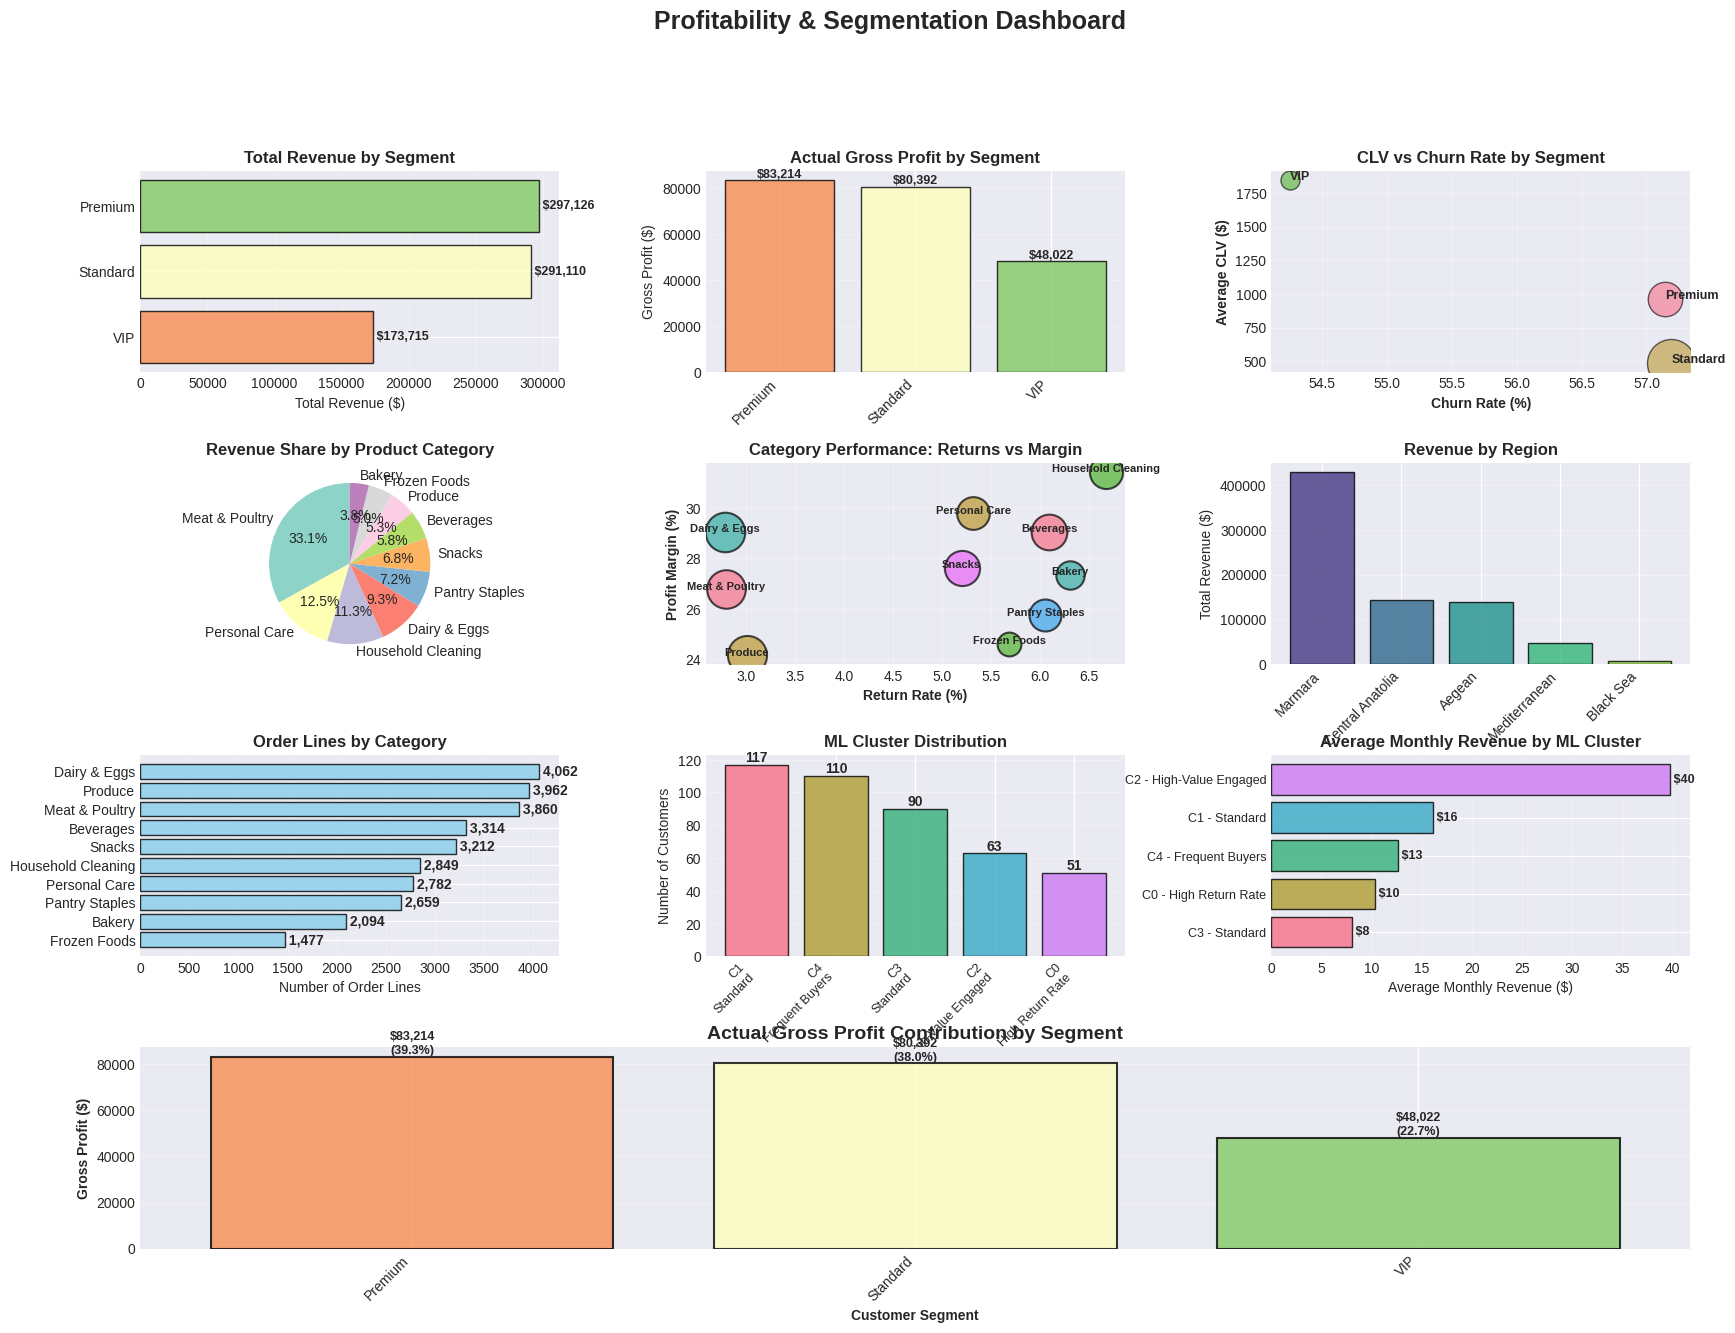


 Profitability Analysis Complete!



In [8]:
# ============================================================================
# SECTION 6: ADVANCED PROFITABILITY ANALYSIS
# (Rewritten for the retail dataset. Needs Section 0 and Section 2 run first;
#  Sections 4/5 not required — tenure/avg monthly revenue are computed here
#  if they don't already exist.)
# ============================================================================

print("\n" + "="*80)
print("SECTION 6: PROFITABILITY & CUSTOMER SEGMENTATION")
print("="*80)

print("""
Advanced profitability analysis includes:
1. Customer segment profitability (using REAL profit, not an assumed margin)
2. Product category mix & pricing analysis
3. Geographic profitability
4. K-Means clustering for data-driven segments

NOTE: unlike the original template, this dataset has real per-line-item
cost (UnitCost) and profit, so segment profitability below uses ACTUAL
margins instead of an assumed 70% flat margin. There is also no
subscription "plan" here — that section is replaced with product
CATEGORY mix, since this is a retail business with product categories
rather than pricing tiers.
""")

if 'tenure_months' not in customers.columns:
    customers['SignUpDate'] = pd.to_datetime(customers['SignUpDate'])
    customers['tenure_months'] = ((ANALYSIS_DATE - customers['SignUpDate']).dt.days / 30).round().astype(int)

if 'avg_revenue_per_month' not in customers.columns:
    customers['avg_revenue_per_month'] = (
        customers['total_revenue'] / customers['tenure_months'].replace(0, np.nan)
    ).fillna(customers['total_revenue'])

if 'avg_order_value' not in customers.columns:
    customers['avg_order_value'] = customers['total_revenue'] / customers['order_count'].replace(0, np.nan)

if 'return_rate' not in customers.columns:
    return_rate_by_cust = transactions.groupby('CustomerID')['IsReturned'].mean().rename('return_rate')
    customers = customers.merge(return_rate_by_cust, on='CustomerID', how='left')
    customers['return_rate'] = customers['return_rate'].fillna(0)

# ========================================================================
# 6.1: SEGMENT PROFITABILITY ANALYSIS
# ========================================================================

print("\n" + "-"*80)
print("6.1: CUSTOMER SEGMENT PROFITABILITY")
print("-"*80)

profitability = customers.groupby('CustomerSegment').agg({
    'CustomerID': 'count',
    'avg_revenue_per_month': 'sum',
    'total_revenue': ['sum', 'mean'],
    'total_profit': 'sum',
    'clv': ['mean', 'sum'],
    'tenure_months': 'mean',
    'is_churned': ['sum', 'mean']
})

profitability.columns = ['Customer_Count', 'Total_Monthly_Revenue', 'Total_Revenue',
                        'Avg_Revenue', 'Gross_Profit', 'Avg_CLV', 'Total_CLV',
                        'Avg_Tenure_Months', 'Churned_Count', 'Churn_Rate']

profitability['Churn_Rate'] = profitability['Churn_Rate'] * 100
profitability['Revenue_per_Customer_Month'] = (
    profitability['Total_Monthly_Revenue'] / profitability['Customer_Count']
)
# REAL margin, computed from actual cost/revenue data — not assumed
profitability['Profit_Margin_%'] = profitability['Gross_Profit'] / profitability['Total_Revenue'] * 100

print("\n Profitability by Customer Segment:\n")
print(profitability.round(2))

total_profit = profitability['Gross_Profit'].sum()
print("\n Profitability Summary:")
print(f"   • Total Gross Profit (actual): ${total_profit:,.2f}")
print(f"   • Most Profitable Segment: {profitability['Gross_Profit'].idxmax()}")
print(f"   • Highest CLV Segment: {profitability['Avg_CLV'].idxmax()}")
print(f"   • Overall Margin: {profitability['Gross_Profit'].sum() / profitability['Total_Revenue'].sum() * 100:.1f}%")

# ========================================================================
# 6.2: CATEGORY MIX & PRICING ANALYSIS
# (Replaces the template's "Plan Mix" — this is a retail business with
#  product categories, not subscription tiers.)
# ========================================================================

print("\n" + "-"*80)
print("6.2: PRODUCT CATEGORY MIX & PRICING ANALYSIS")
print("-"*80)

# Correctly load categories_raw for this section as it was incorrectly loaded elsewhere.
categories_raw = pd.read_csv("/content/drive/MyDrive/files for python/categories.csv")

category_txn = transactions.merge(products_raw[['ProductID', 'CategoryID']], on='ProductID', how='left')
category_txn = category_txn.merge(categories_raw[['CategoryID', 'CategoryName']], on='CategoryID', how='left')

category_analysis = category_txn.groupby('CategoryName').agg(
    Order_Line_Count=('OrderID', 'count'),
    Total_Revenue=('amount', 'sum'),
    Total_Profit=('profit', 'sum'),
    Avg_Order_Value=('amount', 'mean'),
    Return_Rate=('IsReturned', 'mean'),
)
category_analysis['Profit_Margin_%'] = category_analysis['Total_Profit'] / category_analysis['Total_Revenue'] * 100
category_analysis['Return_Rate'] = category_analysis['Return_Rate'] * 100
category_analysis['Revenue_Share_%'] = (
    category_analysis['Total_Revenue'] / category_analysis['Total_Revenue'].sum() * 100
)
category_analysis = category_analysis.sort_values('Total_Revenue', ascending=False)

print("\n Product Category Performance:\n")
print(category_analysis.round(2))

# ========================================================================
# 6.3: GEOGRAPHIC PROFITABILITY
# (Template used 'country' — this dataset has 'Region' instead.)
# ========================================================================

print("\n" + "-"*80)
print("6.3: GEOGRAPHIC PROFITABILITY ANALYSIS")
print("-"*80)

geo_analysis = customers.groupby('Region').agg({
    'CustomerID': 'count',
    'avg_revenue_per_month': 'sum',
    'total_revenue': 'sum',
    'total_profit': 'sum',
    'clv': 'mean',
    'is_churned': 'mean'
})

geo_analysis.columns = ['Customer_Count', 'Total_Monthly_Revenue', 'Total_Revenue',
                       'Total_Profit', 'Avg_CLV', 'Churn_Rate']
geo_analysis['Churn_Rate'] = geo_analysis['Churn_Rate'] * 100
geo_analysis = geo_analysis.sort_values('Total_Revenue', ascending=True)

print("\n Geographic Performance:\n")
print(geo_analysis.round(2))

# ========================================================================
# 6.4: K-MEANS CUSTOMER CLUSTERING
# ========================================================================

print("\n" + "-"*80)
print("6.4: DATA-DRIVEN CUSTOMER SEGMENTATION (K-Means)")
print("-"*80)

print("\nPerforming K-Means clustering on customer features...")

# Retail-appropriate feature set (no subscription usage/NPS/tickets exist here)
clustering_features = ['avg_revenue_per_month', 'tenure_months', 'usage_score',
                      'avg_order_value', 'return_rate', 'days_since_last_order']

cluster_data = customers[customers['is_churned'] == 0][clustering_features].copy()
cluster_data = cluster_data.fillna(cluster_data.median())

scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_data)

inertias = []
K_range = range(2, 11)

print("\nTesting different numbers of clusters...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)

optimal_k = 5
print(f"\nUsing K={optimal_k} clusters for segmentation")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(cluster_scaled)

customers.loc[customers['is_churned'] == 0, 'ml_cluster'] = cluster_labels

cluster_analysis = customers[customers['is_churned'] == 0].groupby('ml_cluster').agg({
    'CustomerID': 'count',
    'avg_revenue_per_month': ['mean', 'sum'],
    'clv': 'mean',
    'tenure_months': 'mean',
    'usage_score': 'mean',
    'avg_order_value': 'mean',
    'return_rate': 'mean',
    'days_since_last_order': 'mean'
})

cluster_analysis.columns = ['Count', 'Avg_Monthly_Revenue', 'Total_Monthly_Revenue', 'Avg_CLV',
                           'Avg_Tenure_Months', 'Avg_Orders', 'Avg_Order_Value',
                           'Avg_Return_Rate', 'Avg_Recency_Days']

print("\n Machine Learning Customer Clusters:\n")
print(cluster_analysis.round(2))

def name_cluster(row):
    if row['Avg_Monthly_Revenue'] > cluster_analysis['Avg_Monthly_Revenue'].mean() * 1.5:
        if row['Avg_Orders'] > cluster_analysis['Avg_Orders'].mean():
            return 'High-Value Engaged'
        else:
            return 'High-Value At-Risk'
    elif row['Avg_Orders'] > cluster_analysis['Avg_Orders'].mean() * 1.2:
        return 'Frequent Buyers'
    elif row['Avg_Return_Rate'] > cluster_analysis['Avg_Return_Rate'].mean() * 1.5:
        return 'High Return Rate'
    else:
        return 'Standard'

cluster_names = cluster_analysis.apply(name_cluster, axis=1)
print("\n Cluster Names:")
for i, name in cluster_names.items():
    print(f"   Cluster {int(i)}: {name}")

# ========================================================================
# 6.5: PROFITABILITY VISUALIZATIONS
# ========================================================================

print("\n" + "-"*80)
print("6.5: PROFITABILITY VISUALIZATIONS")
print("-"*80)

fig = plt.figure(figsize=(20, 14))
gs = GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Revenue by Segment
ax1 = fig.add_subplot(gs[0, 0])
profitability_sorted = profitability.sort_values('Total_Revenue', ascending=True)
colors_prof = sns.color_palette("RdYlGn", len(profitability_sorted))
ax1.barh(range(len(profitability_sorted)), profitability_sorted['Total_Revenue'],
         color=colors_prof, alpha=0.8, edgecolor='black')
ax1.set_yticks(range(len(profitability_sorted)))
ax1.set_yticklabels(profitability_sorted.index)
ax1.set_title('Total Revenue by Segment', fontweight='bold', fontsize=12)
ax1.set_xlabel('Total Revenue ($)')
for i, v in enumerate(profitability_sorted['Total_Revenue']):
    ax1.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold', fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# 2. Gross Profit by Segment (real profit, replaces "MRR by Segment")
ax2 = fig.add_subplot(gs[0, 1])
profit_sorted = profitability.sort_values('Gross_Profit', ascending=False)
ax2.bar(range(len(profit_sorted)), profit_sorted['Gross_Profit'],
        color=colors_prof, alpha=0.8, edgecolor='black')
ax2.set_xticks(range(len(profit_sorted)))
ax2.set_xticklabels(profit_sorted.index, rotation=45, ha='right')
ax2.set_title('Actual Gross Profit by Segment', fontweight='bold', fontsize=12)
ax2.set_ylabel('Gross Profit ($)')
for i, v in enumerate(profit_sorted['Gross_Profit']):
    ax2.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# 3. CLV vs Churn Rate by Segment
ax3 = fig.add_subplot(gs[0, 2])
for segment in profitability.index:
    clv = profitability.loc[segment, 'Avg_CLV']
    churn = profitability.loc[segment, 'Churn_Rate']
    count = profitability.loc[segment, 'Customer_Count']
    ax3.scatter(churn, clv, s=count*2, alpha=0.6, label=segment, edgecolors='black', linewidth=1)
    ax3.annotate(segment, (churn, clv), fontsize=9, fontweight='bold')
ax3.set_xlabel('Churn Rate (%)', fontweight='bold')
ax3.set_ylabel('Average CLV ($)', fontweight='bold')
ax3.set_title('CLV vs Churn Rate by Segment', fontweight='bold', fontsize=12)
ax3.grid(True, alpha=0.3)

# 4. Category Mix (Revenue Share) — replaces "Plan Mix"
ax4 = fig.add_subplot(gs[1, 0])
cat_revenue_share = category_analysis['Revenue_Share_%'].sort_values(ascending=False)
colors_cat = sns.color_palette("Set3", len(cat_revenue_share))
ax4.pie(cat_revenue_share.values, labels=cat_revenue_share.index, autopct='%1.1f%%',
        colors=colors_cat, startangle=90)
ax4.set_title('Revenue Share by Product Category', fontweight='bold', fontsize=12)

# 5. Category Performance Matrix (replaces "Plan Performance")
ax5 = fig.add_subplot(gs[1, 1])
for cat in category_analysis.index:
    x = category_analysis.loc[cat, 'Return_Rate']
    y = category_analysis.loc[cat, 'Profit_Margin_%']
    count = category_analysis.loc[cat, 'Order_Line_Count']
    ax5.scatter(x, y, s=count/5, alpha=0.7, edgecolors='black', linewidth=1.5)
    ax5.annotate(cat, (x, y), fontsize=8, fontweight='bold', ha='center')
ax5.set_xlabel('Return Rate (%)', fontweight='bold')
ax5.set_ylabel('Profit Margin (%)', fontweight='bold')
ax5.set_title('Category Performance: Returns vs Margin', fontweight='bold', fontsize=12)
ax5.grid(True, alpha=0.3)

# 6. Geographic Revenue Distribution
ax6 = fig.add_subplot(gs[1, 2])
geo_top = geo_analysis.nlargest(8, 'Total_Revenue')
colors_geo = sns.color_palette("viridis", len(geo_top))
ax6.bar(range(len(geo_top)), geo_top['Total_Revenue'],
        color=colors_geo, alpha=0.8, edgecolor='black')
ax6.set_xticks(range(len(geo_top)))
ax6.set_xticklabels(geo_top.index, rotation=45, ha='right')
ax6.set_title('Revenue by Region', fontweight='bold', fontsize=12)
ax6.set_ylabel('Total Revenue ($)')
ax6.grid(axis='y', alpha=0.3)

# 7. Order Line Count by Category (replaces "Customer Count by Plan")
ax7 = fig.add_subplot(gs[2, 0])
cat_counts = category_analysis.sort_values('Order_Line_Count', ascending=True)
ax7.barh(range(len(cat_counts)), cat_counts['Order_Line_Count'],
         color='skyblue', alpha=0.8, edgecolor='black')
ax7.set_yticks(range(len(cat_counts)))
ax7.set_yticklabels(cat_counts.index)
ax7.set_title('Order Lines by Category', fontweight='bold', fontsize=12)
ax7.set_xlabel('Number of Order Lines')
for i, v in enumerate(cat_counts['Order_Line_Count']):
    ax7.text(v, i, f' {v:,}', va='center', fontweight='bold')
ax7.grid(axis='x', alpha=0.3)

# 8. K-Means Clusters
ax8 = fig.add_subplot(gs[2, 1])
cluster_counts = cluster_analysis['Count'].sort_values(ascending=False)
colors_cluster = sns.color_palette("husl", len(cluster_counts))
ax8.bar(range(len(cluster_counts)), cluster_counts.values,
        color=colors_cluster, alpha=0.8, edgecolor='black')
ax8.set_xticks(range(len(cluster_counts)))
ax8.set_xticklabels([f'C{int(i)}\n{cluster_names[i]}' for i in cluster_counts.index],
                     rotation=45, ha='right', fontsize=9)
ax8.set_title('ML Cluster Distribution', fontweight='bold', fontsize=12)
ax8.set_ylabel('Number of Customers')
for i, v in enumerate(cluster_counts.values):
    ax8.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
ax8.grid(axis='y', alpha=0.3)

# 9. Cluster Monthly Revenue Comparison
ax9 = fig.add_subplot(gs[2, 2])
cluster_rev = cluster_analysis.sort_values('Avg_Monthly_Revenue', ascending=True)
ax9.barh(range(len(cluster_rev)), cluster_rev['Avg_Monthly_Revenue'],
         color=colors_cluster, alpha=0.8, edgecolor='black')
ax9.set_yticks(range(len(cluster_rev)))
ax9.set_yticklabels([f'C{int(i)} - {cluster_names[i]}' for i in cluster_rev.index], fontsize=9)
ax9.set_title('Average Monthly Revenue by ML Cluster', fontweight='bold', fontsize=12)
ax9.set_xlabel('Average Monthly Revenue ($)')
for i, v in enumerate(cluster_rev['Avg_Monthly_Revenue']):
    ax9.text(v, i, f' ${v:.0f}', va='center', fontweight='bold', fontsize=9)
ax9.grid(axis='x', alpha=0.3)

# 10. Profit Contribution by Segment (real profit, not assumed)
ax10 = fig.add_subplot(gs[3, :])
segments_profit = profitability.sort_values('Gross_Profit', ascending=False)
bar_positions = list(range(len(segments_profit)))
bar_heights = segments_profit['Gross_Profit'].values
bar_colors = sns.color_palette("RdYlGn", len(segments_profit))

bars = ax10.bar(bar_positions, bar_heights, color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax10.set_xticks(bar_positions)
ax10.set_xticklabels(segments_profit.index, rotation=45, ha='right')
ax10.set_title('Actual Gross Profit Contribution by Segment', fontweight='bold', fontsize=14)
ax10.set_ylabel('Gross Profit ($)', fontweight='bold')
ax10.set_xlabel('Customer Segment', fontweight='bold')

for bar, value in zip(bars, bar_heights):
    height = bar.get_height()
    ax10.text(bar.get_x() + bar.get_width()/2., height,
             f'${value:,.0f}\n({value/total_profit*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

ax10.grid(axis='y', alpha=0.3)

plt.suptitle('Profitability & Segmentation Dashboard', fontsize=18, fontweight='bold', y=0.995)
plt.savefig('financial_viz/15_profitability_dashboard.png', dpi=300, bbox_inches='tight')
print("\n Saved: financial_viz/15_profitability_dashboard.png")
plt.show()

print("\n Profitability Analysis Complete!")
print("="*80 + "\n")

In [9]:
# ============================================================================
# SECTION 7: EXECUTIVE DASHBOARD & REPORTING
# (Rewritten for the retail dataset. This section pulls together variables
#  from earlier sections — run Section 0, 2, 3 (forecast, mape), and 4
#  (at_risk, at_risk_monthly_revenue) first. Section 5's payback_months is
#  optional — a fallback is computed here if you skipped it.)
# ============================================================================

print("\n" + "="*80)
print("SECTION 7: EXECUTIVE DASHBOARD & COMPREHENSIVE REPORTING")
print("="*80)

print("\nCreating final executive summary...")

# ========================================================================
# 7.1: KEY METRICS SUMMARY
# ========================================================================

print("\n" + "-"*80)
print("7.1: KEY PERFORMANCE INDICATORS (KPIs)")
print("-"*80)

if 'tenure_months' not in customers.columns:
    customers['SignUpDate'] = pd.to_datetime(customers['SignUpDate'])
    customers['tenure_months'] = ((ANALYSIS_DATE - customers['SignUpDate']).dt.days / 30).round().astype(int)

if 'avg_revenue_per_month' not in customers.columns:
    customers['avg_revenue_per_month'] = (
        customers['total_revenue'] / customers['tenure_months'].replace(0, np.nan)
    ).fillna(customers['total_revenue'])

# Placeholder CAC — same assumption used in Section 5. No real acquisition
# cost data exists in this dataset; state this assumption explicitly in
# your writeup if you keep this metric.
ASSUMED_CAC = 50
if 'payback_months' not in customers.columns:
    customers['payback_months'] = ASSUMED_CAC / customers['avg_revenue_per_month'].replace(0, np.nan)

total_customers_current = len(customers)
active_customers_current = (customers['is_churned'] == 0).sum()
total_monthly_revenue_current = customers[customers['is_churned'] == 0]['avg_revenue_per_month'].sum()
total_annualized_revenue = total_monthly_revenue_current * 12
avg_revenue_per_account = customers['total_revenue'].mean()
total_revenue_all_time = transactions['amount'].sum()

# Revenue growth: exclude the final partial month (same logic as Section 3)
last_month_start = ANALYSIS_DATE.to_period('M').to_timestamp()
last_month_is_partial = ANALYSIS_DATE != (ANALYSIS_DATE + pd.offsets.MonthEnd(0))
mr_clean = monthly_revenue[monthly_revenue['year_month'] < last_month_start] if last_month_is_partial else monthly_revenue

recent_months = mr_clean.tail(6)
previous_months = mr_clean.tail(12).head(6)
revenue_growth_rate = (
    (recent_months['total_revenue'].mean() - previous_months['total_revenue'].mean())
    / previous_months['total_revenue'].mean() * 100
)

avg_clv_current = customers['clv'].mean()
median_clv_current = customers['clv'].median()
churn_rate_current = (customers['is_churned'].sum() / len(customers)) * 100

kpi_summary = f"""
╔══════════════════════════════════════════════════════════════════════════╗
║                     KEY PERFORMANCE INDICATORS                            ║
╚══════════════════════════════════════════════════════════════════════════╝

REVENUE METRICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Total All-Time Revenue          : ${total_revenue_all_time:,.2f}
  • Current Monthly Revenue Run-Rate: ${total_monthly_revenue_current:,.2f}
  • Annualized Revenue Run-Rate     : ${total_annualized_revenue:,.2f}
  • Average Revenue per Customer    : ${avg_revenue_per_account:,.2f}
  • Revenue Growth Rate (6mo)       : {revenue_growth_rate:+.2f}%

CUSTOMER METRICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Total Customers                 : {total_customers_current:,}
  • Active Customers                : {active_customers_current:,}
  • Churned Customers               : {total_customers_current - active_customers_current:,}
  • Overall Churn Rate              : {churn_rate_current:.2f}%  (>{CHURN_THRESHOLD_DAYS}d inactive)
  • Average Customer Tenure         : {customers['tenure_months'].mean():.1f} months

CUSTOMER VALUE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Average CLV                     : ${avg_clv_current:,.2f}
  • Median CLV                      : ${median_clv_current:,.2f}
  • CLV to CAC Ratio                : {avg_clv_current / ASSUMED_CAC:.2f}x  (assumed CAC: ${ASSUMED_CAC} — placeholder, not measured)
  • Average Payback Period          : {customers['payback_months'].mean():.1f} months

FORECASTING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Forecasted Revenue (Next 12mo)  : ${forecast.sum():,.2f}
  • Expected Monthly Average        : ${forecast.mean():,.2f}
  • Model Accuracy (MAPE)           : {mape:.2f}%

RISK METRICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • At-Risk Customers (>=50% prob)  : {len(at_risk):,}
  • At-Risk Monthly Revenue         : ${at_risk_monthly_revenue:,.2f}
  • Potential Annual Revenue Loss   : ${at_risk_monthly_revenue * 12:,.2f}
"""

print(kpi_summary)

with open('kpi_summary.txt', 'w') as f:
    f.write(kpi_summary)
print("Saved KPI summary to: 'kpi_summary.txt'")

# ========================================================================
# 7.2: EXECUTIVE SUMMARY (narrative)
# ========================================================================

print("\n" + "-"*80)
print("7.2: EXECUTIVE SUMMARY")
print("-"*80)

executive_summary = f"""
EXECUTIVE SUMMARY — RETAIL REVENUE, CHURN & PROFITABILITY ANALYSIS
{'='*78}

OVERVIEW
This analysis covers {total_customers_current:,} customers and
${total_revenue_all_time:,.0f} in historical revenue. The business shows a
{('positive' if revenue_growth_rate >= 0 else 'negative')} 6-month revenue
trend of {revenue_growth_rate:+.1f}%.

CHURN
{churn_rate_current:.1f}% of customers are currently classified as churned
(no order in the last {CHURN_THRESHOLD_DAYS} days). This threshold was set
as a working assumption and should be validated against the actual
distribution of gaps between orders before being presented as a final
number.

REVENUE OUTLOOK
The 12-month forecast projects ${forecast.sum():,.0f} in revenue
(model MAPE: {mape:.1f}%), suggesting {'continued growth' if forecast.mean() > mr_clean['total_revenue'].tail(6).mean() else 'a plateau or decline'}
relative to the recent trend.

RISK
{len(at_risk):,} customers are flagged as high churn risk, representing
${at_risk_monthly_revenue * 12:,.0f} in potential annualized revenue at risk.

CAVEATS FOR THE READER
  • CAC (${ASSUMED_CAC}) is an assumed placeholder — no acquisition cost
    data exists in the source files.
  • The churn threshold ({CHURN_THRESHOLD_DAYS} days) was chosen as a
    starting assumption, not derived from the data.
  • The final month of order data is partial and was excluded from
    time-series calculations.
"""

print(executive_summary)

with open('EXECUTIVE_SUMMARY_RETAIL.txt', 'w') as f:
    f.write(executive_summary)
print("\n Saved executive summary to: 'EXECUTIVE_SUMMARY_RETAIL.txt'")


SECTION 7: EXECUTIVE DASHBOARD & COMPREHENSIVE REPORTING

Creating final executive summary...

--------------------------------------------------------------------------------
7.1: KEY PERFORMANCE INDICATORS (KPIs)
--------------------------------------------------------------------------------

╔══════════════════════════════════════════════════════════════════════════╗
║                     KEY PERFORMANCE INDICATORS                            ║
╚══════════════════════════════════════════════════════════════════════════╝

REVENUE METRICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Total All-Time Revenue          : $761,951.13
  • Current Monthly Revenue Run-Rate: $7,031.14
  • Annualized Revenue Run-Rate     : $84,373.65
  • Average Revenue per Customer    : $761.95
  • Revenue Growth Rate (6mo)       : +12.42%

CUSTOMER METRICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • Total Customers                 : 1,000
  • 


--------------------------------------------------------------------------------
7.3: CREATING FINAL COMPREHENSIVE DASHBOARD
--------------------------------------------------------------------------------

 Saved: financial_viz/16_FINAL_EXECUTIVE_DASHBOARD.png


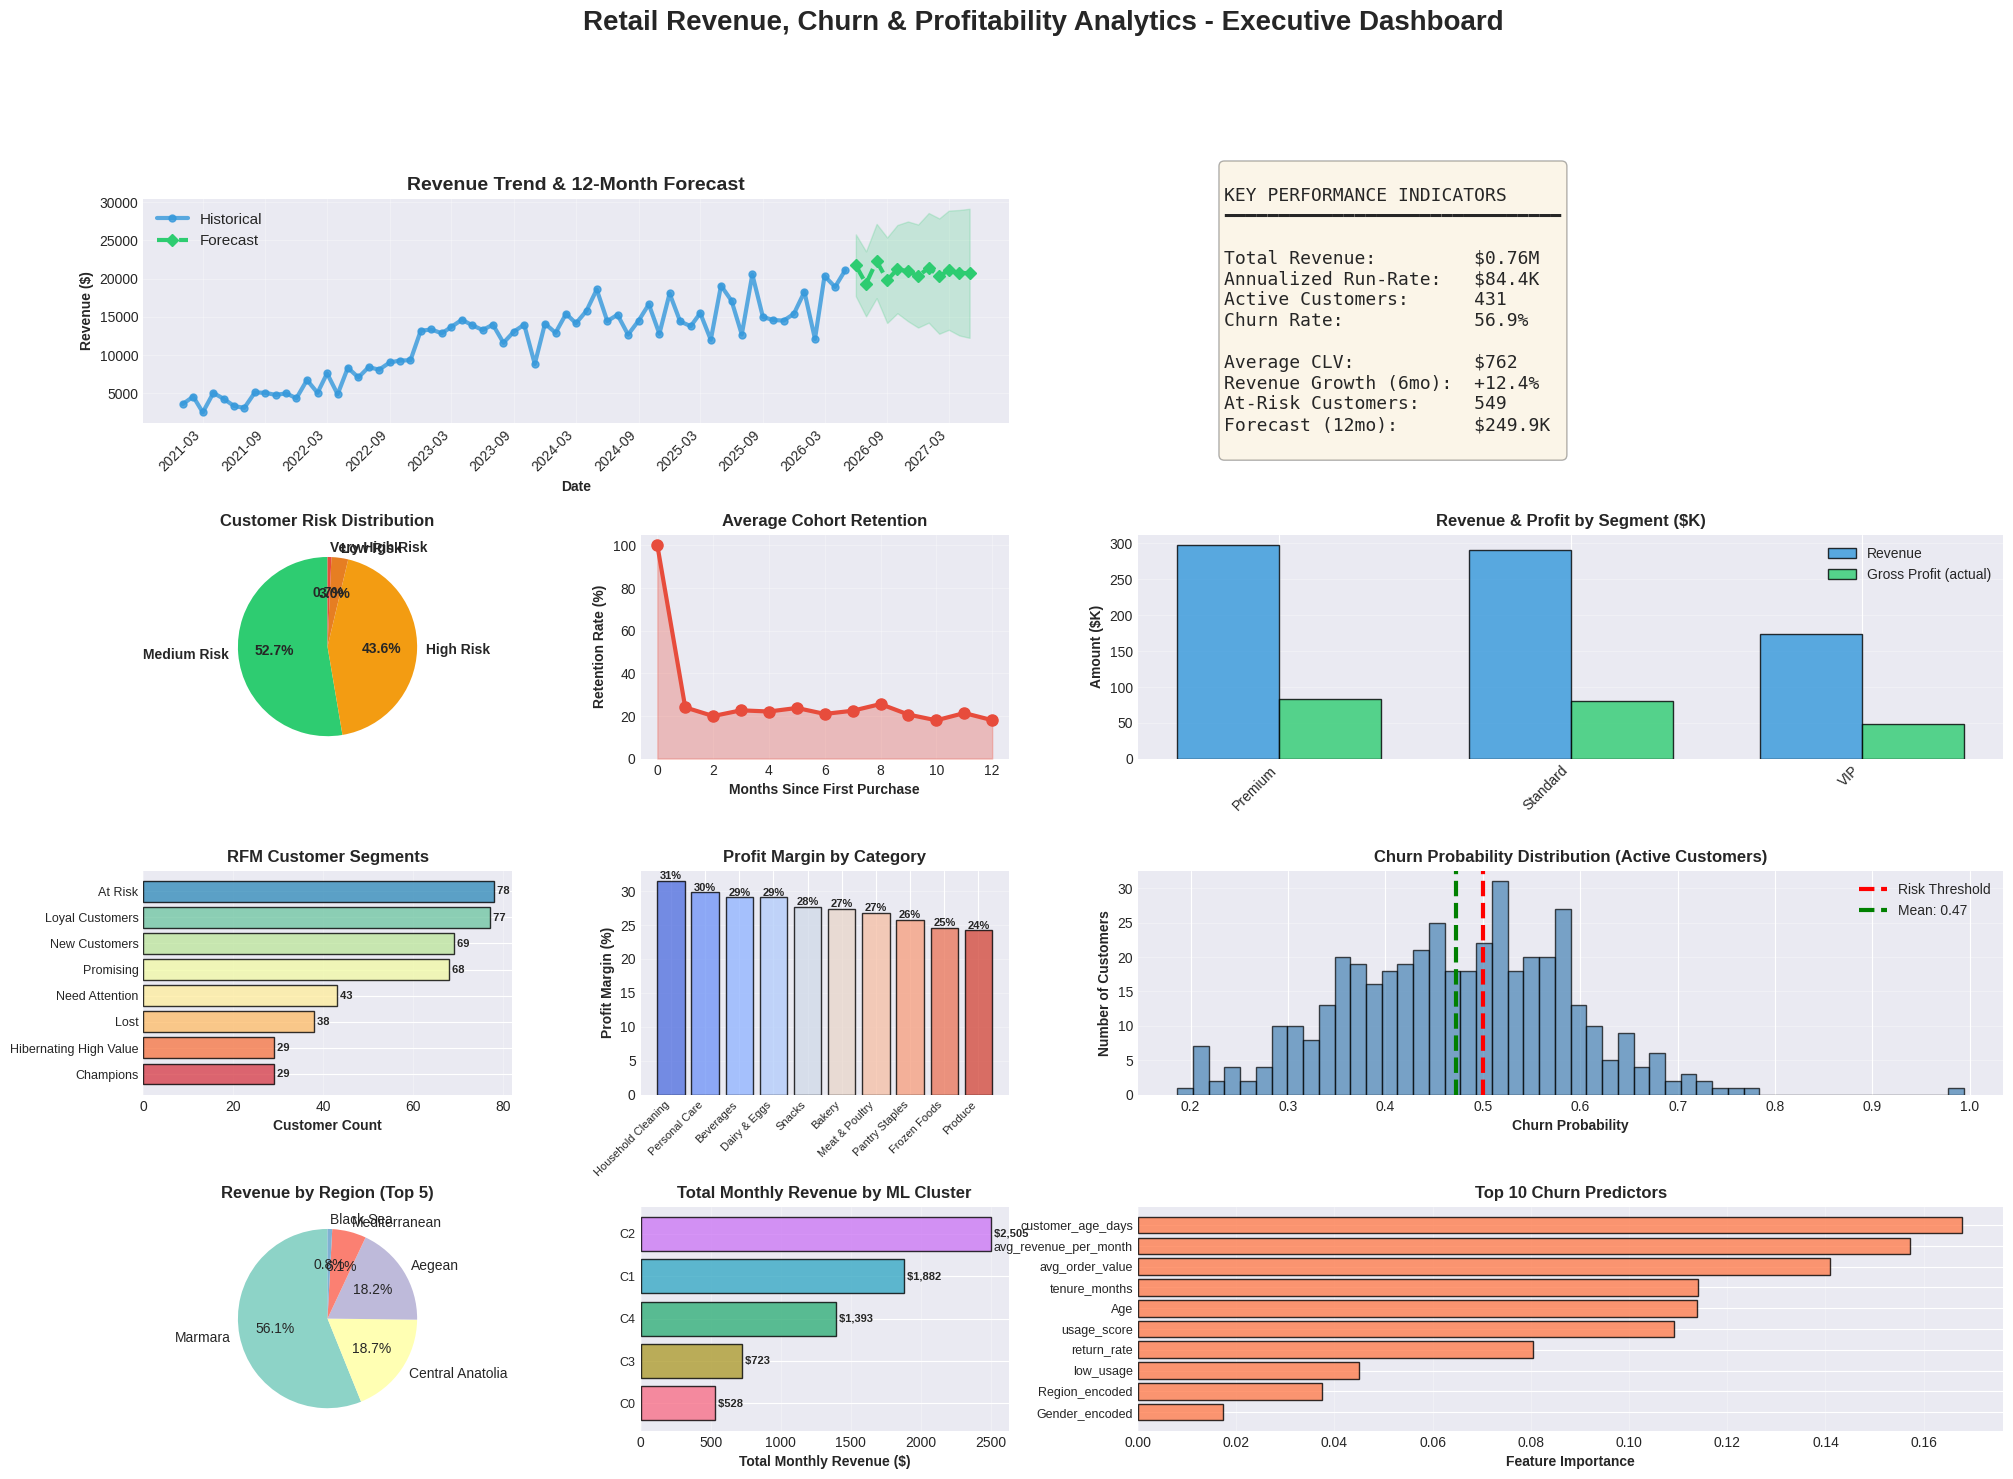


 Executive Dashboard Complete!



In [10]:
# ========================================================================
# 7.3: CREATE FINAL COMPREHENSIVE DASHBOARD
# (Rewritten for the retail dataset. This pulls together variables from
#  EVERY earlier section — run Section 0, 2, 3, 4, 5, 6, and 7.1 first:
#    Section 3: ts_data, forecast, forecast_index, forecast_ci
#    Section 4: at_risk, churn_model_data, feature_importance
#    Section 5: avg_retention, rfm_summary
#    Section 6: profitability, category_analysis, geo_analysis, cluster_analysis
#    Section 7.1: total_revenue_all_time, total_annualized_revenue,
#                 active_customers_current, churn_rate_current,
#                 avg_clv_current, revenue_growth_rate
# ========================================================================

print("\n" + "-"*80)
print("7.3: CREATING FINAL COMPREHENSIVE DASHBOARD")
print("-"*80)

fig = plt.figure(figsize=(24, 16))
gs = GridSpec(4, 4, figure=fig, hspace=0.5, wspace=0.35)

colors_main = sns.color_palette("Set2", 8)

# 1. Revenue Trend with Forecast
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(ts_data.index, ts_data['total_revenue'],
        linewidth=3, color='#3498db', marker='o', markersize=5, label='Historical', alpha=0.8)
ax1.plot(forecast_index, forecast,
        linewidth=3, color='#2ecc71', marker='D', markersize=6, label='Forecast', linestyle='--')
ax1.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                 color='#2ecc71', alpha=0.2)
ax1.set_title('Revenue Trend & 12-Month Forecast', fontweight='bold', fontsize=14)
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Revenue ($)', fontweight='bold')
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. KPI Scorecard
ax2 = fig.add_subplot(gs[0, 2:])
ax2.axis('off')
kpi_text = f"""
KEY PERFORMANCE INDICATORS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Total Revenue:         ${total_revenue_all_time/1e6:.2f}M
Annualized Run-Rate:   ${total_annualized_revenue/1e3:.1f}K
Active Customers:      {active_customers_current:,}
Churn Rate:            {churn_rate_current:.1f}%

Average CLV:           ${avg_clv_current:,.0f}
Revenue Growth (6mo):  {revenue_growth_rate:+.1f}%
At-Risk Customers:     {len(at_risk):,}
Forecast (12mo):       ${forecast.sum()/1e3:.1f}K
"""
ax2.text(0.1, 0.5, kpi_text, transform=ax2.transAxes, fontsize=13,
        verticalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# 3. Churn Risk Segmentation
ax3 = fig.add_subplot(gs[1, 0])
risk_dist = churn_model_data[churn_model_data['is_churned'] == 0]['risk_category'].value_counts()
colors_risk = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
ax3.pie(risk_dist.values, labels=risk_dist.index,
        autopct='%1.1f%%', colors=colors_risk[:len(risk_dist)],
        startangle=90, textprops={'fontweight': 'bold'})
ax3.set_title('Customer Risk Distribution', fontweight='bold', fontsize=12)

# 4. Cohort Retention
ax4 = fig.add_subplot(gs[1, 1])
avg_retention_plot = avg_retention.iloc[:13]
ax4.plot(range(len(avg_retention_plot)), avg_retention_plot.values,
        marker='o', linewidth=3, markersize=8, color='#e74c3c')
ax4.fill_between(range(len(avg_retention_plot)), avg_retention_plot.values,
                 alpha=0.3, color='#e74c3c')
ax4.set_title('Average Cohort Retention', fontweight='bold', fontsize=12)
ax4.set_xlabel('Months Since First Purchase', fontweight='bold')
ax4.set_ylabel('Retention Rate (%)', fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 105])

# 5. Segment Profitability
ax5 = fig.add_subplot(gs[1, 2:])
x_pos = np.arange(len(profitability))
width = 0.35
ax5.bar(x_pos - width/2, profitability['Total_Revenue']/1000, width,
       label='Revenue', color='#3498db', alpha=0.8, edgecolor='black')
ax5.bar(x_pos + width/2, profitability['Gross_Profit']/1000, width,
       label='Gross Profit (actual)', color='#2ecc71', alpha=0.8, edgecolor='black')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(profitability.index, rotation=45, ha='right')
ax5.set_title('Revenue & Profit by Segment ($K)', fontweight='bold', fontsize=12)
ax5.set_ylabel('Amount ($K)', fontweight='bold')
ax5.legend(loc='upper right')
ax5.grid(axis='y', alpha=0.3)

# 6. RFM Segments
ax6 = fig.add_subplot(gs[2, 0])
rfm_counts = rfm_summary['Count'].sort_values(ascending=True)
colors_rfm = sns.color_palette("Spectral", len(rfm_counts))
ax6.barh(range(len(rfm_counts)), rfm_counts.values, color=colors_rfm,
        alpha=0.8, edgecolor='black')
ax6.set_yticks(range(len(rfm_counts)))
ax6.set_yticklabels(rfm_counts.index, fontsize=9)
ax6.set_title('RFM Customer Segments', fontweight='bold', fontsize=12)
ax6.set_xlabel('Customer Count', fontweight='bold')
for i, v in enumerate(rfm_counts.values):
    ax6.text(v, i, f' {v:,.0f}', va='center', fontweight='bold', fontsize=8)
ax6.grid(axis='x', alpha=0.3)

# 7. Category Profit Margin (replaces template's "Plan Performance" — no
#    subscription plans exist here; product categories are the analogue,
#    and margin is the meaningful metric at the category level, not CLV)
ax7 = fig.add_subplot(gs[2, 1])
cat_margin = category_analysis.sort_values('Profit_Margin_%', ascending=False)
colors_cat = sns.color_palette("coolwarm", len(cat_margin))
ax7.bar(range(len(cat_margin)), cat_margin['Profit_Margin_%'], color=colors_cat,
       alpha=0.8, edgecolor='black')
ax7.set_xticks(range(len(cat_margin)))
ax7.set_xticklabels(cat_margin.index, rotation=45, ha='right', fontsize=8)
ax7.set_title('Profit Margin by Category', fontweight='bold', fontsize=12)
ax7.set_ylabel('Profit Margin (%)', fontweight='bold')
for i, v in enumerate(cat_margin['Profit_Margin_%']):
    ax7.text(i, v, f'{v:.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=8)
ax7.grid(axis='y', alpha=0.3)

# 8. Churn Probability Distribution
ax8 = fig.add_subplot(gs[2, 2:])
active_probs = churn_model_data[churn_model_data['is_churned'] == 0]['churn_probability']
ax8.hist(active_probs, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax8.axvline(x=0.5, color='red', linestyle='--', linewidth=3, label='Risk Threshold')
ax8.axvline(x=active_probs.mean(), color='green', linestyle='--', linewidth=3,
           label=f'Mean: {active_probs.mean():.2f}')
ax8.set_title('Churn Probability Distribution (Active Customers)',
             fontweight='bold', fontsize=12)
ax8.set_xlabel('Churn Probability', fontweight='bold')
ax8.set_ylabel('Number of Customers', fontweight='bold')
ax8.legend(loc='upper right')
ax8.grid(axis='y', alpha=0.3)

# 9. Geographic Distribution (Region, not country)
ax9 = fig.add_subplot(gs[3, 0])
geo_top5 = geo_analysis.nlargest(5, 'Total_Revenue')
ax9.pie(geo_top5['Total_Revenue'], labels=geo_top5.index, autopct='%1.1f%%',
       colors=sns.color_palette("Set3", len(geo_top5)), startangle=90)
ax9.set_title('Revenue by Region (Top 5)', fontweight='bold', fontsize=12)

# 10. ML Clusters Value (Total Monthly Revenue, not MRR)
ax10 = fig.add_subplot(gs[3, 1])
cluster_value = cluster_analysis.sort_values('Total_Monthly_Revenue', ascending=True)
ax10.barh(range(len(cluster_value)), cluster_value['Total_Monthly_Revenue'],
         color=sns.color_palette("husl", len(cluster_value)), alpha=0.8, edgecolor='black')
ax10.set_yticks(range(len(cluster_value)))
ax10.set_yticklabels([f'C{int(i)}' for i in cluster_value.index], fontsize=9)
ax10.set_title('Total Monthly Revenue by ML Cluster', fontweight='bold', fontsize=12)
ax10.set_xlabel('Total Monthly Revenue ($)', fontweight='bold')
for i, v in enumerate(cluster_value['Total_Monthly_Revenue']):
    ax10.text(v, i, f' ${v:,.0f}', va='center', fontweight='bold', fontsize=8)
ax10.grid(axis='x', alpha=0.3)

# 11. Feature Importance (Churn)
ax11 = fig.add_subplot(gs[3, 2:])
top_features_plot = feature_importance.head(10)
ax11.barh(range(len(top_features_plot)), top_features_plot['importance'],
         color='coral', alpha=0.8, edgecolor='black')
ax11.set_yticks(range(len(top_features_plot)))
ax11.set_yticklabels(top_features_plot['feature'], fontsize=9)
ax11.set_title('Top 10 Churn Predictors', fontweight='bold', fontsize=12)
ax11.set_xlabel('Feature Importance', fontweight='bold')
ax11.grid(axis='x', alpha=0.3)
ax11.invert_yaxis()

plt.suptitle('Retail Revenue, Churn & Profitability Analytics - Executive Dashboard',
            fontsize=20, fontweight='bold', y=0.998)

plt.savefig('financial_viz/16_FINAL_EXECUTIVE_DASHBOARD.png', dpi=300, bbox_inches='tight')
print("\n Saved: financial_viz/16_FINAL_EXECUTIVE_DASHBOARD.png")
plt.show()

print("\n Executive Dashboard Complete!")
print("="*80 + "\n")

In [ ]:
!zip -r financial_viz.zip financial_viz
from google.colab import files
files.download('financial_viz.zip')

updating: financial_viz/ (stored 0%)
updating: financial_viz/01_initial_exploration.png (deflated 15%)
  adding: financial_viz/05_prophet_forecast.png (deflated 11%)
  adding: financial_viz/16_FINAL_EXECUTIVE_DASHBOARD.png (deflated 15%)
  adding: financial_viz/07_churn_analysis.png (deflated 18%)
  adding: financial_viz/12_revenue_cohorts.png (deflated 16%)
  adding: financial_viz/14_clv_analysis.png (deflated 23%)
  adding: financial_viz/15_profitability_dashboard.png (deflated 15%)
  adding: financial_viz/06_prophet_components.png (deflated 18%)
  adding: financial_viz/13_rfm_analysis.png (deflated 10%)
  adding: financial_viz/11_cohort_retention.png (deflated 9%)
  adding: financial_viz/03_acf_pacf_analysis.png (deflated 29%)
  adding: financial_viz/09_churn_feature_importance.png (deflated 30%)
  adding: financial_viz/08_churn_model_evaluation.png (deflated 20%)
  adding: financial_viz/02_ts_decomposition.png (deflated 15%)
  adding: financial_viz/04_arima_forecast.png (deflated 1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>